# ❗ 1. 탐색적 데이터 분석(EDA) 커리큘럼 ❗

## 🔧 1. 환경 설정 및 라이브러리 준비

In [1]:
"""사용 라이브러리"""
# ====================
# 기본 라이브러리 import
# ====================

# 데이터 조작 및 분석
import pandas as pd
# 수치 계산
import numpy as np
# 기본 시각화
import matplotlib.pyplot as plt
# 고급 시각화
import seaborn as sns
# 시간 체크
import time
# 조합 생성(변수들의 모든 조합을 테스트 목적)
from itertools import combinations
# 경고 메시지 숨김
import warnings
warnings.filterwarnings('ignore')

# ====================
# 통계 분석 라이브러리
# ====================

# 기본 통계 분석
from scipy import stats
# 세부 통계 분석
from scipy.stats import (
    jarque_bera, anderson, kstest,
    pearsonr, spearmanr
)

# ====================
# 머신러닝 라이브러리
# ====================

# 데이터 전처리
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# 데이터 분할
from sklearn.model_selection import train_test_split
# 선형 회귀 모델
from sklearn.linear_model import LinearRegression
# 모델 평가
from sklearn.metrics import r2_score, mean_squared_error

# 변수 선택 기법
from sklearn.feature_selection import SequentialFeatureSelector

# 유전 알고리즘 기반 변수 선택
from sklearn_genetic import GAFeatureSelectionCV

# mlxtend 라이브러리(머신러닝 관련 확장 기능 제공 라이브러리) 변수 선택 기법
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

## 📂 2. 데이터 불러오기


In [2]:
"""CSV 파일 불러오기"""

# # 방법 1: 로컬 파일 업로드
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

filename = 'PBL_TAT_Set_Data_Label변환용_250627.xlsx'
df = pd.read_excel(filename,
                   skiprows=1,         # 첫 번째 행 건너뛰기
                   header=0,           # 첫 번째 행을 넘긴 후, header로 지정할 행
                   usecols="B:S"
                  )

# 방법 2: Google Drive에서 불러오기
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

# 방법 3: 직접 불러오기
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

print(f"✅ 데이터 로드 완료: {df.shape}")

✅ 데이터 로드 완료: (28812, 18)


In [3]:
"""불러온 파일 및 변수 분류 확인"""

# 타겟 변수와 설명 변수 분리
target_col = df.columns[-1]  # 마지막 컬럼을 타겟으로 가정
feature_cols = [col for col in df.columns if col != target_col]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
# Numerical에서 시간 변수 제외
numeric_features.remove('timekey_hr')

categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n🎯 변수 분류:")

print(f"   전체 변수: {list(df.columns)}")
print(f"   타겟 변수: {target_col}")
print(f"   수치형 설명 변수 ({len(numeric_features)}개): {numeric_features}")
print(f"   범주형 설명 변수 ({len(categorical_features)}개): {categorical_features}\n")
df.head()


🎯 변수 분류:
   전체 변수: ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'y1']
   타겟 변수: y1
   수치형 설명 변수 (9개): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
   범주형 설명 변수 (7개): ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']



,timekey_hr,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y1
0,2025062507,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,199,5100,0,0,75,0,2881.0,0.018,Y,0.015565
1,2025062508,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,275,4282,0,0,25,0,2881.0,0.002,Y,0.018498
2,2025062509,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,4080,0,0,75,0,2881.0,0.011,Y,0.020275
3,2025062510,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,5100,0,25,100,50,2881.0,0.011,Y,0.016809
4,2025062511,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,176,5100,0,25,0,0,2881.0,0.002,Y,0.013434


## 📊 3. 탐색적 데이터 분석(EDA) 수행

### 3.1 변수별 기초 통계량 분석

In [4]:
print("="*60)
print("1️⃣ 변수별 기초 통계량 분석")
print("="*60)

print("📝 기초 통계량 분석이란?")
print("   - 데이터의 중심경향성, 산포도, 분포 형태를 파악")
print("   - 각 변수의 기본적인 특성과 패턴 이해")
print("   - 이상치, 편향, 변동성 등의 데이터 품질 평가")
print("   - 후속 분석 방법 선택의 기초 자료 제공")

1️⃣ 변수별 기초 통계량 분석
📝 기초 통계량 분석이란?
   - 데이터의 중심경향성, 산포도, 분포 형태를 파악
   - 각 변수의 기본적인 특성과 패턴 이해
   - 이상치, 편향, 변동성 등의 데이터 품질 평가
   - 후속 분석 방법 선택의 기초 자료 제공


In [5]:
# ===================================================================
# 📊 1. 기본 통계량 (pandas describe)
# ===================================================================

print(f"\n📊 1. 기본 통계량 (pandas describe)")
print("="*50)

basic_stats = df[numeric_features].describe()
print("📈 기초 통계량:")
print(basic_stats.round(4))

print(f"\n💡 기본 통계량 의미:")
print("   📊 count: 결측치 제외 유효 데이터 개수")
print("   📊 mean: 산술 평균 (이상치에 민감)")
print("   📊 std: 표준편차 (데이터 분산 정도)")
print("   📊 min/max: 최솟값/최댓값 (범위 확인)")
print("   📊 25%/50%/75%: 1사분위수/중위수/3사분위수")


📊 1. 기본 통계량 (pandas describe)
📈 기초 통계량:
               x1          x2          x3          x4          x5          x6  \
count  28812.0000  28812.0000  28812.0000  28812.0000  28812.0000  28812.0000   
mean    4308.0400    173.7577   4295.0134     21.4821    161.7770    529.9552   
std      330.2533     90.1423    682.9071    108.7696    329.9213    885.5519   
min        0.0000      0.0000    207.0000      0.0000      0.0000      0.0000   
25%     3925.0000    124.0000   3923.0000      0.0000      0.0000    125.0000   
50%     4425.0000    174.0000   4235.0000      0.0000     25.0000    268.0000   
75%     4450.0000    225.0000   4890.0000      0.0000    175.0000    550.0000   
max     4800.0000   1219.0000   7619.0000   1921.0000   4219.0000  10924.0000   

               x7          x8          x9  
count  28812.0000  27244.0000  27244.0000  
mean      61.8210   1628.4442      0.2428  
std      111.0754   1847.8272      0.3787  
min        0.0000     60.0000      0.0000  
25%      

In [6]:
# ===================================================================
# 📊 2. 고급 통계량 계산 및 해석
# ===================================================================
print(f"\n📊 2. 고급 통계량 및 상세 해석")
print("="*50)

# 고급 통계량 계산
advanced_stats = pd.DataFrame({
    '변수명': numeric_features,
    '평균': df[numeric_features].mean(),
    '중위수': df[numeric_features].median(),
    '최빈값': [df[col].mode()[0] if not df[col].mode().empty else np.nan for col in numeric_features],
    '표준편차': df[numeric_features].std(),
    '분산': df[numeric_features].var(),
    '왜도(Skewness)': df[numeric_features].skew(),
    '첨도(Kurtosis)': df[numeric_features].kurtosis(),
    '변동계수(CV)': df[numeric_features].std() / df[numeric_features].mean(),
    '범위(Range)': df[numeric_features].max() - df[numeric_features].min(),
    '사분위수범위(IQR)': df[numeric_features].quantile(0.75) - df[numeric_features].quantile(0.25)
})

print("📊 고급 통계량:")
print(advanced_stats.round(4))

print(" \n💡 고급 통계량 의미:")
print("   📊 평균: 모든 값을 더해서 개수로 나눈 값 (극값에 민감)")
print("   📊 중위수: 크기 순으로 정렬했을 때 가운데 값 (극값에 안정적)")
print("   📊 최빈값: 가장 자주 나타나는 값")
print("   📊 표준편차: 데이터가 평균으로부터 퍼진 정도")
print("   📊 분산: 표준편차의 제곱값 (변동성 측정)")
print("   📊 왜도(Skewness): 분포의 비대칭 정도 (0=대칭, +값=오른쪽 꼬리)")
print("   📊 첨도(Kurtosis): 분포의 뾰족한 정도 (높을수록 중심부 집중)")
print("   📊 변동계수(CV): 표준편차/평균 (서로 다른 단위 간 변동성 비교)")
print("   📊 범위(Range): 최댓값-최솟값 (전체 데이터 폭)")
print("   📊 사분위수범위(IQR): 75%-25% (중간 50% 데이터의 퍼진 정도)")


📊 2. 고급 통계량 및 상세 해석
📊 고급 통계량:
   변수명         평균       중위수     최빈값       표준편차            분산  왜도(Skewness)  \
x1  x1  4308.0400  4425.000  4450.0   330.2533  1.090673e+05       -3.9653   
x2  x2   173.7577   174.000   150.0    90.1423  8.125632e+03        1.0493   
x3  x3  4295.0134  4235.000  5070.0   682.9071  4.663621e+05       -0.5718   
x4  x4    21.4821     0.000     0.0   108.7696  1.183083e+04        7.9383   
x5  x5   161.7770    25.000     0.0   329.9213  1.088480e+05        4.4980   
x6  x6   529.9552   268.000    75.0   885.5519  7.842022e+05        4.8367   
x7  x7    61.8210    25.000     0.0   111.0754  1.233775e+04        3.6055   
x8  x8  1628.4442  1440.000  1440.0  1847.8272  3.414465e+06        4.1991   
x9  x9     0.2428     0.116     0.0     0.3787  1.434000e-01        5.4895   

    첨도(Kurtosis)  변동계수(CV)  범위(Range)  사분위수범위(IQR)  
x1       47.3135    0.0767   4800.000      525.000  
x2        4.6099    0.5188   1219.000      101.000  
x3        0.8473    0.1590   

In [7]:
# ===================================================================
# 📊 3. 변수별 개별 분석 및 해석
# ===================================================================
print(f"\n📊 3. 변수별 개별 분석 및 해석")
print("="*50)

for idx, col in enumerate(numeric_features):
    print(f"\n🔍 변수 {idx+1}/{len(numeric_features)}: {col}")
    print("-" * 40)

    # 기본 값들 가져오기
    data = df[col].dropna()
    n = len(data)
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skew_val = data.skew()
    kurt_val = data.kurtosis()
    cv_val = std_val / mean_val if mean_val != 0 else np.inf

    # 기본 정보
    print(f"📊 기본 정보:")
    print(f"   유효 데이터: {n:,}개")
    print(f"   평균: {mean_val:.4f}")
    print(f"   중위수: {median_val:.4f}")
    print(f"   표준편차: {std_val:.4f}")

    # 중심경향성 분석
    print(f"\n📊 중심경향성 분석:")
    mean_median_diff = abs(mean_val - median_val)
    if mean_median_diff < std_val * 0.1:
        central_tendency = "평균과 중위수 거의 일치 (대칭적 분포)"
    elif mean_val > median_val:
        central_tendency = "평균 > 중위수 (오른쪽 치우침 가능성)"
    else:
        central_tendency = "평균 < 중위수 (왼쪽 치우침 가능성)"
    print(f"   {central_tendency}")

    # 변동성 분석
    print(f"\n📊 변동성 분석:")
    print(f"   변동계수 (CV): {cv_val:.4f}")
    if cv_val < 0.1:
        variability = "매우 낮은 변동성 (일관된 데이터)"
    elif cv_val < 0.3:
        variability = "낮은 변동성 (안정적 데이터)"
    elif cv_val < 0.5:
        variability = "보통 변동성"
    elif cv_val < 1.0:
        variability = "높은 변동성 (주의 필요)"
    else:
        variability = "매우 높은 변동성 (데이터 검토 필요)"
    print(f"   {variability}")

    # 왜도 분석
    print(f"\n📊 왜도 분석:")
    print(f"   왜도값: {skew_val:.4f}")
    if abs(skew_val) < 0.5:
        skew_desc = "대칭적 분포"
        skew_impact = "정규분포에 가까움"
    elif skew_val > 0.5:
        if skew_val > 1.0:
            skew_desc = "강한 오른쪽 치우침"
            skew_impact = "로그변환 고려"
        else:
            skew_desc = "약한 오른쪽 치우림"
            skew_impact = "제곱근변환 고려"
    else:
        if skew_val < -1.0:
            skew_desc = "강한 왼쪽 치우침"
            skew_impact = "제곱변환 고려"
        else:
            skew_desc = "약한 왼쪽 치우침"
            skew_impact = "변환 고려"

    print(f"   분포 형태: {skew_desc}")
    print(f"   권장사항: {skew_impact}")

    # 첨도 분석
    print(f"\n📊 첨도 분석:")
    print(f"   첨도값: {kurt_val:.4f}")
    if abs(kurt_val - 3) < 0.5:
        kurt_desc = "정규분포와 유사한 첨도"
        kurt_impact = "정규분포 가정 가능"
    elif kurt_val > 3:
        if kurt_val > 7:
            kurt_desc = "매우 뾰족한 분포 (급첨도)"
            kurt_impact = "이상치 많음, 검토 필요"
        else:
            kurt_desc = "뾰족한 분포 (급첨도)"
            kurt_impact = "이상치 주의"
    else:
        if kurt_val < -1:
            kurt_desc = "매우 평평한 분포 (저첨도)"
            kurt_impact = "균등분포 특성"
        else:
            kurt_desc = "평평한 분포 (저첨도)"
            kurt_impact = "넓은 분포"

    print(f"   분포 형태: {kurt_desc}")
    print(f"   권장사항: {kurt_impact}")

    # 데이터 품질 종합 평가
    print(f"\n📊 데이터 품질 종합 평가:")
    quality_issues = []

    # 이상치 의심
    if abs(skew_val) > 2 or abs(kurt_val) > 10:
        quality_issues.append("이상치 의심")

    # 변동성 문제
    if cv_val > 1.5:
        quality_issues.append("과도한 변동성")
    elif cv_val < 0.01:
        quality_issues.append("변동성 부족 (상수에 가까움)")

    # 분포 문제
    if abs(skew_val) > 1.5:
        quality_issues.append("심한 치우침")

    if quality_issues:
        print(f"   ⚠️ 주의사항: {', '.join(quality_issues)}")
    else:
        print(f"   ✅ 양호한 데이터 품질")


📊 3. 변수별 개별 분석 및 해석

🔍 변수 1/9: x1
----------------------------------------
📊 기본 정보:
   유효 데이터: 28,812개
   평균: 4308.0400
   중위수: 4425.0000
   표준편차: 330.2533

📊 중심경향성 분석:
   평균 < 중위수 (왼쪽 치우침 가능성)

📊 변동성 분석:
   변동계수 (CV): 0.0767
   매우 낮은 변동성 (일관된 데이터)

📊 왜도 분석:
   왜도값: -3.9653
   분포 형태: 강한 왼쪽 치우침
   권장사항: 제곱변환 고려

📊 첨도 분석:
   첨도값: 47.3135
   분포 형태: 매우 뾰족한 분포 (급첨도)
   권장사항: 이상치 많음, 검토 필요

📊 데이터 품질 종합 평가:
   ⚠️ 주의사항: 이상치 의심, 심한 치우침

🔍 변수 2/9: x2
----------------------------------------
📊 기본 정보:
   유효 데이터: 28,812개
   평균: 173.7577
   중위수: 174.0000
   표준편차: 90.1423

📊 중심경향성 분석:
   평균과 중위수 거의 일치 (대칭적 분포)

📊 변동성 분석:
   변동계수 (CV): 0.5188
   높은 변동성 (주의 필요)

📊 왜도 분석:
   왜도값: 1.0493
   분포 형태: 강한 오른쪽 치우침
   권장사항: 로그변환 고려

📊 첨도 분석:
   첨도값: 4.6099
   분포 형태: 뾰족한 분포 (급첨도)
   권장사항: 이상치 주의

📊 데이터 품질 종합 평가:
   ✅ 양호한 데이터 품질

🔍 변수 3/9: x3
----------------------------------------
📊 기본 정보:
   유효 데이터: 28,812개
   평균: 4295.0134
   중위수: 4235.0000
   표준편차: 682.9071

📊 중심경향성 분석:
   평균과 중위수 거의 일치 (대칭적 분포)

📊 변동성 분석:


In [8]:
# ===================================================================
# 📊 4. 전체 변수 비교 분석
# ===================================================================
print(f"\n📊 4. 전체 변수 비교 분석")
print("="*50)

# 변동성 비교
print("📊 변동성 순위 (변동계수 기준):")
cv_ranking = advanced_stats.sort_values('변동계수(CV)', ascending=False)
for i, (_, row) in enumerate(cv_ranking.iterrows(), 1):
    cv_val = row['변동계수(CV)']
    if cv_val < 0.3:
        level = "낮음"
    elif cv_val < 0.5:
        level = "보통"
    elif cv_val < 1.0:
        level = "높음"
    else:
        level = "매우 높음"
    print(f"   {i}. {row['변수명']}: {cv_val:.4f} ({level})")

# 왜도 비교
print(f"\n📊 왜도 순위 (절댓값 기준):")
skew_ranking = advanced_stats.copy()
skew_ranking['왜도_절댓값'] = abs(skew_ranking['왜도(Skewness)'])
skew_ranking = skew_ranking.sort_values('왜도_절댓값', ascending=False)

for i, (_, row) in enumerate(skew_ranking.iterrows(), 1):
    skew_val = row['왜도(Skewness)']
    abs_skew = abs(skew_val)

    if abs_skew < 0.5:
        level = "대칭적"
    elif abs_skew < 1.0:
        level = "약간 치우침"
    elif abs_skew < 2.0:
        level = "치우침"
    else:
        level = "심하게 치우침"

    direction = "오른쪽" if skew_val > 0 else "왼쪽" if skew_val < 0 else ""
    print(f"   {i}. {row['변수명']}: {skew_val:.4f} ({direction} {level})")

# 첨도 비교
print(f"\n📊 첨도 순위 (정규분포 대비):")
kurt_ranking = advanced_stats.copy()
kurt_ranking['첨도_정규분포차이'] = abs(kurt_ranking['첨도(Kurtosis)'] - 3)
kurt_ranking = kurt_ranking.sort_values('첨도_정규분포차이', ascending=False)

for i, (_, row) in enumerate(kurt_ranking.iterrows(), 1):
    kurt_val = row['첨도(Kurtosis)']
    diff_from_normal = abs(kurt_val - 3)

    if diff_from_normal < 0.5:
        level = "정규분포 유사"
    elif diff_from_normal < 2.0:
        level = "약간 차이"
    elif diff_from_normal < 5.0:
        level = "차이 있음"
    else:
        level = "큰 차이"

    shape = "뾰족" if kurt_val > 3 else "평평" if kurt_val < 3 else "정규"
    print(f"   {i}. {row['변수명']}: {kurt_val:.4f} ({shape}, {level})")


📊 4. 전체 변수 비교 분석
📊 변동성 순위 (변동계수 기준):
   1. x4: 5.0633 (매우 높음)
   2. x5: 2.0394 (매우 높음)
   3. x7: 1.7967 (매우 높음)
   4. x6: 1.6710 (매우 높음)
   5. x9: 1.5599 (매우 높음)
   6. x8: 1.1347 (매우 높음)
   7. x2: 0.5188 (높음)
   8. x3: 0.1590 (낮음)
   9. x1: 0.0767 (낮음)

📊 왜도 순위 (절댓값 기준):
   1. x4: 7.9383 (오른쪽 심하게 치우침)
   2. x9: 5.4895 (오른쪽 심하게 치우침)
   3. x6: 4.8367 (오른쪽 심하게 치우침)
   4. x5: 4.4980 (오른쪽 심하게 치우침)
   5. x8: 4.1991 (오른쪽 심하게 치우침)
   6. x1: -3.9653 (왼쪽 심하게 치우침)
   7. x7: 3.6055 (오른쪽 심하게 치우침)
   8. x2: 1.0493 (오른쪽 치우침)
   9. x3: -0.5718 (왼쪽 약간 치우침)

📊 첨도 순위 (정규분포 대비):
   1. x4: 80.6607 (뾰족, 큰 차이)
   2. x9: 63.2627 (뾰족, 큰 차이)
   3. x1: 47.3135 (뾰족, 큰 차이)
   4. x6: 33.6617 (뾰족, 큰 차이)
   5. x5: 31.0185 (뾰족, 큰 차이)
   6. x8: 30.6538 (뾰족, 큰 차이)
   7. x7: 19.5523 (뾰족, 큰 차이)
   8. x3: 0.8473 (평평, 차이 있음)
   9. x2: 4.6099 (뾰족, 약간 차이)


**참고**

🎯 중심경향성 (Central Tendency)
- 📊 평균 (Mean)
모든 값의 산술 평균
→ 이상치에 민감하며, 정규분포일 경우 대표값으로 적합
- 📊 중위수 (Median)
전체 데이터의 중앙값 (50%ile)
→ 이상치에 강건하며, 치우친 분포에서는 평균보다 적절함
- 📊 최빈값 (Mode)
가장 자주 나타나는 값
→ 범주형 데이터에 특히 유용

🌊 산포도 (Variability)
- 📊 표준편차 (Standard Deviation)
평균으로부터의 평균적인 거리
→ 데이터의 분산 정도를 원래 단위로 해석 가능
- 📊 분산 (Variance)
표준편차의 제곱
→ 계산에 유용하나 해석 단위가 제곱이므로 직관적이지 않을 수 있음
- 📊 변동계수 (Coefficient of Variation, CV)
표준편차 ÷ 평균
→ 단위가 다른 변수 간 상대적 변동성 비교에 유용
- 📊 범위 (Range)
최댓값 - 최솟값
→ 데이터 분포의 전체 폭, 이상치에 민감함
- 📊 사분위수범위 (Interquartile Range, IQR)
Q3 - Q1 (상위 25% - 하위 25%)
→ 중간 50% 데이터의 분포 폭, 이상치에 강건함

📐 분포 형태 (Shape)
- 📊 왜도 (Skewness)
분포의 비대칭 정도
→ 0: 대칭 / >0: 오른쪽으로 치우침 / <0: 왼쪽으로 치우침
- 📊 첨도 (Kurtosis)
분포의 뾰족한 정도
→ 3: 정규분포 / >3: 뾰족함 (leptokurtic) / <3: 평평함 (platykurtic)

### 3.2 정규성 검정

In [9]:
print("="*60)
print("2️⃣ 정규성 검정 (정규 분포 가정 확인)")
print("="*60)

print("📝 정규성 검정이란?")
print("   - 데이터가 정규분포를 따르는지 통계적으로 검증")
print("   - 많은 통계기법과 머신러닝 알고리즘의 기본 가정")
print("   - p-value > 0.05이면 정규분포로 판단")

print("\n🧪 사용할 4가지 검정 방법:")
print("   1️⃣ Shapiro-Wilk: 소표본에 강력, 가장 널리 사용")
print("   2️⃣ Jarque-Bera: 왜도와 첨도 기반, 대표본에 적합")
print("   3️⃣ Anderson-Darling: 꼬리 부분에 민감, 엄격한 검정")
print("   4️⃣ Kolmogorov-Smirnov: 전체 분포 비교, 보수적 검정")

print(f"\n📊 분석 대상: {len(numeric_features)}개 수치형 변수")
print(f"🔍 각 변수별 4가지 정규성 검정 수행")

2️⃣ 정규성 검정 (정규 분포 가정 확인)
📝 정규성 검정이란?
   - 데이터가 정규분포를 따르는지 통계적으로 검증
   - 많은 통계기법과 머신러닝 알고리즘의 기본 가정
   - p-value > 0.05이면 정규분포로 판단

🧪 사용할 4가지 검정 방법:
   1️⃣ Shapiro-Wilk: 소표본에 강력, 가장 널리 사용
   2️⃣ Jarque-Bera: 왜도와 첨도 기반, 대표본에 적합
   3️⃣ Anderson-Darling: 꼬리 부분에 민감, 엄격한 검정
   4️⃣ Kolmogorov-Smirnov: 전체 분포 비교, 보수적 검정

📊 분석 대상: 9개 수치형 변수
🔍 각 변수별 4가지 정규성 검정 수행


In [10]:
# ===================================================================
# 각 변수별 정규성 검정 수행
# ===================================================================

normality_results = []

for idx, col in enumerate(numeric_features):
    print(f"\n" + "="*50)
    print(f"🔍 변수 {idx+1}/{len(numeric_features)}: {col}")
    print("="*50)

    # 결측치 제거 및 기본 정보
    data = df[col].dropna()
    n = len(data)

    print(f"📊 기본 정보:")
    print(f"   📏 샘플 크기: {n:,}개")
    print(f"   📊 평균: {data.mean():.4f}")
    print(f"   📊 표준편차: {data.std():.4f}")
    print(f"   📊 왜도: {data.skew():.4f}")
    print(f"   📊 첨도: {data.kurtosis():.4f}")

    # 결과 저장용 딕셔너리
    results = {'변수명': col, '샘플크기': n}

    print(f"\n🧪 정규성 검정 결과:")
    print("-" * 40)

    # ===================================================================
    # 1. Shapiro-Wilk 검정 (n <= 5000)
    # ===================================================================
    print("1️⃣ Shapiro-Wilk 검정")
    stat, p_val = stats.shapiro(data)
    results['Shapiro_stat'] = stat
    results['Shapiro_p'] = p_val
    results['Shapiro_정규성'] = 'Yes' if p_val > 0.05 else 'No'

    print(f"   📊 통계량: {stat:.4f}")
    print(f"   📊 p-value: {p_val:.4f}")
    print(f"   📊 결과: {'✅ 정규분포' if p_val > 0.05 else '❌ 비정규분포'}")

    # 해석 가이드
    if stat > 0.95:
        print(f"   💡 해석: 매우 정규분포에 가까움")
    elif stat > 0.90:
        print(f"   💡 해석: 정규분포에 가까움")
    elif stat > 0.85:
        print(f"   💡 해석: 약간의 비정규성 존재")
    else:
        print(f"   💡 해석: 심각한 비정규성")


    # ===================================================================
    # 2. Jarque-Bera 검정
    # ===================================================================
    print(f"\n2️⃣ Jarque-Bera 검정")
    jb_stat, jb_p = jarque_bera(data)
    results['JB_stat'] = jb_stat
    results['JB_p'] = jb_p
    results['JB_정규성'] = 'Yes' if jb_p > 0.05 else 'No'

    print(f"   📊 통계량: {jb_stat:.4f}")
    print(f"   📊 p-value: {jb_p:.4f}")
    print(f"   📊 결과: {'✅ 정규분포' if jb_p > 0.05 else '❌ 비정규분포'}")

    # 왜도와 첨도 기반 해석
    skew_val = data.skew()
    kurt_val = data.kurtosis()
    print(f"   💡 왜도 기여도: {abs(skew_val):.2f} ({'높음' if abs(skew_val) > 1 else '보통' if abs(skew_val) > 0.5 else '낮음'})")
    print(f"   💡 첨도 기여도: {abs(kurt_val):.2f} ({'높음' if abs(kurt_val) > 1 else '보통' if abs(kurt_val) > 0.5 else '낮음'})")

    # ===================================================================
    # 3. Anderson-Darling 검정
    # ===================================================================
    print(f"\n3️⃣ Anderson-Darling 검정")
    ad_stat, ad_critical, ad_sig = anderson(data, dist='norm')
    results['AD_stat'] = ad_stat
    results['AD_정규성'] = 'Yes' if ad_stat < ad_critical[2] else 'No'  # 5% 유의수준

    print(f"   📊 통계량: {ad_stat:.4f}")
    print(f"   📊 임계값 (5%): {ad_critical[2]:.4f}")
    print(f"   📊 결과: {'✅ 정규분포' if ad_stat < ad_critical[2] else '❌ 비정규분포'}")

    # 엄격도 해석
    if ad_stat < ad_critical[0]:  # 15% 수준
        print(f"   💡 해석: 매우 강한 정규성 증거")
    elif ad_stat < ad_critical[1]:  # 10% 수준
        print(f"   💡 해석: 강한 정규성 증거")
    elif ad_stat < ad_critical[2]:  # 5% 수준
        print(f"   💡 해석: 보통 정규성 증거")
    elif ad_stat < ad_critical[3]:  # 2.5% 수준
        print(f"   💡 해석: 약한 정규성 증거")
    else:  # 1% 수준 초과
        print(f"   💡 해석: 정규성 증거 부족")

    # ===================================================================
    # 4. Kolmogorov-Smirnov 검정
    # ===================================================================
    print(f"\n4️⃣ Kolmogorov-Smirnov 검정")
    ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
    results['KS_stat'] = ks_stat
    results['KS_p'] = ks_p
    results['KS_정규성'] = 'Yes' if ks_p > 0.05 else 'No'

    print(f"   📊 통계량: {ks_stat:.4f}")
    print(f"   📊 p-value: {ks_p:.4f}")
    print(f"   📊 결과: {'✅ 정규분포' if ks_p > 0.05 else '❌ 비정규분포'}")

    # 최대 편차 해석
    if ks_stat < 0.05:
        print(f"   💡 해석: 매우 작은 편차, 강한 정규성")
    elif ks_stat < 0.1:
        print(f"   💡 해석: 작은 편차, 양호한 정규성")
    elif ks_stat < 0.2:
        print(f"   💡 해석: 보통 편차, 약한 정규성")
    else:
        print(f"   💡 해석: 큰 편차, 정규성 의심")

    # ===================================================================
    # 개별 변수 종합 판단
    # ===================================================================
    tests = [results.get('Shapiro_정규성', 'N/A'), results['JB_정규성'],
            results['AD_정규성'], results['KS_정규성']]
    normal_count = tests.count('Yes')
    total_tests = len([t for t in tests if t != 'N/A'])

    print(f"\n📝 {col} 종합 판단:")
    print(f"   📊 통과한 검정: {normal_count}/{total_tests}개")

    if normal_count >= total_tests * 0.75:
        conclusion = "정규분포로 판단"
        recommendation = "정규분포 가정 통계기법 사용 가능"
        color_status = "🟢"
    elif normal_count >= total_tests * 0.5:
        conclusion = "부분적 정규성"
        recommendation = "변환 후 재검토 또는 비모수 방법 고려"
        color_status = "🟡"
    else:
        conclusion = "비정규분포"
        recommendation = "변환 필수 또는 비모수 방법 사용"
        color_status = "🔴"

    print(f"   {color_status} 결론: {conclusion}")

    normality_results.append(results)


🔍 변수 1/9: x1
📊 기본 정보:
   📏 샘플 크기: 28,812개
   📊 평균: 4308.0400
   📊 표준편차: 330.2533
   📊 왜도: -3.9653
   📊 첨도: 47.3135

🧪 정규성 검정 결과:
----------------------------------------
1️⃣ Shapiro-Wilk 검정
   📊 통계량: 0.7088
   📊 p-value: 0.0000
   📊 결과: ❌ 비정규분포
   💡 해석: 심각한 비정규성

2️⃣ Jarque-Bera 검정
   📊 통계량: 2761934.5116
   📊 p-value: 0.0000
   📊 결과: ❌ 비정규분포
   💡 왜도 기여도: 3.97 (높음)
   💡 첨도 기여도: 47.31 (높음)

3️⃣ Anderson-Darling 검정
   📊 통계량: 1826.0364
   📊 임계값 (5%): 0.7870
   📊 결과: ❌ 비정규분포
   💡 해석: 정규성 증거 부족

4️⃣ Kolmogorov-Smirnov 검정
   📊 통계량: 0.2795
   📊 p-value: 0.0000
   📊 결과: ❌ 비정규분포
   💡 해석: 큰 편차, 정규성 의심

📝 x1 종합 판단:
   📊 통과한 검정: 0/4개
   🔴 결론: 비정규분포

🔍 변수 2/9: x2
📊 기본 정보:
   📏 샘플 크기: 28,812개
   📊 평균: 173.7577
   📊 표준편차: 90.1423
   📊 왜도: 1.0493
   📊 첨도: 4.6099

🧪 정규성 검정 결과:
----------------------------------------
1️⃣ Shapiro-Wilk 검정
   📊 통계량: 0.9495
   📊 p-value: 0.0000
   📊 결과: ❌ 비정규분포
   💡 해석: 정규분포에 가까움

2️⃣ Jarque-Bera 검정
   📊 통계량: 30787.1833
   📊 p-value: 0.0000
   📊 결과: ❌ 비정규분포
   💡 왜도 기여도: 1.

In [11]:
# ===================================================================
# 전체 결과 요약 테이블
# ===================================================================
print(f"\n" + "="*60)
print("📊 전체 정규성 검정 결과 요약")
print("="*60)

normality_df = pd.DataFrame(normality_results)
print("🔬 정규성 검정 결과:")
print(normality_df.round(4))


📊 전체 정규성 검정 결과 요약
🔬 정규성 검정 결과:
  변수명   샘플크기  Shapiro_stat  Shapiro_p Shapiro_정규성       JB_stat  JB_p JB_정규성  \
0  x1  28812        0.7088        0.0          No  2.761935e+06   0.0     No   
1  x2  28812        0.9495        0.0          No  3.078718e+04   0.0     No   
2  x3  28812        0.9371        0.0          No  2.430990e+03   0.0     No   
3  x4  28812        0.2015        0.0          No  8.110455e+06   0.0     No   
4  x5  28812        0.5276        0.0          No  1.251787e+06   0.0     No   
5  x6  28812        0.5162        0.0          No  1.472131e+06   0.0     No   
6  x7  28812        0.5976        0.0          No  5.211915e+05   0.0     No   
7  x8  27244        0.6435        0.0          No  1.146311e+06   0.0     No   
8  x9  27244        0.5813        0.0          No  4.678247e+06   0.0     No   

     AD_stat AD_정규성  KS_stat  KS_p KS_정규성  
0  1826.0364     No   0.2795   0.0     No  
1   200.3449     No   0.0855   0.0     No  
2   553.5717     No   0.1081   0.0 

In [12]:
# ===================================================================
# 종합 판단 및 통계
# ===================================================================
print(f"\n📝 정규성 종합 판단:")
print("-" * 40)

normal_vars = []
partial_vars = []
non_normal_vars = []

for _, row in normality_df.iterrows():
    tests = [row.get('Shapiro_정규성', 'N/A'), row['JB_정규성'],
            row['AD_정규성'], row['KS_정규성']]
    normal_count = tests.count('Yes')
    total_tests = len([t for t in tests if t != 'N/A'])

    if normal_count >= total_tests * 0.75:
        conclusion = "정규분포로 판단"
        normal_vars.append(row['변수명'])
        status_icon = "🟢"
    elif normal_count >= total_tests * 0.5:
        conclusion = "부분적 정규성"
        partial_vars.append(row['변수명'])
        status_icon = "🟡"
    else:
        conclusion = "비정규분포"
        non_normal_vars.append(row['변수명'])
        status_icon = "🔴"

    print(f"   {status_icon} {row['변수명']}: {conclusion} ({normal_count}/{total_tests}개 검정 통과)")



📝 정규성 종합 판단:
----------------------------------------
   🔴 x1: 비정규분포 (0/4개 검정 통과)
   🔴 x2: 비정규분포 (0/4개 검정 통과)
   🔴 x3: 비정규분포 (0/4개 검정 통과)
   🔴 x4: 비정규분포 (0/4개 검정 통과)
   🔴 x5: 비정규분포 (0/4개 검정 통과)
   🔴 x6: 비정규분포 (0/4개 검정 통과)
   🔴 x7: 비정규분포 (0/4개 검정 통과)
   🔴 x8: 비정규분포 (0/4개 검정 통과)
   🔴 x9: 비정규분포 (0/4개 검정 통과)


In [13]:
# ===================================================================
# 전체 요약 통계
# ===================================================================
print(f"\n📊 전체 요약 통계:")
print(f"   🟢 정규분포 변수: {len(normal_vars)}개 ({len(normal_vars)/len(numeric_features)*100:.1f}%)")
if normal_vars:
    print(f"      → {normal_vars}")

print(f"   🟡 부분적 정규성 변수: {len(partial_vars)}개 ({len(partial_vars)/len(numeric_features)*100:.1f}%)")
if partial_vars:
    print(f"      → {partial_vars}")

print(f"   🔴 비정규분포 변수: {len(non_normal_vars)}개 ({len(non_normal_vars)/len(numeric_features)*100:.1f}%)")
if non_normal_vars:
    print(f"      → {non_normal_vars}")


📊 전체 요약 통계:
   🟢 정규분포 변수: 0개 (0.0%)
   🟡 부분적 정규성 변수: 0개 (0.0%)
   🔴 비정규분포 변수: 9개 (100.0%)
      → ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']


### 3.3 결측치 분석

In [14]:
print("="*60)
print("3️⃣ 결측치 분석")
print("="*60)

print("📝 결측치 분석이란?")
print("   - 데이터에서 누락된 값들의 패턴과 특성을 파악")
print("   - 결측치 발생 원인과 메커니즘 이해")
print("   - 데이터 품질 평가 및 처리 전략 수립")
print("   - 분석 결과의 신뢰성에 미치는 영향 평가")

3️⃣ 결측치 분석
📝 결측치 분석이란?
   - 데이터에서 누락된 값들의 패턴과 특성을 파악
   - 결측치 발생 원인과 메커니즘 이해
   - 데이터 품질 평가 및 처리 전략 수립
   - 분석 결과의 신뢰성에 미치는 영향 평가


In [15]:
# ===================================================================
# 📊 1. 기본 결측치 현황 분석
# ===================================================================
print(f"\n📊 1. 기본 결측치 현황 분석")
print("="*40)

# 전체 데이터 정보
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
total_present = total_cells - total_missing

print(f"📋 전체 데이터 개요:")
print(f"   📊 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"   📊 전체 셀 수: {total_cells:,}개")
print(f"   ✅ 존재하는 값: {total_present:,}개 ({total_present/total_cells*100:.2f}%)")
print(f"   ❌ 결측치: {total_missing:,}개 ({total_missing/total_cells*100:.2f}%)")

# 변수별 결측치 정보
missing_info = pd.DataFrame({
    '변수명': df.columns,
    '결측치_개수': df.isnull().sum(),
    '결측치_비율(%)': (df.isnull().sum() / len(df)) * 100,
    '유효값_개수': df.count(),
    '데이터_타입': df.dtypes
})

# 인덱스 설정
missing_info.set_index('변수명', inplace=True)

# 결측치가 있는 변수들만 필터링
missing_vars = missing_info[missing_info['결측치_개수'] > 0].sort_values('결측치_개수', ascending=False)

print(f"\n📈 변수별 결측치 현황:")
if len(missing_vars) > 0:
    print("❗ 결측치가 있는 변수들:")
    print(missing_vars.round(2))
else:
    print("✅ 결측치가 없습니다!")


📊 1. 기본 결측치 현황 분석
📋 전체 데이터 개요:
   📊 데이터 크기: 28,812행 × 18열
   📊 전체 셀 수: 518,616개
   ✅ 존재하는 값: 507,120개 (97.78%)
   ❌ 결측치: 11,496개 (2.22%)

📈 변수별 결측치 현황:
❗ 결측치가 있는 변수들:
     결측치_개수  결측치_비율(%)  유효값_개수   데이터_타입
변수명                                    
x10    4857      16.86   23955   object
y1     3503      12.16   25309  float64
x8     1568       5.44   27244  float64
x9     1568       5.44   27244  float64


In [16]:

# ===================================================================
# 📊 2. 결측치 패턴 분석
# ===================================================================

print(f"\n📊 2. 결측치 패턴 분석")
print("="*40)

# 완전한 케이스 (모든 변수에 값이 있는 행)
complete_cases = df.dropna().shape[0]
incomplete_cases = df.shape[0] - complete_cases

print(f"📋 케이스별 분석:")
print(f"   ✅ 완전한 케이스: {complete_cases:,}개 ({complete_cases/df.shape[0]*100:.1f}%)")
print(f"   ❌ 불완전한 케이스: {incomplete_cases:,}개 ({incomplete_cases/df.shape[0]*100:.1f}%)")

# 결측치 패턴 분석 (상위 10개 패턴)
# 각 행의 결측치 패턴을 튜플로 저장
missing_patterns = df.isnull().apply(tuple, axis=1)
pattern_counts = missing_patterns.value_counts()

print(f"\n🔍 결측치 패턴 분석 (상위 10개):")
print(f"   📊 총 {len(pattern_counts)}개의 서로 다른 패턴 발견")

# 패턴을 더 읽기 쉽게 변환
top_patterns = pattern_counts.head(10)
for idx, (pattern, count) in enumerate(top_patterns.items(), 1):
    # True는 결측치, False는 존재값
    missing_vars_in_pattern = [df.columns[i] for i, is_missing in enumerate(pattern) if is_missing]
    pattern_ratio = count / df.shape[0] * 100

    if not any(pattern):  # 모든 값이 False (결측치 없음)
        print(f"   {idx}. 완전한 데이터: {count:,}개 ({pattern_ratio:.1f}%)")
    else:
        if len(missing_vars_in_pattern) == 1:
            print(f"   {idx}. 결측 변수 [{missing_vars_in_pattern[0]}]: {count:,}개 ({pattern_ratio:.1f}%)")
        else:
            print(f"   {idx}. 결측 변수 {missing_vars_in_pattern}: {count:,}개 ({pattern_ratio:.1f}%)")

# 동시 결측 분석 (결측치가 있는 변수들 간의 관계)
if len(missing_vars) > 1:
    print(f"\n🔗 동시 결측 분석:")
    missing_only = df[missing_vars.index]

    # 변수별 결측치 동시 발생 확인
    print(f"   📊 변수 간 결측치 동시 발생 패턴:")

    # 가장 많이 함께 결측되는 변수 쌍 찾기
    import itertools
    pair_analysis = []

    for var1, var2 in itertools.combinations(missing_vars.index, 2):
        both_missing = df[df[var1].isnull() & df[var2].isnull()].shape[0]
        var1_missing = df[var1].isnull().sum()
        var2_missing = df[var2].isnull().sum()

        if both_missing > 0:
            pair_analysis.append({
                '변수쌍': f"{var1} & {var2}",
                '동시결측': both_missing,
                '동시결측비율(%)': both_missing / df.shape[0] * 100,
                '조건부확률1': both_missing / var1_missing * 100 if var1_missing > 0 else 0,
                '조건부확률2': both_missing / var2_missing * 100 if var2_missing > 0 else 0
            })

    if pair_analysis:
        pair_df = pd.DataFrame(pair_analysis).sort_values('동시결측', ascending=False)
        print(f"   상위 5개 동시 결측 변수쌍:")
        print(pair_df.head().round(2))
    else:
        print(f"   → 변수 간 동시 결측 패턴 없음")


# 추후 모델링을 위하여 결측치 처리
df = df.fillna(method='ffill')


📊 2. 결측치 패턴 분석
📋 케이스별 분석:
   ✅ 완전한 케이스: 20,210개 (70.1%)
   ❌ 불완전한 케이스: 8,602개 (29.9%)

🔍 결측치 패턴 분석 (상위 10개):
   📊 총 8개의 서로 다른 패턴 발견
   1. 완전한 데이터: 20,210개 (70.1%)
   2. 결측 변수 [x10]: 3,720개 (12.9%)
   3. 결측 변수 [y1]: 2,469개 (8.6%)
   4. 결측 변수 ['x8', 'x9']: 1,154개 (4.0%)
   5. 결측 변수 ['x10', 'y1']: 845개 (2.9%)
   6. 결측 변수 ['x8', 'x9', 'x10']: 225개 (0.8%)
   7. 결측 변수 ['x8', 'x9', 'y1']: 122개 (0.4%)
   8. 결측 변수 ['x8', 'x9', 'x10', 'y1']: 67개 (0.2%)

🔗 동시 결측 분석:
   📊 변수 간 결측치 동시 발생 패턴:
   상위 5개 동시 결측 변수쌍:
        변수쌍  동시결측  동시결측비율(%)  조건부확률1  조건부확률2
5   x8 & x9  1568       5.44  100.00  100.00
0  x10 & y1   912       3.17   18.78   26.03
1  x10 & x8   292       1.01    6.01   18.62
2  x10 & x9   292       1.01    6.01   18.62
3   y1 & x8   189       0.66    5.40   12.05


### 3.4 이상치 분석

In [17]:
print("="*60)
print("4️⃣ 이상치 분석")
print("="*60)

print("📝 이상치 분석이란?")
print("   - 다른 데이터 포인트들과 현저히 다른 값들을 식별")
print("   - 데이터 입력 오류, 측정 오류, 또는 실제 극값일 수 있음")
print("   - 모델 성능에 큰 영향을 미칠 수 있어 신중한 처리 필요")
print("   - 도메인 지식과 통계적 방법을 함께 고려해야 함")

4️⃣ 이상치 분석
📝 이상치 분석이란?
   - 다른 데이터 포인트들과 현저히 다른 값들을 식별
   - 데이터 입력 오류, 측정 오류, 또는 실제 극값일 수 있음
   - 모델 성능에 큰 영향을 미칠 수 있어 신중한 처리 필요
   - 도메인 지식과 통계적 방법을 함께 고려해야 함


In [18]:
# ===================================================================
# 📊 1. 각 변수별 이상치 탐지 및 분석
# ===================================================================

print(f"\n📊 분석 대상: {len(numeric_features)}개 수치형 변수")
print(f"🔍 적용할 탐지 방법: IQR, Z-score")

outlier_summary = []
detailed_outliers = {}  # 각 변수별 이상치 상세 정보 저장

for idx, col in enumerate(numeric_features):
    print(f"\n" + "="*50)
    print(f"🔍 변수 {idx+1}/{len(numeric_features)}: {col}")
    print("="*50)

    # 결측치 제거된 데이터
    data = df[col].dropna()
    n_total = len(data)

    print(f"📊 기본 정보:")
    print(f"   전체 데이터 수: {n_total:,}개")
    print(f"   평균: {data.mean():.2f}")
    print(f"   중위수: {data.median():.2f}")
    print(f"   표준편차: {data.std():.2f}")

    # 각 방법별 이상치 저장용
    outlier_details = {
        'data': data,
        'methods': {}
    }

    print(f"\n🎯 이상치 탐지 방법별 결과:")
    print("-" * 40)

    # ===================================================================
    # 방법 1: IQR (Interquartile Range) 방법
    # ===================================================================
    print("📊 1. IQR (사분위수 범위) 방법")

    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)  # 중위수
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_outliers_mask = (data < lower_bound) | (data > upper_bound)
    iqr_outliers = data[iqr_outliers_mask]
    iqr_outliers_lower = data[data < lower_bound]
    iqr_outliers_upper = data[data > upper_bound]

    print(f"   📏 Q1 (25%): {Q1:.2f}")
    print(f"   📏 Q2 (50%): {Q2:.2f}")
    print(f"   📏 Q3 (75%): {Q3:.2f}")
    print(f"   📏 IQR: {IQR:.2f}")
    print(f"   🔻 하한 (Q1-1.5×IQR): {lower_bound:.2f}")
    print(f"   🔺 상한 (Q3+1.5×IQR): {upper_bound:.2f}")
    print(f"   🎯 이상치 개수: {len(iqr_outliers)}개 ({len(iqr_outliers)/n_total*100:.2f}%)")
    print(f"   ⬇️ 하한 이하: {len(iqr_outliers_lower)}개")
    print(f"   ⬆️ 상한 이상: {len(iqr_outliers_upper)}개")

    outlier_details['methods']['IQR'] = {
        'outliers': iqr_outliers,
        'outliers_mask': iqr_outliers_mask,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'count': len(iqr_outliers),
        'ratio': len(iqr_outliers)/n_total*100
    }

    # ===================================================================
    # 방법 2: Z-score 방법
    # ===================================================================
    print(f"\n📊 2. Z-score 방법")

    mean_val = data.mean()
    std_val = data.std()
    z_scores = np.abs((data - mean_val) / std_val)
    z_threshold = 3.0

    z_outliers_mask = z_scores > z_threshold
    z_outliers = data[z_outliers_mask]

    print(f"   📊 평균: {mean_val:.2f}")
    print(f"   📊 표준편차: {std_val:.2f}")
    print(f"   🎯 임계값: |Z-score| > {z_threshold}")
    print(f"   🎯 이상치 개수: {len(z_outliers)}개 ({len(z_outliers)/n_total*100:.2f}%)")
    print(f"   📈 최대 Z-score: {z_scores.max():.2f}")

    if len(z_outliers) > 0:
        extreme_z_indices = z_scores.nlargest(min(3, len(z_outliers))).index
        print(f"   🔥 극값 Z-score: {z_scores.loc[extreme_z_indices].round(2).tolist()}")

    outlier_details['methods']['Z-score'] = {
        'outliers': z_outliers,
        'outliers_mask': z_outliers_mask,
        'z_scores': z_scores,
        'threshold': z_threshold,
        'count': len(z_outliers),
        'ratio': len(z_outliers)/n_total*100
    }

    # ===================================================================
    # 이상치 값 확인
    # ===================================================================
    print(f"\n🔍 이상치 값 확인:")
    print("-" * 30)

    if len(iqr_outliers) > 0:
        print(f"📊 IQR 방법 이상치 (상위 5개):")
        top_iqr = iqr_outliers.nlargest(5) if len(iqr_outliers) >= 5 else iqr_outliers.sort_values(ascending=False)
        for val in top_iqr:
            print(f"   🔴 {val:.2f}")

    if len(z_outliers) > 0:
        print(f"📊 Z-score 방법 이상치 (상위 5개):")
        z_outlier_values = data[z_outliers_mask].sort_values(ascending=False)
        top_z = z_outlier_values.head(5)
        for val in top_z:
            z_val = abs((val - mean_val) / std_val)
            print(f"   🔴 {val:.2f} (Z={z_val:.2f})")

    # 요약 정보를 전체 리스트에 추가
    outlier_summary.append({
        '변수명': col,
        'IQR_이상치수': len(iqr_outliers),
        'IQR_이상치비율(%)': len(iqr_outliers) / n_total * 100,
        'Z_이상치수': len(z_outliers),
        'Z_이상치비율(%)': len(z_outliers) / n_total * 100,
        'IQR_하한': lower_bound,
        'IQR_상한': upper_bound
    })

    # 상세 정보 저장
    detailed_outliers[col] = outlier_details


📊 분석 대상: 9개 수치형 변수
🔍 적용할 탐지 방법: IQR, Z-score

🔍 변수 1/9: x1
📊 기본 정보:
   전체 데이터 수: 28,812개
   평균: 4308.04
   중위수: 4425.00
   표준편차: 330.25

🎯 이상치 탐지 방법별 결과:
----------------------------------------
📊 1. IQR (사분위수 범위) 방법
   📏 Q1 (25%): 3925.00
   📏 Q2 (50%): 4425.00
   📏 Q3 (75%): 4450.00
   📏 IQR: 525.00
   🔻 하한 (Q1-1.5×IQR): 3137.50
   🔺 상한 (Q3+1.5×IQR): 5237.50
   🎯 이상치 개수: 49개 (0.17%)
   ⬇️ 하한 이하: 49개
   ⬆️ 상한 이상: 0개

📊 2. Z-score 방법
   📊 평균: 4308.04
   📊 표준편차: 330.25
   🎯 임계값: |Z-score| > 3.0
   🎯 이상치 개수: 49개 (0.17%)
   📈 최대 Z-score: 13.04
   🔥 극값 Z-score: [13.04, 13.04, 13.04]

🔍 이상치 값 확인:
------------------------------
📊 IQR 방법 이상치 (상위 5개):
   🔴 0.00
   🔴 0.00
   🔴 0.00
   🔴 0.00
   🔴 0.00
📊 Z-score 방법 이상치 (상위 5개):
   🔴 0.00 (Z=13.04)
   🔴 0.00 (Z=13.04)
   🔴 0.00 (Z=13.04)
   🔴 0.00 (Z=13.04)
   🔴 0.00 (Z=13.04)

🔍 변수 2/9: x2
📊 기본 정보:
   전체 데이터 수: 28,812개
   평균: 173.76
   중위수: 174.00
   표준편차: 90.14

🎯 이상치 탐지 방법별 결과:
----------------------------------------
📊 1. IQR (사분위수 범위) 방법
  

In [19]:
# ===================================================================
# 📊 2. 전체 결과 요약 테이블
# ===================================================================
print(f"\n" + "="*60)
print("📊 전체 이상치 탐지 결과 요약")
print("="*60)

outlier_df = pd.DataFrame(outlier_summary)
print("🎯 이상치 탐지 결과:")
print(outlier_df.round(4))


📊 전체 이상치 탐지 결과 요약
🎯 이상치 탐지 결과:
  변수명  IQR_이상치수  IQR_이상치비율(%)  Z_이상치수  Z_이상치비율(%)    IQR_하한    IQR_상한
0  x1        49        0.1701      49      0.1701  3137.500  5237.500
1  x2       599        2.0790     296      1.0273   -27.500   376.500
2  x3       372        1.2911     213      0.7393  2472.500  6340.500
3  x4      2382        8.2674     592      2.0547     0.000     0.000
4  x5      3170       11.0024     589      2.0443  -262.500   437.500
5  x6      2646        9.1837     790      2.7419  -512.500  1187.500
6  x7      2783        9.6592     642      2.2282  -112.500   187.500
7  x8      5882       20.4151     833      2.8912  -750.000  2850.000
8  x9      3029       10.5130     362      1.2564    -0.304     0.616


**참고: 이상치 (Outlier) 탐지 주요 기법 정리**

1️⃣ IQR (Interquartile Range) 방법

📋 수행 과정

- 데이터 값을 크기순으로 정렬
- 사분위수 계산
  - $Q_1$ (25 %) : 데이터의 1 / 4 지점
  - $Q_3$ (75 %) : 데이터의 3 / 4 지점
- IQR 계산
  - IQR = $Q_3$ - $Q_1$
- 경계값 설정
  - 하한: Q1 - 1.5 × IQR
  - 상한: Q3 + 1.5 × IQR
- 이상치 식별 – 하한 미만 또는 상한 초과 값을 이상치로 판정


🔢 수학적 공식

- IQR = Q3 - Q1  
  - 하한 = Q1 - 1.5 × IQR  
  - 상한 = Q3 + 1.5 × IQR  
- 이상치 조건: x < 하한 또는 x > 상한

💻 실제 계산 예시

- 샘플 데이터: [1, 2, 3, 4, 5, 6, 7, 8, 9, 100]
- $Q_1 = 3.25$, $Q_3 = 7.75$, $IQR = 4.5$
- 하한 = $-3.5$, 상한 = $14.5$
- 100 은 14.5 초과 → 이상치

🎯 특징

- 장점 : 분포 가정 없이 적용, 해석 용이
- 단점 : 일부 분포에서 과탐지 가능
- 강건성 : 이상치 영향 작음
- 파라미터 1.5 배수 조정 → 1.0 (엄격) / 1.5 (표준) / 2.0 (완화)

2️⃣ Z-score 방법

📋 수행 과정

- 평균 $\mu$와 표준편차 $\sigma$ 계산
- 각 값의 Z-score 계산
  - $Z = (x-\mu)/\sigma$
  - 임계값 설정 : 보통 ±3
  - $|Z|$ > 임계값이면 이상치

🔢 수학적 공식

- $Z = (x-\mu)/\sigma$
- 이상치 조건: $|Z|$ > 3

💻 실제 계산 예시

- 샘플 데이터: [1, 2, 3, 4, 5, 6, 7, 8, 9, 100]
- $\mu$ = 14.5, $\sigma$ = 29.6
- 100 의 Z-score = 2.89 → 이상치 아님 (IQR 과 상이)

🎯 특징

- 장점 : 정규분포일 때 이론적으로 정확
- 단점 : 비정규분포·이상치에 민감
- 정규분포 기준
- $|Z|<1$ → 68.3 %
- $|Z|<2$ → 95.5 %
- $|Z|<3$ → 99.7 %
- 임계값 조정 → 2.0 (완화) / 2.5 (중간) / 3.0 (표준) / 3.5 (엄격)

### 3.5 Numerical 변수 분포 시각화

5️⃣ 분포 시각화
📈 시각화 대상: 9개 변수
📐 그리드 구성: 3행 × 3열
   📈 x1: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x2: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x3: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x4: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x5: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x6: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x7: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x8: 28812개 유효 데이터 (결측치 0개 제외)
   📈 x9: 28812개 유효 데이터 (결측치 0개 제외)


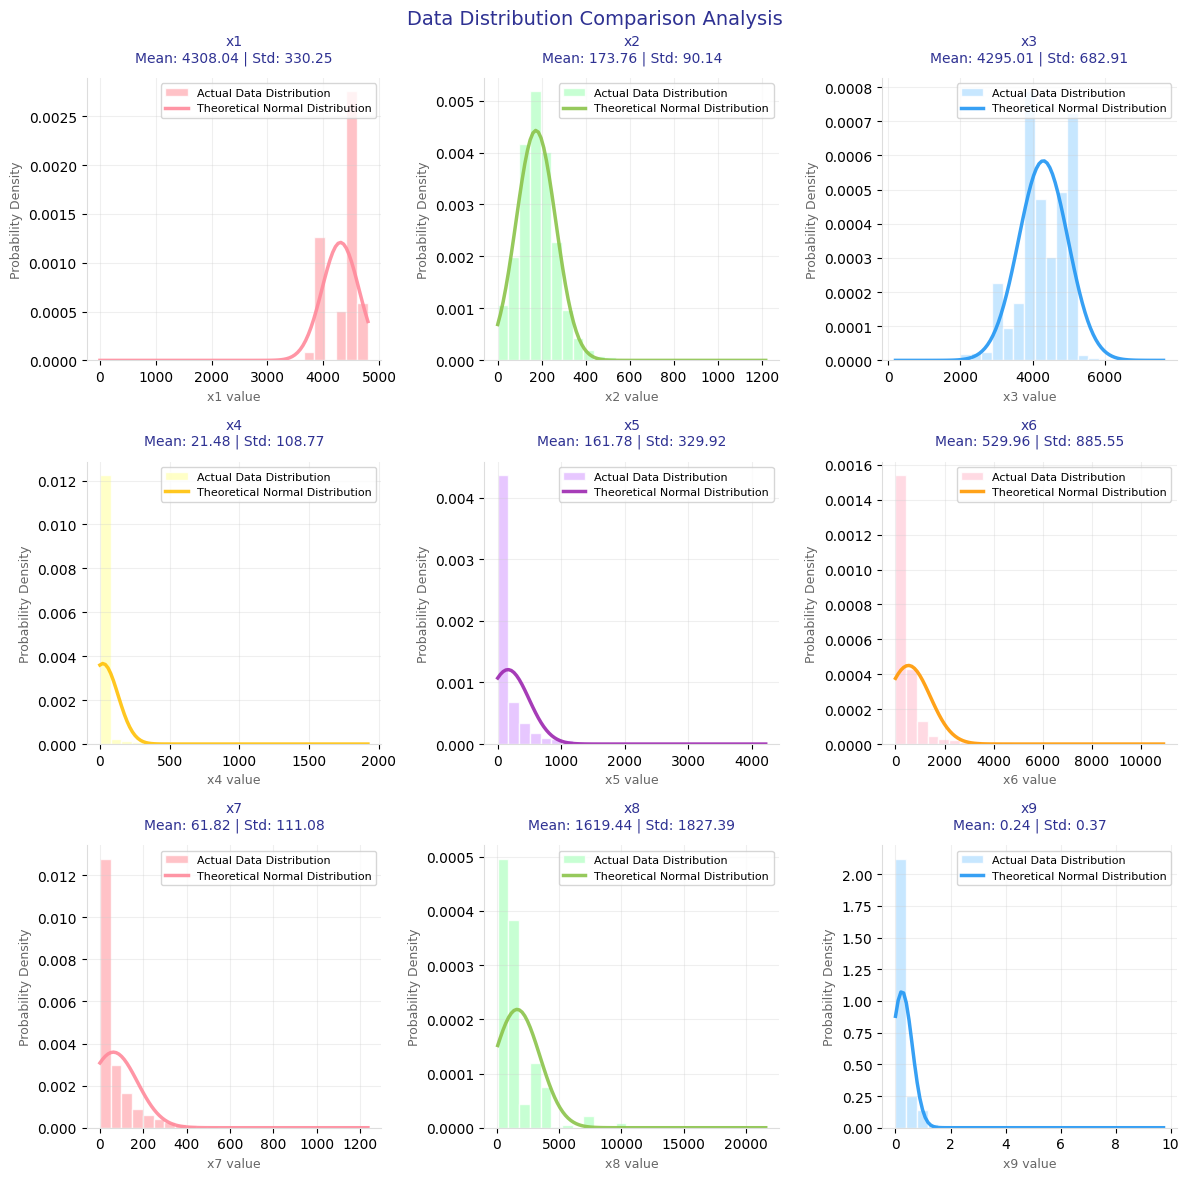


📝 해석 방법:
   - 파스텔 색상 막대: 실제 데이터의 분포
   - 곡선: 같은 평균/표준편차를 가진 이론적 정규분포
   - 두 분포가 비슷하면 → 정규분포에 가까움
   - 두 분포가 다르면 → 비정규분포 (변환 필요할 수 있음)


In [20]:
print("="*60)
print("5️⃣ 분포 시각화")
print("="*60)

# 파스텔 색상 팔레트 정의
pastel_colors = {
    'hist_colors': ['#FFB3BA', '#BAFFC9', '#BAE1FF', '#FFFFBA', '#E1BAFF', '#FFD1DC'],
    'normal_colors': ['#FF8A9B', '#8BC34A', '#2196F3', '#FFC107', '#9C27B0', '#FF9800'],
    'box_colors': ['#F8BBD9', '#B8E6B8', '#B3D9FF', '#FFF2CC', '#E1BEE7', '#FFCC80']
}

# 📊 변수별 그리드 설정 계산
n_features = len(numeric_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

print(f"📈 시각화 대상: {n_features}개 변수")
print(f"📐 그리드 구성: {n_rows}행 × {n_cols}열")

# ===================================================================
# 📊 1. 히스토그램 + 정규분포 곡선
# ===================================================================

# subplot 그리드 생성 (크기 축소: 15 → 12, 5 → 4)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle('Data Distribution Comparison Analysis', fontsize=14, y=0.98, color='#2E3192')

# axes 배열 정규화
if n_features == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

# 각 수치형 변수에 대해 히스토그램 생성
for i, col in enumerate(numeric_features):
    row, col_idx = divmod(i, n_cols)
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

    # 결측치 제거된 데이터 추출
    data = df[col].dropna()
    print(f"   📈 {col}: {len(data)}개 유효 데이터 (결측치 {df[col].isnull().sum()}개 제외)")

    # 히스토그램 그리기
    color_idx = i % len(pastel_colors['hist_colors'])
    ax.hist(data,
            bins=25,                         # bins 수 축소 (30 → 25)
            density=True,
            alpha=0.8,
            color=pastel_colors['hist_colors'][color_idx],
            edgecolor='white',
            linewidth=1,                     # 선 두께 축소
            label='Actual Data Distribution')

    # 정규분포 곡선 오버레이
    x = np.linspace(data.min(), data.max(), 100)
    normal_curve = stats.norm.pdf(x, data.mean(), data.std())
    ax.plot(x, normal_curve,
            color=pastel_colors['normal_colors'][color_idx],
            linewidth=2.5,                   # 선 두께 축소 (3 → 2.5)
            linestyle='-',
            label='Theoretical Normal Distribution',
            alpha=0.9)

    # 제목과 라벨 설정
    ax.set_title(f'{col}\nMean: {data.mean():.2f} | Std: {data.std():.2f}',
                fontsize=10, pad=12, color='#2E3192')  # 폰트 크기 축소 (12 → 10)
    ax.set_xlabel(f'{col} value', fontsize=9, color='#666666')
    ax.set_ylabel('Probability Density', fontsize=9, color='#666666')

    # 범례와 격자 추가
    ax.legend(fontsize=8, loc='upper right')  # 범례 크기 축소
    ax.grid(True, alpha=0.3, color='#CCCCCC')

    # 축 스타일링
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

# 사용하지 않는 빈 subplot들 제거
for j in range(i + 1, n_rows * n_cols):
    row, col_idx = divmod(j, n_cols)
    fig.delaxes(axes[row, col_idx] if n_rows > 1 else axes[col_idx])

plt.tight_layout()
plt.show()

print("\n📝 해석 방법:")
print("   - 파스텔 색상 막대: 실제 데이터의 분포")
print("   - 곡선: 같은 평균/표준편차를 가진 이론적 정규분포")
print("   - 두 분포가 비슷하면 → 정규분포에 가까움")
print("   - 두 분포가 다르면 → 비정규분포 (변환 필요할 수 있음)")

📝 Q-Q 플롯이란?
   - 실제 데이터의 분위수 vs 정규분포의 분위수를 비교
   - 직선에 가까우면 정규분포, 곡선이면 비정규분포


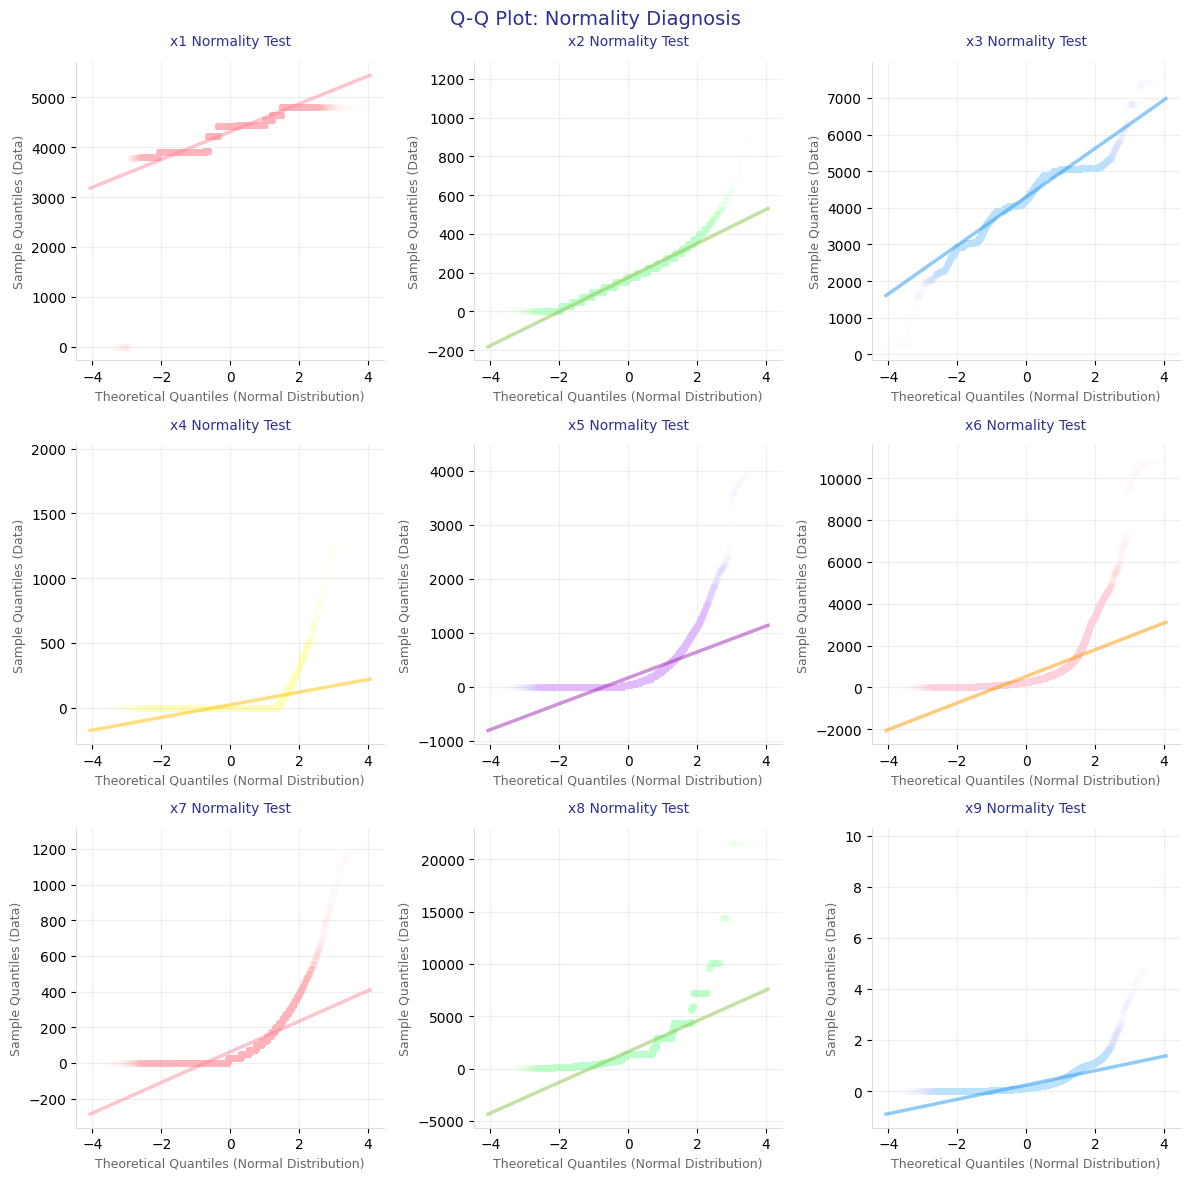


📝 해석 방법:
   - 점들이 직선 위에 위치 → 정규분포
   - 점들이 S자 곡선 → 왜도(skewness) 존재
   - 점들이 아래로 볼록/위로 볼록 → 첨도(kurtosis) 문제
   - 점들이 직선에서 크게 벗어남 → 비정규분포


In [21]:
# ===================================================================
# 📈 2. Q-Q 플롯 (Quantile-Quantile Plot)
# ===================================================================
print("📝 Q-Q 플롯이란?")
print("   - 실제 데이터의 분위수 vs 정규분포의 분위수를 비교")
print("   - 직선에 가까우면 정규분포, 곡선이면 비정규분포")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))  # 크기 축소
fig.suptitle('Q-Q Plot: Normality Diagnosis', fontsize=14, y=0.98, color='#2E3192')

# axes 배열 정규화
if n_features == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_features):
    row, col_idx = divmod(i, n_cols)
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

    # Q-Q 플롯 생성
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)

    # 🎨 스타일링
    color_idx = i % len(pastel_colors['hist_colors'])

    # 데이터 포인트 스타일링
    ax.get_lines()[0].set_markerfacecolor(pastel_colors['hist_colors'][color_idx])
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[0].set_markersize(5)
    ax.get_lines()[0].set_alpha(0.01)

    # 이론적 직선 스타일링
    ax.get_lines()[1].set_color(pastel_colors['normal_colors'][color_idx])
    ax.get_lines()[1].set_linewidth(2.5)
    ax.get_lines()[1].set_alpha(0.5)

    ax.set_title(f'{col} Normality Test', fontsize=10, pad=12, color='#2E3192')
    ax.set_xlabel('Theoretical Quantiles (Normal Distribution)', fontsize=9, color='#666666')
    ax.set_ylabel('Sample Quantiles (Data)', fontsize=9, color='#666666')

    ax.grid(True, alpha=0.3, color='#CCCCCC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

# 빈 subplot 제거
for j in range(i + 1, n_rows * n_cols):
    row, col_idx = divmod(j, n_cols)
    fig.delaxes(axes[row, col_idx] if n_rows > 1 else axes[col_idx])

plt.tight_layout()
plt.show()

print("\n📝 해석 방법:")
print("   - 점들이 직선 위에 위치 → 정규분포")
print("   - 점들이 S자 곡선 → 왜도(skewness) 존재")
print("   - 점들이 아래로 볼록/위로 볼록 → 첨도(kurtosis) 문제")
print("   - 점들이 직선에서 크게 벗어남 → 비정규분포")

📝 박스플롯이란?
   - 상자: 1사분위수(Q1) ~ 3사분위수(Q3), 중간선: 중위수(Q2)
   - 수염: 1.5×IQR 범위
   - 점들: 이상치 (수염 밖의 값들)


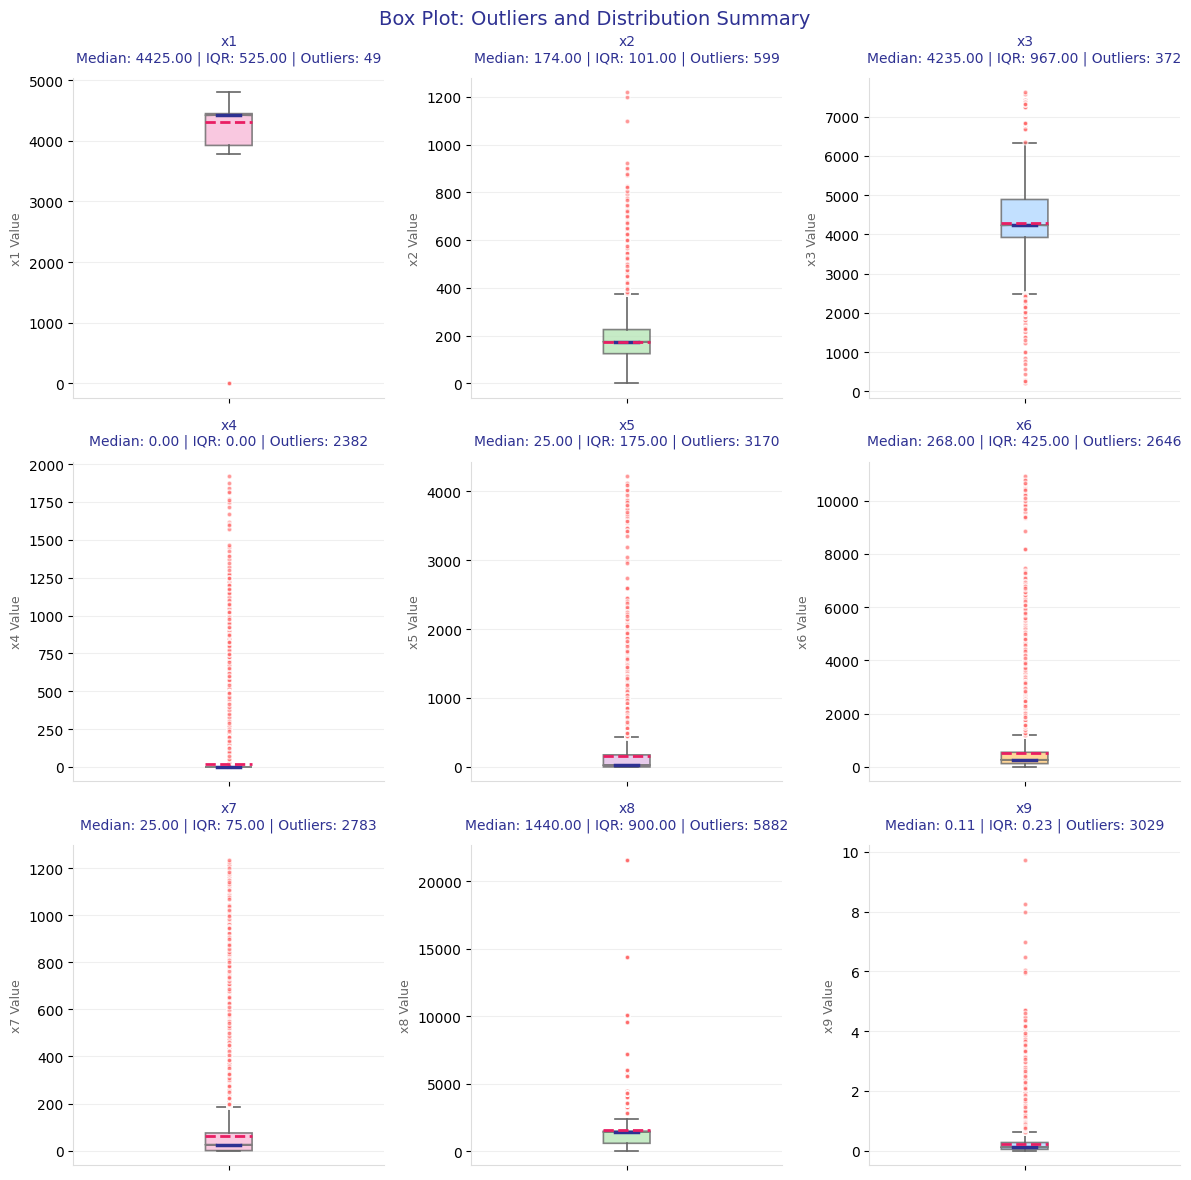


 📝 해석 방법:
   - 상자 크기: IQR (데이터의 50% 포함 범위)
   - 실선 (파란색): 중위수 (50%ile)
   - 점선 (분홍색): 평균값
   - 빨간 점들: 이상치 (1.5×IQR 범위 밖)
   - 상자가 길수록: 데이터 분산이 큼
   - 중위수가 상자 중앙에서 벗어나면: 분포가 치우침


In [22]:
# ===================================================================
# 📦 3. 박스플롯 (Box Plot)
# ===================================================================
print("📝 박스플롯이란?")
print("   - 상자: 1사분위수(Q1) ~ 3사분위수(Q3), 중간선: 중위수(Q2)")
print("   - 수염: 1.5×IQR 범위")
print("   - 점들: 이상치 (수염 밖의 값들)")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))  # 크기 축소
fig.suptitle('Box Plot: Outliers and Distribution Summary', fontsize=14, y=0.98, color='#2E3192')

# axes 배열 정규화
if n_features == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_features):
    row, col_idx = divmod(i, n_cols)
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

    # 📦 박스플롯 생성
    bp = ax.boxplot(df[col].dropna(),
                    patch_artist=True,
                    notch=True,
                    showmeans=True,
                    meanline=True)

    # 🎨 파스텔 색상 적용
    color_idx = i % len(pastel_colors['box_colors'])

    # 상자 색상 설정
    bp['boxes'][0].set_facecolor(pastel_colors['box_colors'][color_idx])
    bp['boxes'][0].set_edgecolor('#666666')
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][0].set_linewidth(1.2)

    # 중위수 선 스타일링
    bp['medians'][0].set_color('#2E3192')
    bp['medians'][0].set_linewidth(2.5)

    # 평균 선 스타일링
    bp['means'][0].set_color('#E91E63')
    bp['means'][0].set_linewidth(2)
    bp['means'][0].set_linestyle('--')

    # 수염 스타일링
    for whisker in bp['whiskers']:
        whisker.set_color('#666666')
        whisker.set_linewidth(1.2)
        whisker.set_linestyle('-')

    # 이상치 점 스타일링
    for flier in bp['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor('#FF6B6B')
        flier.set_markeredgecolor('white')
        flier.set_markersize(3.5)
        flier.set_alpha(0.7)

    # 캡(수염 끝) 스타일링
    for cap in bp['caps']:
        cap.set_color('#666666')
        cap.set_linewidth(1.2)

    # 📊 통계 정보 계산 및 표시
    data = df[col].dropna()
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    outlier_count = len(data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)])

    ax.set_title(f'{col}\nMedian: {median:.2f} | IQR: {iqr:.2f} | Outliers: {outlier_count}',
                fontsize=10, pad=12, color='#2E3192')  # 폰트 크기 축소
    ax.set_ylabel(f'{col} Value', fontsize=9, color='#666666')

    # 격자와 축 스타일링
    ax.grid(True, alpha=0.3, color='#CCCCCC', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

    # x축 라벨 제거 (박스플롯은 x축 의미 없음)
    ax.set_xticklabels([])

# 빈 subplot 제거
for j in range(i + 1, n_rows * n_cols):
    row, col_idx = divmod(j, n_cols)
    fig.delaxes(axes[row, col_idx] if n_rows > 1 else axes[col_idx])

plt.tight_layout()
plt.show()

print("\n 📝 해석 방법:")
print("   - 상자 크기: IQR (데이터의 50% 포함 범위)")
print("   - 실선 (파란색): 중위수 (50%ile)")
print("   - 점선 (분홍색): 평균값")
print("   - 빨간 점들: 이상치 (1.5×IQR 범위 밖)")
print("   - 상자가 길수록: 데이터 분산이 큼")
print("   - 중위수가 상자 중앙에서 벗어나면: 분포가 치우침")

### 3.6 Categorical 변수 분석

In [23]:
print("="*60)
print("🏷️ 6️⃣ 범주형 변수 분석")
print("="*60)

print("📝 범주형 변수 분석이란?")
print("   - 질적 데이터의 특성을 파악하는 분석")
print("   - 각 범주의 빈도, 분포, 패턴을 확인")
print("   - 데이터 불균형, 희소 범주 등을 탐지")
print("   - 타겟 변수와의 관계 분석 기초 자료 제공")

# 전체 범주형 변수 요약 정보
print(f"\n📊 범주형 변수 전체 요약:")
print(f"   🔢 총 범주형 변수 개수: {len(categorical_features)}개")
print(f"   📋 변수 목록: {categorical_features}")

# 각 범주형 변수별 상세 분석
for idx, col in enumerate(categorical_features):
    print("\n" + "="*50)
    print(f"📊 변수 {idx+1}/{len(categorical_features)}: {col}")
    print("="*50)

    # ===================================================================
    # 📊 1. 기본 정보 및 요약 통계
    # ===================================================================

    print("📋 1. 기본 정보")
    print("-" * 30)

    # 결측치 제거된 데이터
    valid_data = df[col].dropna()
    total_count = len(df)
    valid_count = len(valid_data)
    missing_count = df[col].isnull().sum()

    # 빈도 계산
    value_counts = df[col].value_counts()
    unique_count = df[col].nunique()

    # 기본 통계 정보
    print(f"   📊 전체 데이터 수: {total_count:,}개")
    print(f"   ✅ 유효 데이터 수: {valid_count:,}개")
    print(f"   ❌ 결측치 수: {missing_count:,}개 ({missing_count/total_count*100:.1f}%)")
    print(f"   🔢 고유값 개수: {unique_count}개")

    # 최빈값 정보
    if not df[col].mode().empty:
        most_frequent = df[col].mode()[0]
        most_frequent_count = value_counts.iloc[0]
        most_frequent_ratio = most_frequent_count / valid_count * 100
        print(f"   🎯 최빈값: '{most_frequent}' ({most_frequent_count}개, {most_frequent_ratio:.1f}%)")
    else:
        print(f"   🎯 최빈값: 없음")

    # 희소 범주 분석 (1% 미만 범주)
    rare_categories = value_counts[value_counts / valid_count < 0.01]
    if len(rare_categories) > 0:
        print(f"   ⚠️ 희소 범주 (1% 미만): {len(rare_categories)}개")
        print(f"     - {list(rare_categories.index[:3])}{'...' if len(rare_categories) > 3 else ''}")

    # ===================================================================
    # 📊 2. 상세 빈도 분포 테이블
    # ===================================================================

    print(f"\n📈 2. 빈도 분포 분석")
    print("-" * 30)

    # 빈도 테이블 생성
    freq_table = pd.DataFrame({
        '범주': value_counts.index,
        '빈도': value_counts.values,
        '비율(%)': (value_counts.values / valid_count * 100).round(2),
        '누적빈도': value_counts.cumsum().values,
        '누적비율(%)': (value_counts.cumsum().values / valid_count * 100).round(2)
    })

    # 표시할 행 수 결정 (최대 15개)
    display_rows = min(15, len(freq_table))
    print(f"📋 빈도 분포 테이블 (상위 {display_rows}개):")

    # 예쁘게 포맷된 테이블 출력
    display_table = freq_table.head(display_rows).copy()
    display_table.index = range(1, len(display_table) + 1)
    print(display_table.to_string(index=True))

    if len(freq_table) > display_rows:
        remaining = len(freq_table) - display_rows
        print(f"   ... 외 {remaining}개 범주 더 있음")

    # ===================================================================
    # 💡 3. 데이터 품질 평가 및 권장사항
    # ===================================================================

    print(f"\n💡 3. 데이터 품질 평가 및 권장사항")
    print("-" * 40)

    recommendations = []
    quality_issues = []

    # 결측치 평가
    if missing_count / total_count > 0.1:  # 10% 이상
        quality_issues.append(f"높은 결측률 ({missing_count/total_count*100:.1f}%)")
        recommendations.append("🔧 결측치 처리 전략 수립 필요")

    # 불균형 평가
    if most_frequent_ratio > 80:
        quality_issues.append(f"심한 클래스 불균형 (최빈값 {most_frequent_ratio:.1f}%)")
        recommendations.append("⚖️ 클래스 불균형 처리 고려 (SMOTE, 가중치 등)")
    elif most_frequent_ratio > 60:
        quality_issues.append(f"클래스 불균형 존재 (최빈값 {most_frequent_ratio:.1f}%)")
        recommendations.append("📊 클래스 불균형 모니터링 권장")

    # 희소 범주 평가
    if len(rare_categories) > unique_count * 0.3:  # 전체의 30% 이상이 희소범주
        quality_issues.append(f"다수의 희소 범주 ({len(rare_categories)}개)")
        recommendations.append("🗂️ 희소 범주 그룹핑 또는 제거 고려")

    # 범주 수 평가
    if unique_count > valid_count * 0.1:  # 고유값이 전체 데이터의 10% 이상
        quality_issues.append(f"과도한 범주 수 ({unique_count}개)")
        recommendations.append("📂 범주 재분류 또는 차원 축소 고려")

    # 결과 출력
    if quality_issues:
        print("   ⚠️ 발견된 품질 이슈:")
        for issue in quality_issues:
            print(f"     - {issue}")
    else:
        print("   ✅ 주요 품질 이슈 없음")

    if recommendations:
        print("   💡 권장사항:")
        for rec in recommendations:
            print(f"     - {rec}")
    else:
        print("   ✅ 추가 처리 불필요")

🏷️ 6️⃣ 범주형 변수 분석
📝 범주형 변수 분석이란?
   - 질적 데이터의 특성을 파악하는 분석
   - 각 범주의 빈도, 분포, 패턴을 확인
   - 데이터 불균형, 희소 범주 등을 탐지
   - 타겟 변수와의 관계 분석 기초 자료 제공

📊 범주형 변수 전체 요약:
   🔢 총 범주형 변수 개수: 7개
   📋 변수 목록: ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']

📊 변수 1/7: lot_cd
📋 1. 기본 정보
------------------------------
   📊 전체 데이터 수: 28,812개
   ✅ 유효 데이터 수: 28,812개
   ❌ 결측치 수: 0개 (0.0%)
   🔢 고유값 개수: 1개
   🎯 최빈값: 'lot_cd_1' (28812개, 100.0%)

📈 2. 빈도 분포 분석
------------------------------
📋 빈도 분포 테이블 (상위 1개):
         범주     빈도  비율(%)   누적빈도  누적비율(%)
1  lot_cd_1  28812  100.0  28812    100.0

💡 3. 데이터 품질 평가 및 권장사항
----------------------------------------
   ⚠️ 발견된 품질 이슈:
     - 심한 클래스 불균형 (최빈값 100.0%)
   💡 권장사항:
     - ⚖️ 클래스 불균형 처리 고려 (SMOTE, 가중치 등)

📊 변수 2/7: hbm_type
📋 1. 기본 정보
------------------------------
   📊 전체 데이터 수: 28,812개
   ✅ 유효 데이터 수: 28,812개
   ❌ 결측치 수: 0개 (0.0%)
   🔢 고유값 개수: 1개
   🎯 최빈값: 'type_1' (28812개, 100.0%)

📈 2. 빈도 분포 분석
------------------------------
📋 빈도 분포 테이블 (상위 1개):


## 📊 4. 변수간 관계 분석

### 4.1 설명 변수(X) 간 관계 분석

In [24]:
# ================================
# 설명 변수(X) 간 상관분석
# ================================

print("=" * 80)
print("📊 설명 변수(X) 간 상관분석")
print("=" * 80)

# 수치형 설명 변수만 선택 (타겟 변수 제외)
feature_data = df[numeric_features].select_dtypes(include=[np.number])

print(f"🔍 분석 대상 변수 ({len(feature_data.columns)}개):")
print(f"   {list(feature_data.columns)}")
print(f"   데이터 크기: {feature_data.shape}")

if len(feature_data.columns) < 2:
    print("\n⚠️ 상관분석을 위한 충분한 수치형 변수가 없습니다.")
    print("   최소 2개 이상의 수치형 변수가 필요합니다.")
else:
    # ================================
    # 1. 상관계수 계산
    # ================================

    print(f"\n" + "=" * 60)
    print("1. 상관계수 계산 (Pearson & Spearman)")
    print("=" * 60)

    # Pearson 상관계수 행렬
    pearson_corr = feature_data.corr(method='pearson')

    # Spearman 상관계수 행렬
    spearman_corr = feature_data.corr(method='spearman')

    # 모든 변수 쌍에 대한 상관계수 비교
    correlation_pairs = []

    for var1, var2 in combinations(feature_data.columns, 2):
        # 결측치 제거
        clean_data = feature_data[[var1, var2]].dropna()

        if len(clean_data) > 2:
            # Pearson 상관계수와 p-value
            pearson_r, pearson_p = pearsonr(clean_data[var1], clean_data[var2])

            # Spearman 상관계수와 p-value
            spearman_r, spearman_p = spearmanr(clean_data[var1], clean_data[var2])

            # 차이 계산
            difference = abs(pearson_r - spearman_r)

            correlation_pairs.append({
                'Variable_1': var1,
                'Variable_2': var2,
                'Pearson_Corr': pearson_r,
                'Pearson_p_value': pearson_p,
                'Spearman_Corr': spearman_r,
                'Spearman_p_value': spearman_p,
                'Difference': difference,
                'Abs_Pearson': abs(pearson_r)
            })

    # 데이터프레임으로 변환
    correlation_df = pd.DataFrame(correlation_pairs)

    # 상관계수 절댓값 기준으로 정렬
    correlation_df = correlation_df.sort_values('Abs_Pearson', ascending=False)

    # 결과 출력
    print(f"📈 변수 쌍별 상관계수 (총 {len(correlation_df)}개 쌍)")
    print("=" * 60)


📊 설명 변수(X) 간 상관분석
🔍 분석 대상 변수 (9개):
   ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
   데이터 크기: (28812, 9)

1. 상관계수 계산 (Pearson & Spearman)
📈 변수 쌍별 상관계수 (총 36개 쌍)



2. 상관계수 시각화


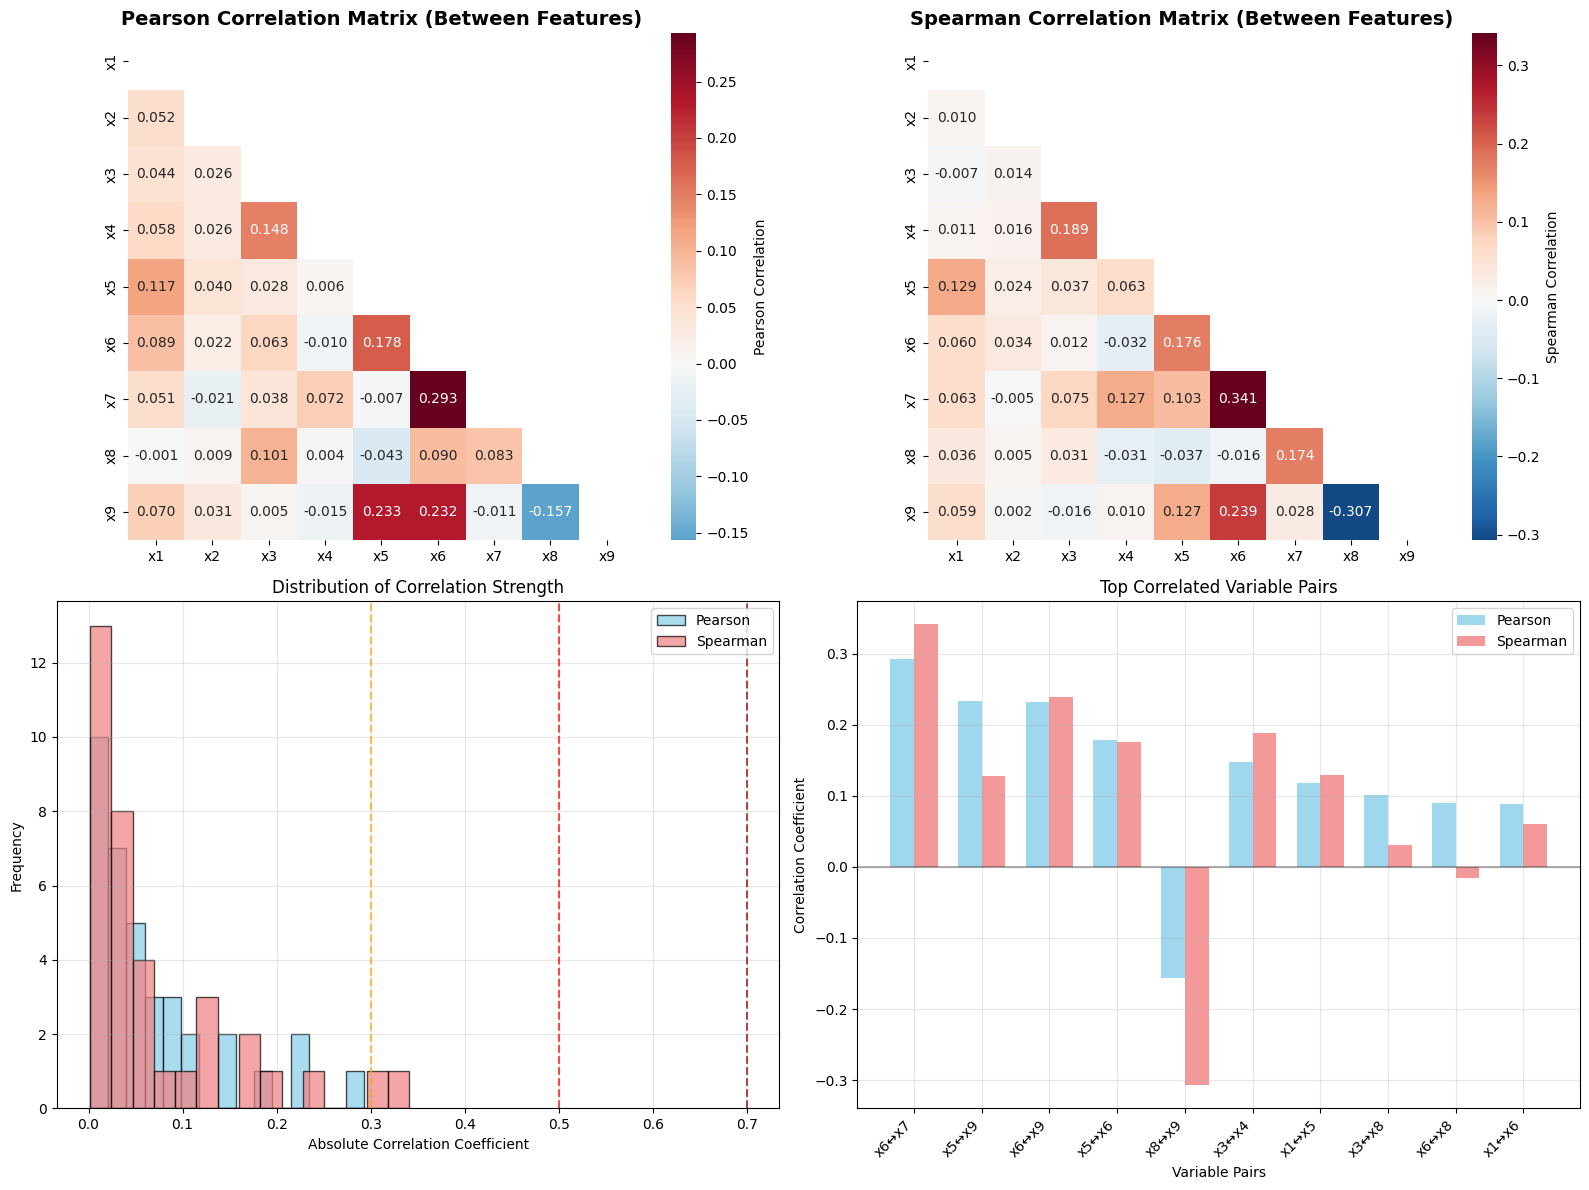

In [25]:
# ================================
# 2. 시각화
# ================================

if len(feature_data.columns) < 2:
    print("\n⚠️ 상관분석을 위한 충분한 수치형 변수가 없습니다.")
    print("   최소 2개 이상의 수치형 변수가 필요합니다.")
else:
    print(f"\n" + "=" * 60)
    print("2. 상관계수 시각화")
    print("=" * 60)

    # 시각화 설정
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1) Pearson 상관계수 히트맵
    mask_pearson = np.triu(np.ones_like(pearson_corr, dtype=bool))
    sns.heatmap(pearson_corr, annot=True, cmap='RdBu_r', center=0,
                square=True, fmt='.3f', cbar_kws={'label': 'Pearson Correlation'},
                mask=mask_pearson, ax=axes[0, 0])
    axes[0, 0].set_title('Pearson Correlation Matrix (Between Features)', fontsize=14, fontweight='bold')

    # 2) Spearman 상관계수 히트맵
    mask_spearman = np.triu(np.ones_like(spearman_corr, dtype=bool))
    sns.heatmap(spearman_corr, annot=True, cmap='RdBu_r', center=0,
                square=True, fmt='.3f', cbar_kws={'label': 'Spearman Correlation'},
                mask=mask_spearman, ax=axes[0, 1])
    axes[0, 1].set_title('Spearman Correlation Matrix (Between Features)', fontsize=14, fontweight='bold')

    # 3) 상관계수 강도 분포
    axes[1, 0].hist(correlation_df['Abs_Pearson'], bins=15, alpha=0.7,
                   color='skyblue', edgecolor='black', label='Pearson')
    axes[1, 0].hist(correlation_df['Spearman_Corr'].abs(), bins=15, alpha=0.7,
                   color='lightcoral', edgecolor='black', label='Spearman')
    axes[1, 0].set_xlabel('Absolute Correlation Coefficient')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Correlation Strength')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 강도별 구간 표시
    axes[1, 0].axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Medium (0.3)')
    axes[1, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Strong (0.5)')
    axes[1, 0].axvline(x=0.7, color='darkred', linestyle='--', alpha=0.7, label='Very Strong (0.7)')

    # 4) 상위 상관계수 변수 쌍 바 차트
    top_pairs = correlation_df.head(10)
    if len(top_pairs) > 0:
        pair_labels = [f"{row['Variable_1'][:8]}↔{row['Variable_2'][:8]}"
                      for _, row in top_pairs.iterrows()]

        x_pos = np.arange(len(top_pairs))
        width = 0.35

        axes[1, 1].bar(x_pos - width/2, top_pairs['Pearson_Corr'],
                      width, label='Pearson', alpha=0.8, color='skyblue')
        axes[1, 1].bar(x_pos + width/2, top_pairs['Spearman_Corr'],
                      width, label='Spearman', alpha=0.8, color='lightcoral')

        axes[1, 1].set_xlabel('Variable Pairs')
        axes[1, 1].set_ylabel('Correlation Coefficient')
        axes[1, 1].set_title('Top Correlated Variable Pairs')
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(pair_labels, rotation=45, ha='right')
        axes[1, 1].legend()
        axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


3. 설명 변수 간 페어플롯


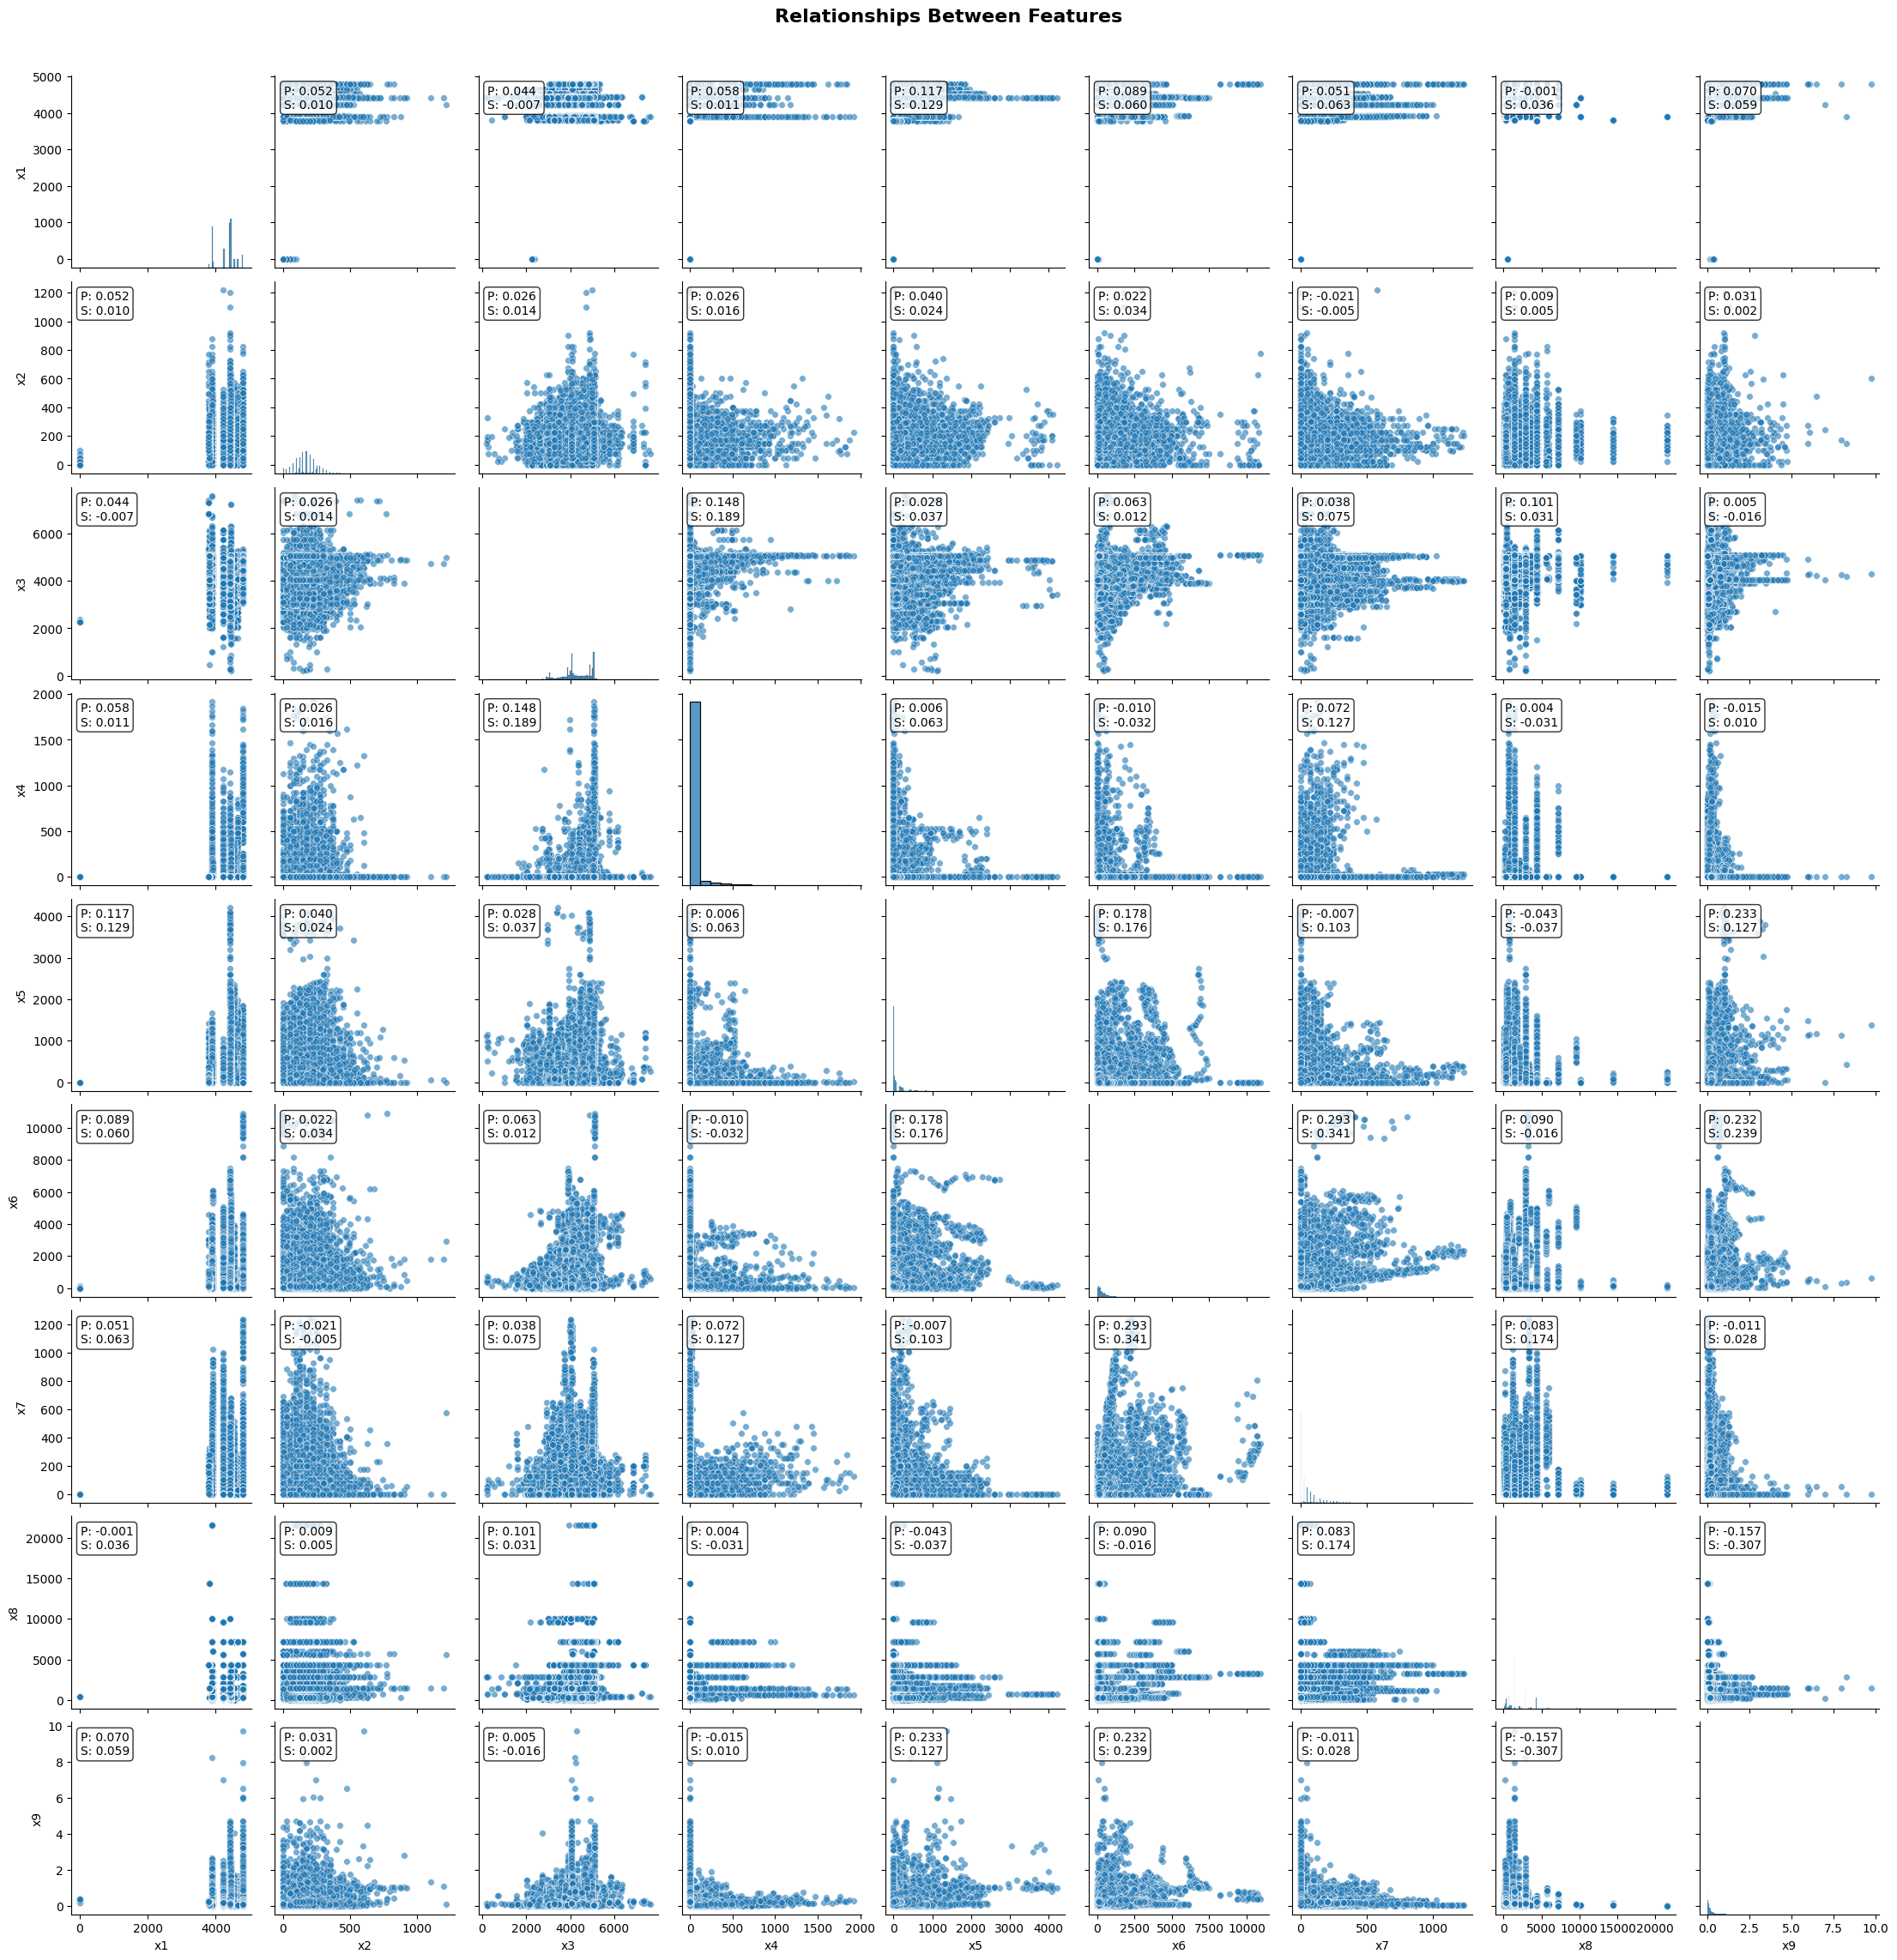

In [26]:
# ================================
# 3. 페어플롯 (설명 변수만)
# ================================

# 변수가 너무 많으면 일부만 선택
max_vars = 10

if len(feature_data.columns) < 2:
    print("\n⚠️ 상관분석을 위한 충분한 수치형 변수가 없습니다.")
    print("   최소 2개 이상의 수치형 변수가 필요합니다.")
else:
    print(f"\n" + "=" * 60)
    print("3. 설명 변수 간 페어플롯")
    print("=" * 60)

    if len(feature_data.columns) > max_vars:
        # 타겟과 상관관계가 높은 변수들 선택 (있다면)
        if target_col in df.columns:
            target_corr = df[numeric_features + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
            selected_vars = target_corr.head(max_vars).index.tolist()
            selected_vars = [var for var in selected_vars if var != target_col][:max_vars]
        else:
            selected_vars = feature_data.columns[:max_vars].tolist()

        print(f"상위 {len(selected_vars)}개 변수만 시각화:")
        print(f"   {selected_vars}")
        plot_data = feature_data[selected_vars]
    else:
        plot_data = feature_data

    # 페어플롯 생성
    if len(plot_data.columns) > 1:
        g = sns.pairplot(plot_data, diag_kind='hist',
                        plot_kws={'alpha': 0.6, 's': 30})
        g.fig.suptitle('Relationships Between Features', y=1.02, fontsize=16, fontweight='bold')

        # 각 서브플롯에 상관계수 추가
        for i, var1 in enumerate(plot_data.columns):
            for j, var2 in enumerate(plot_data.columns):
                if i != j:
                    corr_pearson = plot_data[var1].corr(plot_data[var2], method='pearson')
                    corr_spearman = plot_data[var1].corr(plot_data[var2], method='spearman')

                    ax = g.axes[i, j]
                    ax.text(0.05, 0.95, f'P: {corr_pearson:.3f}\nS: {corr_spearman:.3f}',
                           transform=ax.transAxes, fontsize=10, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.show()

In [27]:
# ================================
# 4. 다중공선성 분석
# ================================

if len(feature_data.columns) < 2:
    print("\n⚠️ 상관분석을 위한 충분한 수치형 변수가 없습니다.")
    print("   최소 2개 이상의 수치형 변수가 필요합니다.")
else:
    print(f"\n" + "=" * 60)
    print("4. 다중공선성 분석")
    print("=" * 60)

    # 강한 상관관계 (|r| >= 0.7) 찾기
    strong_corr = correlation_df[correlation_df['Abs_Pearson'] >= 0.7]

    if len(strong_corr) > 0:
        print(f"🔴 강한 상관관계 (|r| >= 0.7) 발견 ({len(strong_corr)}개 쌍):")
        print("   → 다중공선성 문제 가능성 높음")
        print("-" * 50)

        for _, row in strong_corr.iterrows():
            print(f"   {row['Variable_1']} ↔ {row['Variable_2']}: {row['Pearson_Corr']:.4f}")
    else:
        print("✅ 강한 상관관계 (|r| >= 0.7) 없음")

    # 중간 상관관계 (0.5 <= |r| < 0.7) 찾기
    medium_corr = correlation_df[(correlation_df['Abs_Pearson'] >= 0.5) &
                                (correlation_df['Abs_Pearson'] < 0.7)]

    if len(medium_corr) > 0:
        print(f"\n🟠 중간 상관관계 (0.5 ≤ |r| < 0.7) 발견 ({len(medium_corr)}개 쌍):")
        print("   → 주의 필요")
        print("-" * 50)

        for _, row in medium_corr.iterrows():
            print(f"   {row['Variable_1']} ↔ {row['Variable_2']}: {row['Pearson_Corr']:.4f}")



4. 다중공선성 분석
✅ 강한 상관관계 (|r| >= 0.7) 없음


In [28]:
# ================================
# 5. 결과 요약
# ================================

if len(feature_data.columns) < 2:
    print("\n⚠️ 상관분석을 위한 충분한 수치형 변수가 없습니다.")
    print("   최소 2개 이상의 수치형 변수가 필요합니다.")
else:
    print(f"\n" + "=" * 60)
    print("5. 결과 요약")
    print("=" * 60)

    print(f"📊 기본 통계:")
    print(f"   - 총 변수 쌍: {len(correlation_df)}개")
    print(f"   - 평균 상관계수 (절댓값): {correlation_df['Abs_Pearson'].mean():.4f}")
    print(f"   - 최대 상관계수 (절댓값): {correlation_df['Abs_Pearson'].max():.4f}")
    print(f"   - 최소 상관계수 (절댓값): {correlation_df['Abs_Pearson'].min():.4f}")

    # 상관계수 강도별 분포
    very_strong = len(correlation_df[correlation_df['Abs_Pearson'] >= 0.7])
    strong = len(correlation_df[(correlation_df['Abs_Pearson'] >= 0.5) &
                               (correlation_df['Abs_Pearson'] < 0.7)])
    medium = len(correlation_df[(correlation_df['Abs_Pearson'] >= 0.3) &
                               (correlation_df['Abs_Pearson'] < 0.5)])
    weak = len(correlation_df[correlation_df['Abs_Pearson'] < 0.3])

    print(f"\n📈 상관계수 강도별 분포:")
    print(f"   - 매우 강함 (≥0.7): {very_strong}개 ({very_strong/len(correlation_df)*100:.1f}%)")
    print(f"   - 강함 (0.5-0.7): {strong}개 ({strong/len(correlation_df)*100:.1f}%)")
    print(f"   - 중간 (0.3-0.5): {medium}개 ({medium/len(correlation_df)*100:.1f}%)")
    print(f"   - 약함 (<0.3): {weak}개 ({weak/len(correlation_df)*100:.1f}%)")



5. 결과 요약
📊 기본 통계:
   - 총 변수 쌍: 36개
   - 평균 상관계수 (절댓값): 0.0687
   - 최대 상관계수 (절댓값): 0.2928
   - 최소 상관계수 (절댓값): 0.0013

📈 상관계수 강도별 분포:
   - 매우 강함 (≥0.7): 0개 (0.0%)
   - 강함 (0.5-0.7): 0개 (0.0%)
   - 중간 (0.3-0.5): 0개 (0.0%)
   - 약함 (<0.3): 36개 (100.0%)


### 4.2 개별 설명변수 (X)와 종속변수(Y) 간 관계 분석

In [29]:
# =============================================================================
# 개별 설명변수 (X)와 종속변수(Y) 간 관계 분석
# =============================================================================

# =============================================================================
# 1. 데이터 타입 자동 식별 함수
# =============================================================================

def identify_variable_types(df, target_col):
    """
    데이터프레임의 변수 타입을 자동으로 식별하는 함수

    Parameters:
    - df: 데이터프레임
    - target_col: 종속변수 컬럼명

    Returns:
    - dict: 변수 타입별 컬럼 리스트
    """

    # 종속변수 제외한 설명변수들
    feature_cols = [col for col in df.columns if col != target_col]

    # 변수 타입 분류
    continuous_vars = []
    categorical_vars = []

    for col in feature_cols:
        # 데이터 타입이 숫자형이고 고유값이 많으면 연속형
        if df[col].dtype in ['int64', 'float64']:
            unique_ratio = df[col].nunique() / len(df)
            if unique_ratio > 0.05:  # 고유값 비율이 5% 이상이면 연속형
                continuous_vars.append(col)
            else:
                categorical_vars.append(col)
        else:
            categorical_vars.append(col)

    return {
        'continuous': continuous_vars,
        'categorical': categorical_vars,
        'target': target_col
    }

In [30]:
# =============================================================================
# 2. 연속형 변수 vs 종속변수 분석
# =============================================================================

def analyze_continuous_relationship(df, x_col, y_col, figsize=(10, 6)):
    """
    연속형 설명변수와 종속변수 간의 관계 분석

    Parameters:
    - df: 데이터프레임
    - x_col: 설명변수 컬럼명
    - y_col: 종속변수 컬럼명
    - figsize: 그래프 크기
    """

    print(f"\n{'='*60}")
    print(f"📊 연속형 변수 분석: {x_col} vs {y_col}")
    print(f"{'='*60}")

    # 결측치 처리 (forward fill 방식)
    clean_data = df[[x_col, y_col]].copy()

    # pandas 버전에 따른 호환성 처리
    try:
        clean_data = clean_data.fillna(method='ffill')  # 이전 값으로 채우기
        clean_data = clean_data.fillna(method='bfill')  # 다음 값으로 채우기
    except:
        # 새로운 pandas 버전
        clean_data = clean_data.ffill()  # 이전 값으로 채우기
        clean_data = clean_data.bfill()  # 다음 값으로 채우기

    # 모든 처리 후에도 결측치가 있다면 제거
    clean_data = clean_data.dropna()

    if len(clean_data) < 2:
        print(f"⚠️  경고: 유효한 데이터가 부족합니다. (유효 데이터: {len(clean_data)}개)")
        return

    print(f"📊 결측치 처리 결과: {len(df)} → {len(clean_data)} (유효 데이터)")

    # 상관계수 계산
    pearson_corr, pearson_p = pearsonr(clean_data[x_col], clean_data[y_col])
    spearman_corr, spearman_p = spearmanr(clean_data[x_col], clean_data[y_col])

    # 결과 출력
    print(f"📈 상관분석 결과:")
    print(f"   • Pearson 상관계수: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
    print(f"   • Spearman 상관계수: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

    # 상관계수 해석
    abs_corr = abs(pearson_corr)
    if abs_corr >= 0.7:
        strength = "strong"
    elif abs_corr >= 0.3:
        strength = "medium"
    else:
        strength = "weak"

    direction = "positive" if pearson_corr > 0 else "negative"
    print(f"   • Analysis: {strength} {direction} corr")

    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1) 산점도
    axes[0, 0].scatter(clean_data[x_col], clean_data[y_col], alpha=0.7, color='#AED6F1', edgecolors='#5DADE2', linewidth=0.5)
    axes[0, 0].set_xlabel(x_col)
    axes[0, 0].set_ylabel(y_col)
    axes[0, 0].set_title(f'Scatter Plot: {x_col} vs {y_col}')
    axes[0, 0].grid(True, alpha=0.3)

    # 회귀선 추가
    if len(clean_data) > 1:
        z = np.polyfit(clean_data[x_col], clean_data[y_col], 1)
        p = np.poly1d(z)
        axes[0, 0].plot(clean_data[x_col], p(clean_data[x_col]), color="#E74C3C", linestyle="--", alpha=0.8, linewidth=2)

    # 2) 히스토그램 (X변수)
    axes[0, 1].hist(clean_data[x_col], bins=25, alpha=0.8, color='#F8BBD9', edgecolor='#E91E63', linewidth=0.5)
    axes[0, 1].set_xlabel(x_col)
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'{x_col} Distribution')
    axes[0, 1].grid(True, alpha=0.3)

    # 3) 히스토그램 (Y변수)
    axes[1, 0].hist(clean_data[y_col], bins=25, alpha=0.8, color='#A9DFBF', edgecolor='#27AE60', linewidth=0.5)
    axes[1, 0].set_xlabel(y_col)
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'{y_col} Distribution')
    axes[1, 0].grid(True, alpha=0.3)

    # 4) 상관계수 요약
    axes[1, 1].text(0.1, 0.8, f'Pearson Correlation', fontsize=11, fontweight='bold')
    axes[1, 1].text(0.1, 0.7, f'r = {pearson_corr:.4f}', fontsize=10)
    axes[1, 1].text(0.1, 0.6, f'p-value = {pearson_p:.4f}', fontsize=10)
    axes[1, 1].text(0.1, 0.4, f'Spearman Correlation', fontsize=11, fontweight='bold')
    axes[1, 1].text(0.1, 0.3, f'ρ = {spearman_corr:.4f}', fontsize=10)
    axes[1, 1].text(0.1, 0.2, f'p-value = {spearman_p:.4f}', fontsize=10)
    axes[1, 1].text(0.1, 0.05, f'Interpretation: {strength} {direction} corr', fontsize=10, fontweight='bold')
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [31]:
# =============================================================================
# 3. 범주형 변수 vs 종속변수 분석 (ANOVA)
# =============================================================================

def analyze_categorical_relationship(df, x_col, y_col, figsize=(10, 6)):
    """
    범주형 설명변수와 종속변수 간의 관계 분석 (ANOVA)

    Parameters:
    - df: 데이터프레임
    - x_col: 설명변수 컬럼명 (범주형)
    - y_col: 종속변수 컬럼명 (연속형)
    - figsize: 그래프 크기
    """

    print(f"\n{'='*60}")
    print(f"📊 범주형 변수 분석: {x_col} vs {y_col}")
    print(f"{'='*60}")

    # 결측치 처리 (forward fill 방식)
    clean_data = df[[x_col, y_col]].copy()

    # pandas 버전에 따른 호환성 처리
    try:
        clean_data = clean_data.fillna(method='ffill')  # 이전 값으로 채우기
        clean_data = clean_data.fillna(method='bfill')  # 다음 값으로 채우기
    except:
        # 새로운 pandas 버전
        clean_data = clean_data.ffill()  # 이전 값으로 채우기
        clean_data = clean_data.bfill()  # 다음 값으로 채우기

    # 모든 처리 후에도 결측치가 있다면 제거
    clean_data = clean_data.dropna()

    if len(clean_data) < 2:
        print(f"⚠️  경고: 유효한 데이터가 부족합니다. (유효 데이터: {len(clean_data)}개)")
        return

    print(f"📊 결측치 처리 결과: {len(df)} → {len(clean_data)} (유효 데이터)")

    # 범주별 데이터 분리
    groups = []
    group_names = []

    for category in clean_data[x_col].unique():
        group_data = clean_data[clean_data[x_col] == category][y_col]
        if len(group_data) > 0:  # 빈 그룹 제외
            groups.append(group_data)
            group_names.append(str(category))

    # 일원분산분석 (One-way ANOVA)
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)

        print(f"📈 일원분산분석 (One-way ANOVA) 결과:")
        print(f"   • F-통계량: {f_stat:.4f}")
        print(f"   • p-value: {p_value:.4f}")

        # 유의수준 0.05 기준 해석
        if p_value < 0.05:
            print(f"   • 해석: 집단 간 평균에 유의한 차이가 있습니다 (p < 0.05)")
        else:
            print(f"   • 해석: 집단 간 평균에 유의한 차이가 없습니다 (p ≥ 0.05)")

    # 기술통계 출력
    print(f"\n📊 범주별 기술통계:")
    desc_stats = clean_data.groupby(x_col)[y_col].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    print(desc_stats)

    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1) 박스플롯
    clean_data.boxplot(column=y_col, by=x_col, ax=axes[0, 0], patch_artist=True,
                       boxprops=dict(facecolor='#D2B4DE', alpha=0.8),
                       medianprops=dict(color='#8E44AD', linewidth=2))
    axes[0, 0].set_title(f'Box Plot: {y_col} by {x_col}')
    axes[0, 0].set_xlabel(x_col)
    axes[0, 0].set_ylabel(y_col)

    # 2) 바이올린 플롯
    sns.violinplot(data=clean_data, x=x_col, y=y_col, ax=axes[0, 1], palette=['#A2D9CE', '#76D7C4', '#48C9B0', '#1ABC9C'])
    axes[0, 1].set_title(f'Violin Plot: {y_col} by {x_col}')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3) 평균 막대그래프
    means = clean_data.groupby(x_col)[y_col].mean()
    means.plot(kind='bar', ax=axes[1, 0], color='#F9E79F', edgecolor='#F4D03F', linewidth=1)
    axes[1, 0].set_title(f'Mean Values: {y_col} by {x_col}')
    axes[1, 0].set_ylabel(f'{y_col} Mean')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)

    # 4) ANOVA 결과 요약
    if len(groups) >= 2:
        axes[1, 1].text(0.1, 0.8, f'One-way ANOVA Results', fontsize=11, fontweight='bold')
        axes[1, 1].text(0.1, 0.7, f'F-statistic = {f_stat:.4f}', fontsize=10)
        axes[1, 1].text(0.1, 0.6, f'p-value = {p_value:.4f}', fontsize=10)

        if p_value < 0.05:
            result_text = "Significant difference between groups"
            color = 'red'
        else:
            result_text = "No significant difference between groups"
            color = 'blue'

        axes[1, 1].text(0.1, 0.4, f'Conclusion: {result_text}', fontsize=10, fontweight='bold', color=color)
        axes[1, 1].text(0.1, 0.2, f'Number of groups: {len(groups)}', fontsize=10)
        axes[1, 1].text(0.1, 0.1, f'Valid sample size: {len(clean_data)}', fontsize=10)

    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [32]:
# =============================================================================
# 4. 전체 변수 관계 분석 함수
# =============================================================================

def analyze_all_relationships(df, target_col):
    """
    모든 설명변수와 종속변수 간의 관계를 종합적으로 분석

    Parameters:
    - df: 데이터프레임
    - target_col: 종속변수 컬럼명
    """

    print(f"\n{'='*80}")
    print(f"🔍 전체 변수 관계 분석: 모든 설명변수 vs {target_col}")
    print(f"{'='*80}")

    # 변수 타입 식별
    var_types = identify_variable_types(df, target_col)

    print(f"📋 변수 타입 분류:")
    print(f"   - 연속형 변수: {var_types['continuous']}")
    print(f"   - 범주형 변수: {var_types['categorical']}")
    print(f"   - 종속변수: {var_types['target']}")

    # 연속형 변수 분석
    if var_types['continuous']:
        print(f"\n🔬 연속형 변수 분석 시작...")
        for var in var_types['continuous']:
            analyze_continuous_relationship(df, var, target_col)

    # 범주형 변수 분석
    if var_types['categorical']:
        print(f"\n🔬 범주형 변수 분석 시작...")
        for var in var_types['categorical']:
            analyze_categorical_relationship(df, var, target_col)

    print(f"\n{'='*80}")
    print(f"✅ 모든 변수 관계 분석 완료!")
    print(f"{'='*80}")


📊 수치형 변수 분석 (9개 변수)

[1/9] 분석 중: x1

📊 연속형 변수 분석: x1 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.0891 (p-value: 0.0000)
   • Spearman 상관계수: 0.0624 (p-value: 0.0000)
   • Analysis: weak positive corr


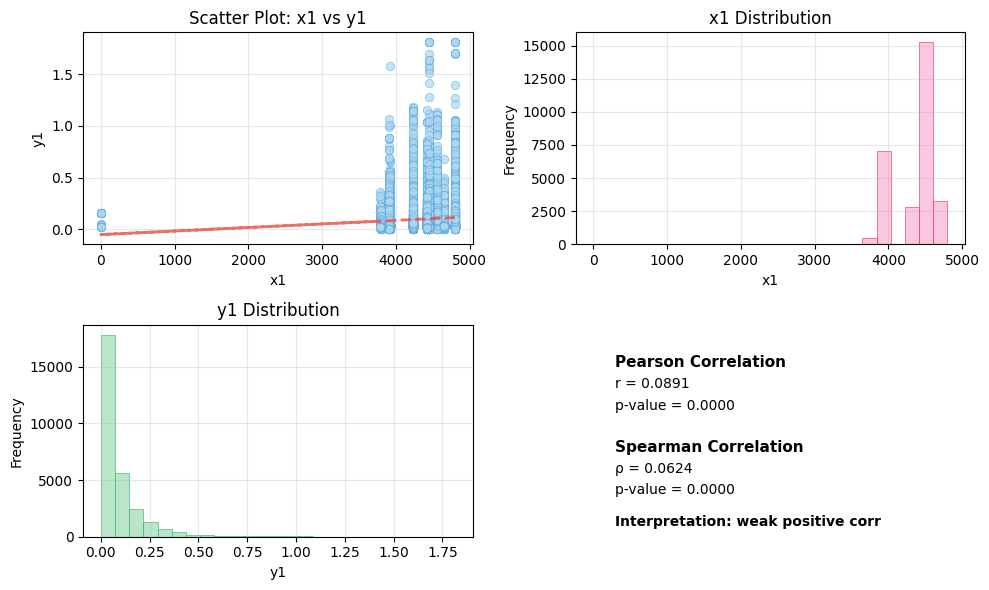


[2/9] 분석 중: x2

📊 연속형 변수 분석: x2 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.0151 (p-value: 0.0104)
   • Spearman 상관계수: 0.0194 (p-value: 0.0010)
   • Analysis: weak positive corr


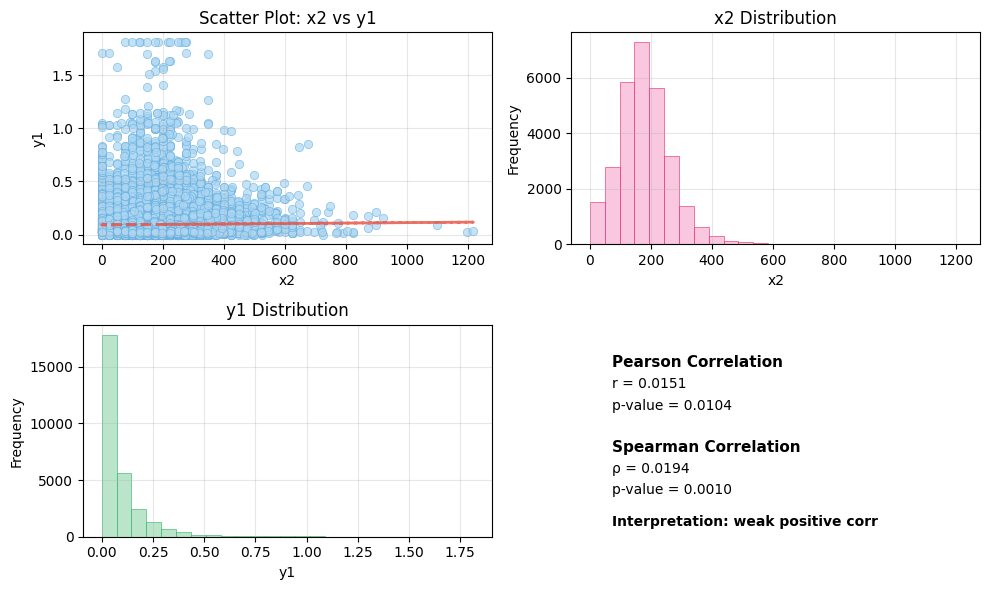


[3/9] 분석 중: x3

📊 연속형 변수 분석: x3 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.0044 (p-value: 0.4598)
   • Spearman 상관계수: 0.0375 (p-value: 0.0000)
   • Analysis: weak positive corr


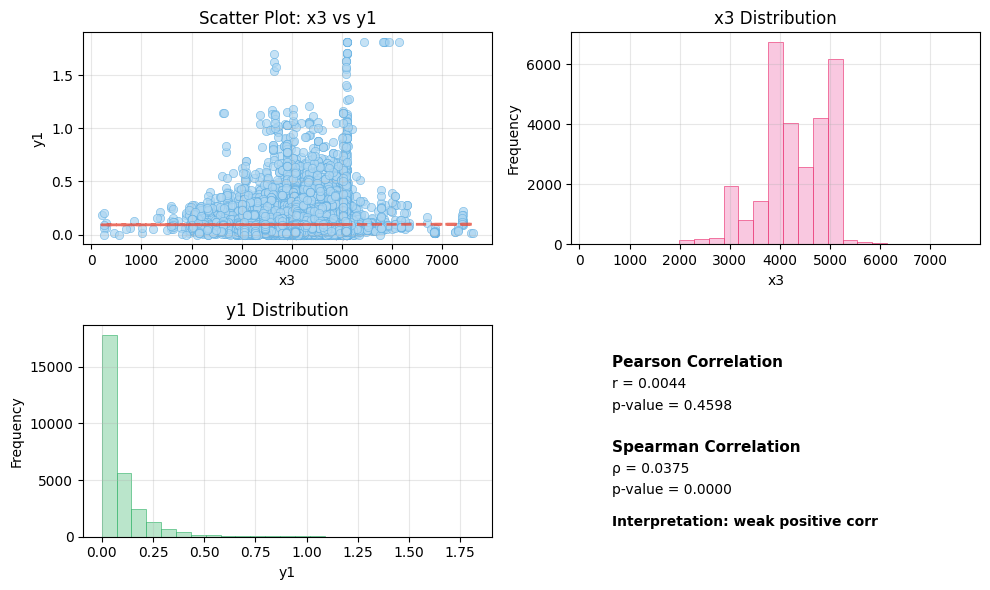


[4/9] 분석 중: x4

📊 연속형 변수 분석: x4 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.0579 (p-value: 0.0000)
   • Spearman 상관계수: 0.1016 (p-value: 0.0000)
   • Analysis: weak positive corr


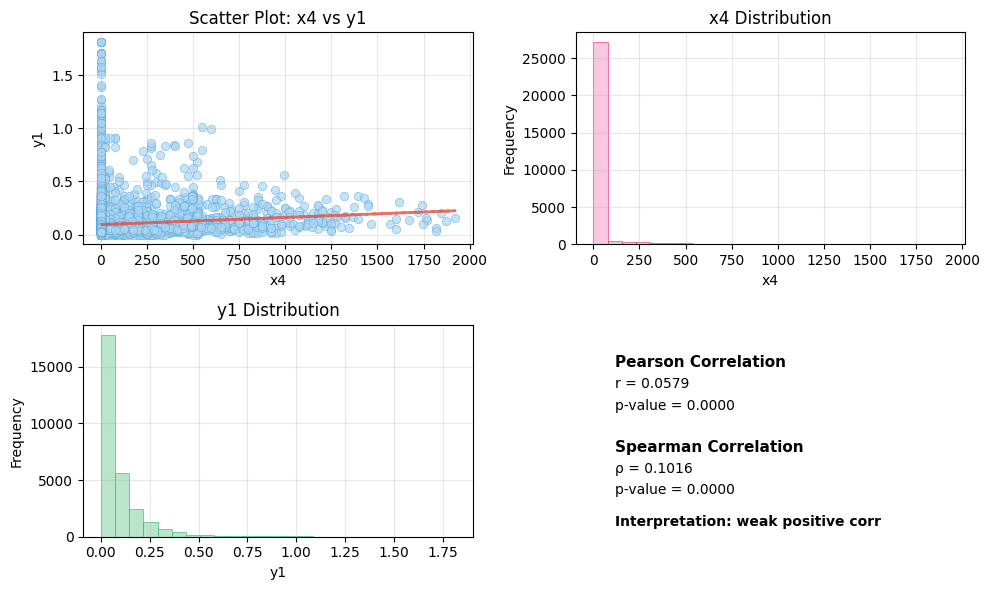


[5/9] 분석 중: x5

📊 연속형 변수 분석: x5 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.3216 (p-value: 0.0000)
   • Spearman 상관계수: 0.2973 (p-value: 0.0000)
   • Analysis: medium positive corr


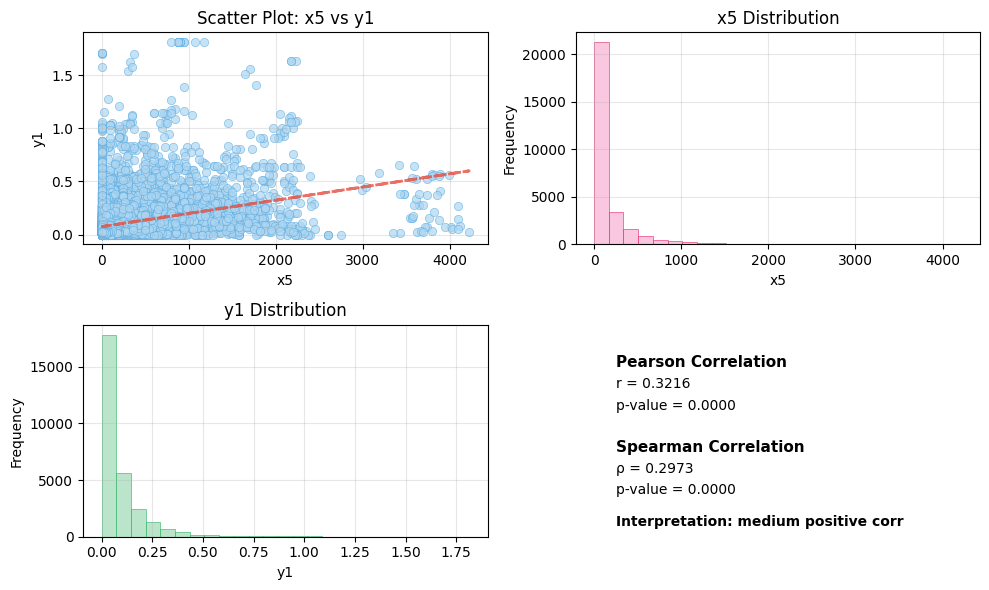


[6/9] 분석 중: x6

📊 연속형 변수 분석: x6 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.4838 (p-value: 0.0000)
   • Spearman 상관계수: 0.5634 (p-value: 0.0000)
   • Analysis: medium positive corr


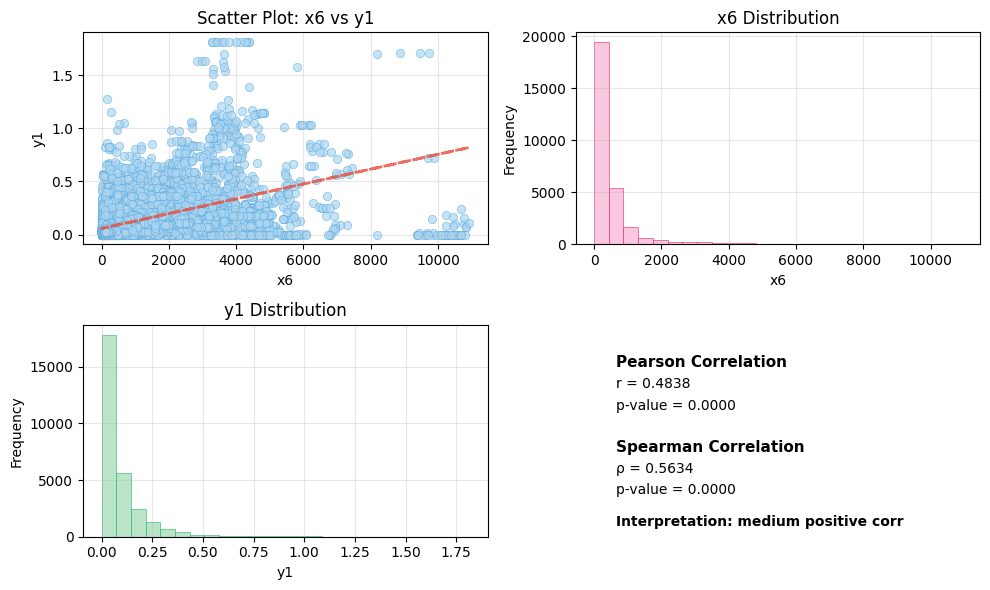


[7/9] 분석 중: x7

📊 연속형 변수 분석: x7 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.1060 (p-value: 0.0000)
   • Spearman 상관계수: 0.1487 (p-value: 0.0000)
   • Analysis: weak positive corr


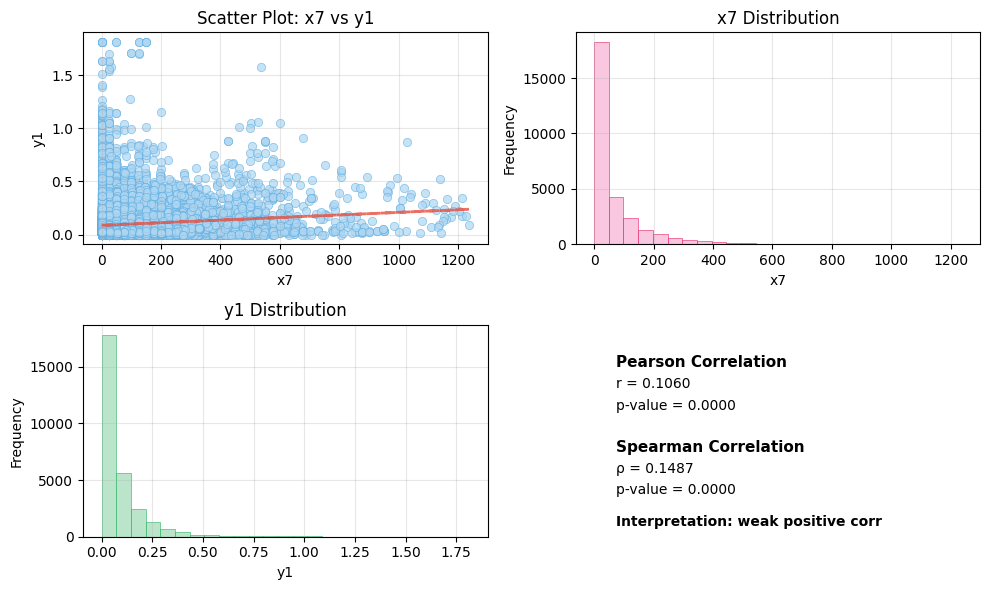


[8/9] 분석 중: x8

📊 연속형 변수 분석: x8 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: -0.0230 (p-value: 0.0001)
   • Spearman 상관계수: -0.0854 (p-value: 0.0000)
   • Analysis: weak negative corr


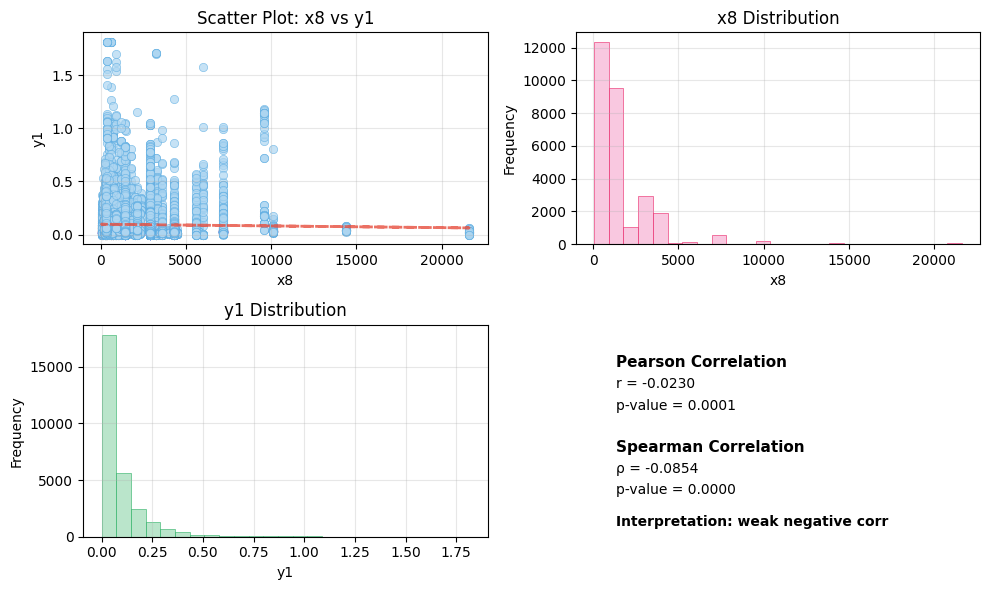


[9/9] 분석 중: x9

📊 연속형 변수 분석: x9 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 상관분석 결과:
   • Pearson 상관계수: 0.2469 (p-value: 0.0000)
   • Spearman 상관계수: 0.1856 (p-value: 0.0000)
   • Analysis: weak positive corr


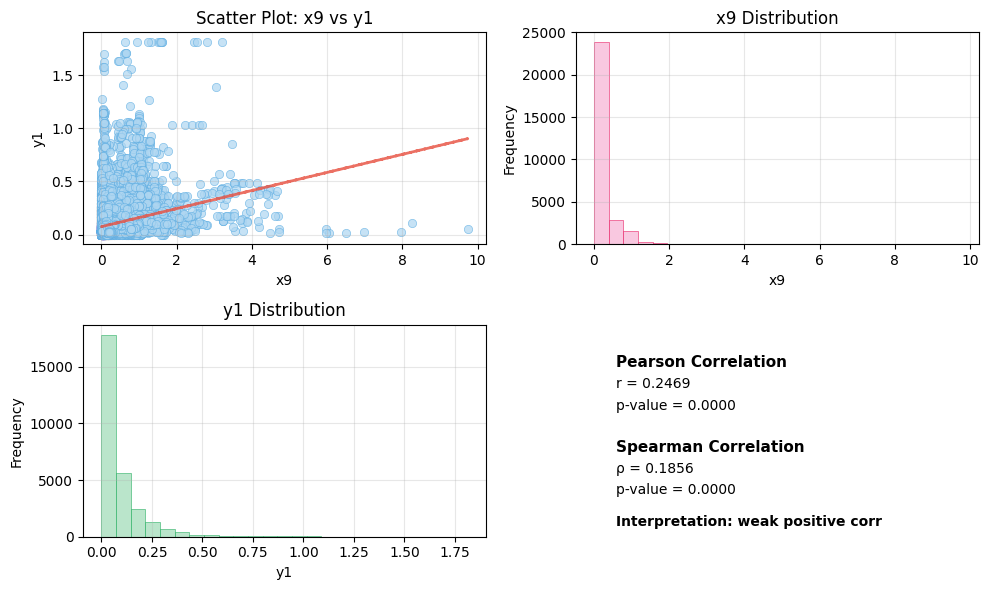


📈 범주형 변수 분석 (7개 변수)

[1/7] 분석 중: lot_cd

📊 범주형 변수 분석: lot_cd vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)

📊 범주별 기술통계:
          count    mean     std  min     max
lot_cd                                      
lot_cd_1  28812  0.0951  0.1277  0.0  1.8139


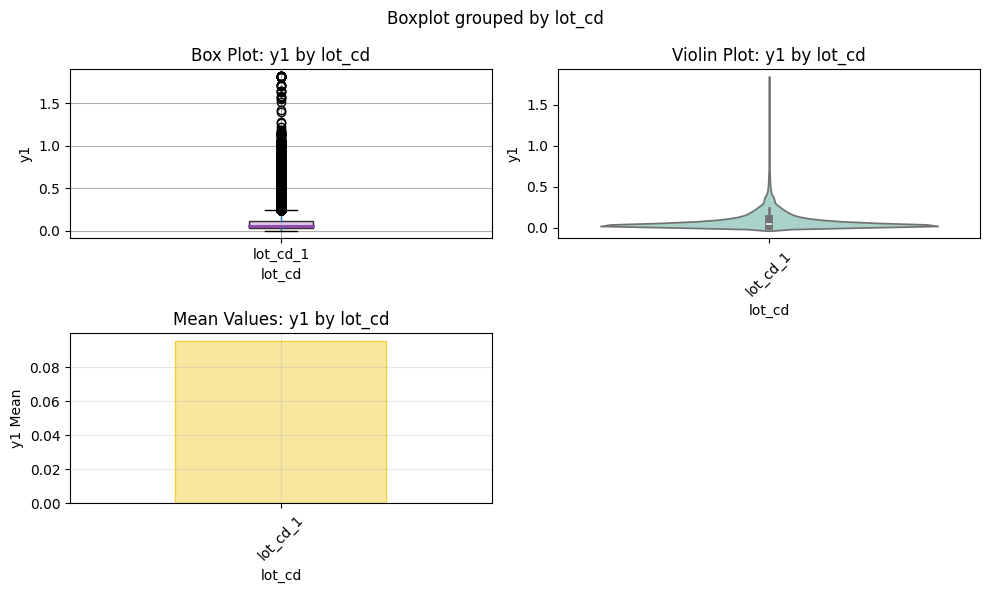


[2/7] 분석 중: hbm_type

📊 범주형 변수 분석: hbm_type vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)

📊 범주별 기술통계:
          count    mean     std  min     max
hbm_type                                    
type_1    28812  0.0951  0.1277  0.0  1.8139


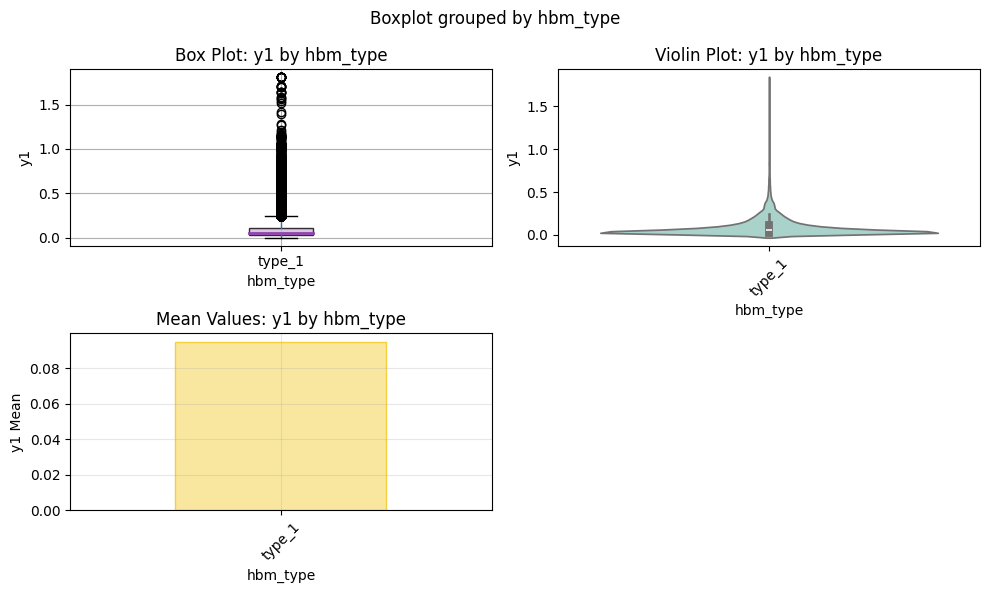


[3/7] 분석 중: stack_type

📊 범주형 변수 분석: stack_type vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)

📊 범주별 기술통계:
            count    mean     std  min     max
stack_type                                    
stack_1     28812  0.0951  0.1277  0.0  1.8139


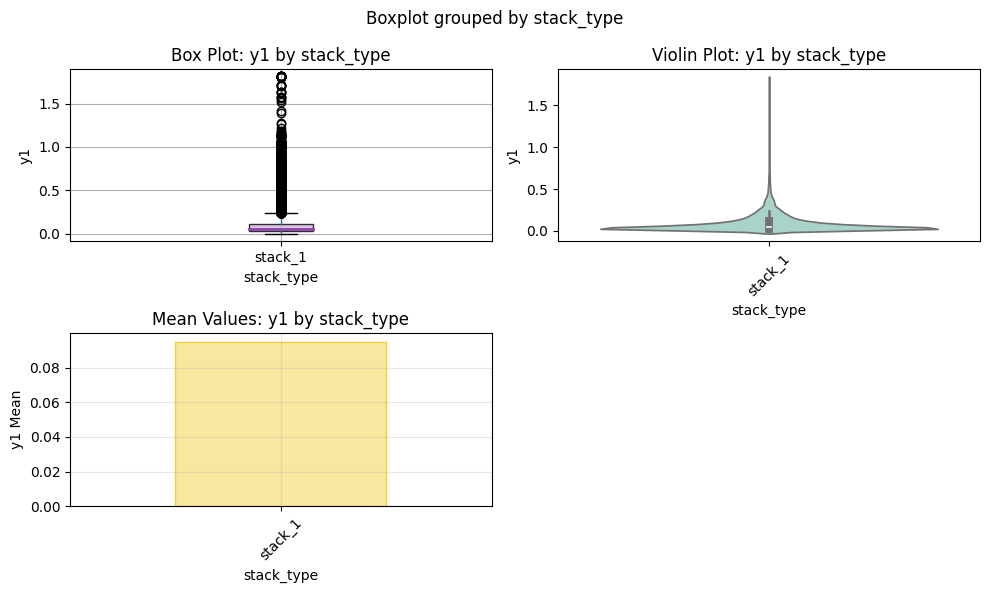


[4/7] 분석 중: oper

📊 범주형 변수 분석: oper vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 일원분산분석 (One-way ANOVA) 결과:
   • F-통계량: 44.1601
   • p-value: 0.0000
   • 해석: 집단 간 평균에 유의한 차이가 있습니다 (p < 0.05)

📊 범주별 기술통계:
          count    mean     std     min     max
oper                                           
oper_1       49  0.0391  0.0244  0.0188  0.1365
oper_10      49  0.0989  0.0600  0.0139  0.3190
oper_100     49  0.1522  0.0540  0.0582  0.2592
oper_101     49  0.1470  0.0968  0.0181  0.3773
oper_102     49  0.0301  0.0193  0.0117  0.1279
...         ...     ...     ...     ...     ...
oper_95      49  0.0375  0.0077  0.0193  0.0546
oper_96      49  0.1019  0.0456  0.0552  0.2989
oper_97      49  0.0188  0.0149  0.0000  0.0729
oper_98      49  0.0230  0.0093  0.0096  0.0569
oper_99      49  0.0472  0.0247  0.0230  0.1424

[588 rows x 5 columns]


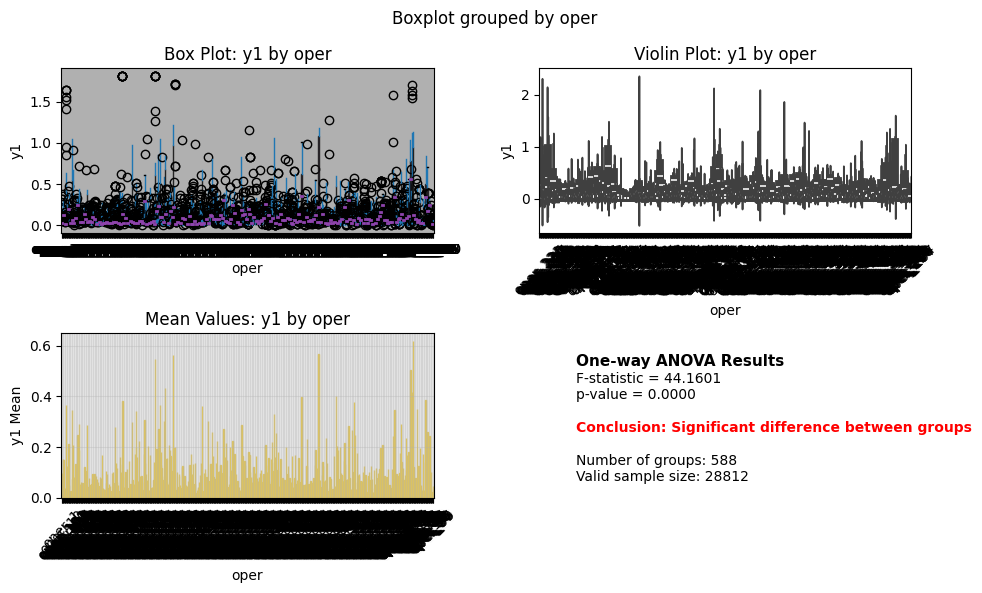


[5/7] 분석 중: area

📊 범주형 변수 분석: area vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 일원분산분석 (One-way ANOVA) 결과:
   • F-통계량: 370.8683
   • p-value: 0.0000
   • 해석: 집단 간 평균에 유의한 차이가 있습니다 (p < 0.05)

📊 범주별 기술통계:
        count    mean     std  min     max
area                                      
area_1  10780  0.0585  0.0932  0.0  1.8139
area_2    833  0.0878  0.0857  0.0  0.5080
area_3   2450  0.0654  0.0948  0.0  1.2774
area_4   3577  0.1638  0.1353  0.0  1.0484
area_5   5145  0.1111  0.1631  0.0  1.8096
area_6   2401  0.1079  0.0805  0.0  0.8248
area_7   3087  0.1283  0.1642  0.0  1.7115
area_8    539  0.1152  0.1229  0.0  0.8326


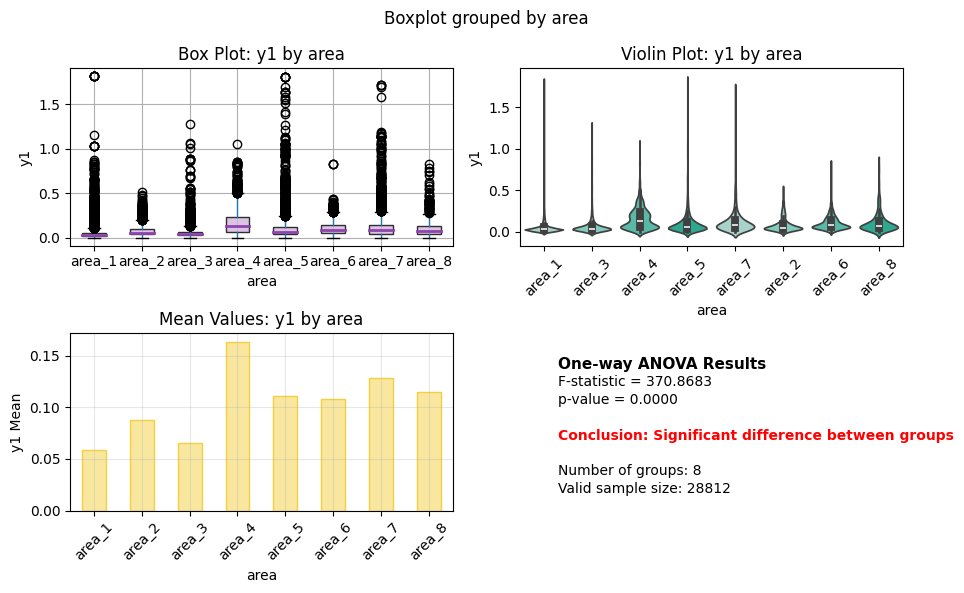


[6/7] 분석 중: group

📊 범주형 변수 분석: group vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)
📈 일원분산분석 (One-way ANOVA) 결과:
   • F-통계량: 78.7421
   • p-value: 0.0000
   • 해석: 집단 간 평균에 유의한 차이가 있습니다 (p < 0.05)

📊 범주별 기술통계:
           count    mean     std     min     max
group                                           
group_1      245  0.0427  0.0768  0.0000  1.0531
group_10     147  0.0529  0.0398  0.0134  0.2711
group_100     49  0.0625  0.0294  0.0001  0.1738
group_101    245  0.0317  0.0185  0.0000  0.1199
group_102     49  0.0704  0.0440  0.0372  0.3249
...          ...     ...     ...     ...     ...
group_95      49  0.1497  0.0538  0.0531  0.2599
group_96     490  0.0420  0.0316  0.0000  0.3397
group_97      98  0.1667  0.1291  0.0000  0.5578
group_98     343  0.0443  0.0507  0.0000  0.3754
group_99     245  0.0766  0.0729  0.0000  0.5054

[184 rows x 5 columns]


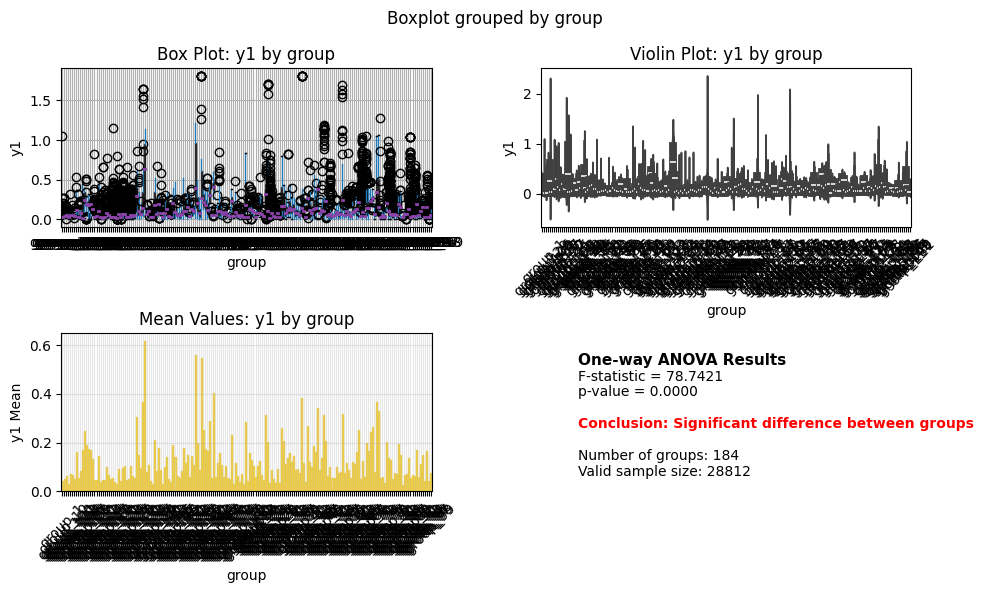


[7/7] 분석 중: x10

📊 범주형 변수 분석: x10 vs y1
📊 결측치 처리 결과: 28812 → 28812 (유효 데이터)

📊 범주별 기술통계:
     count    mean     std  min     max
x10                                    
Y    28812  0.0951  0.1277  0.0  1.8139


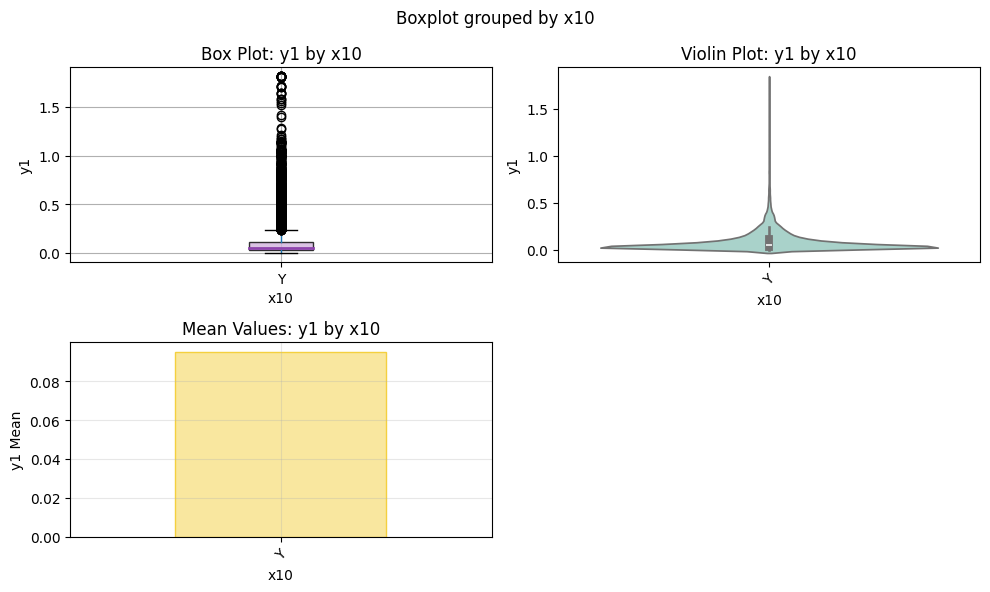

In [33]:
# 1) 수치형 변수 분석
if numeric_features:
    print(f"\n📊 수치형 변수 분석 ({len(numeric_features)}개 변수)")
    for i, var in enumerate(numeric_features, 1):
        print(f"\n[{i}/{len(numeric_features)}] 분석 중: {var}")
        analyze_continuous_relationship(df, var, target_col)

# 2) 범주형 변수 분석
if categorical_features:
    print(f"\n📈 범주형 변수 분석 ({len(categorical_features)}개 변수)")
    for i, var in enumerate(categorical_features, 1):
        print(f"\n[{i}/{len(categorical_features)}] 분석 중: {var}")
        analyze_categorical_relationship(df, var, target_col)

### 4.3 모든 설명변수 (X)와 종속변수(Y)의 관계 분석

In [34]:
# =============================================================================
# 1. 다중회귀분석 수행
# =============================================================================

# 범주형 변수 처리 함수
def encode_categorical_variables(df, target_col, encoding_method='onehot'):
    df_processed = df.copy()
    feature_cols = [c for c in df.columns if c != target_col]

    # 범주형 변수 식별
    categorical_features = []
    numerical_features = []

    for col in feature_cols:
        if df[col].dtype.name in ['object', 'category']:
            categorical_features.append(col)
        else:
            numerical_features.append(col)

    print(f"범주형 변수: {categorical_features}")
    print(f"수치형 변수: {numerical_features}\n")

    # 범주형 변수 인코딩
    if categorical_features:
        if encoding_method == 'onehot':
            # One-Hot Encoding
            print("One-Hot Encoding 적용...")
            encoder = OneHotEncoder(sparse_output=False, drop='first')

            # 범주형 변수 변환
            encoded_features = encoder.fit_transform(df[categorical_features])

            # 새로운 컬럼명 생성
            feature_names = []
            for i, col in enumerate(categorical_features):
                categories = encoder.categories_[i][1:]  # drop='first'이므로 첫 번째 제외
                for cat in categories:
                    feature_names.append(f"{col}_{cat}")

            # 인코딩된 데이터프레임 생성
            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)

            # 수치형 변수와 결합
            df_processed = pd.concat([df[numerical_features], encoded_df, df[target_col]], axis=1)

        elif encoding_method == 'label':
            # Label Encoding
            print("Label Encoding 적용...")
            label_encoders = {}

            for col in categorical_features:
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df[col])
                label_encoders[col] = le
                print(f"  {col}: {list(le.classes_)}")

    return df_processed

# train, val, test 분리
def train_val_test_split(X, y=None, *, train_size=0.6, val_size=0.2, test_size=0.2,
                         stratify=None, shuffle=True, random_state=None):

    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train + val + test = 1 이어야 합니다.")

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(val_size + test_size), stratify=stratify,
        shuffle=shuffle, random_state=random_state
    )
    rel_test_size = test_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=rel_test_size, stratify=stratify if stratify is None else y_tmp,
        shuffle=shuffle, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# 범주형 변수 처리
df_processed = encode_categorical_variables(df, target_col, 'label')

# 결측치 처리(앞의 행 값으로 대치
df_processed = df_processed.fillna(method='ffill')

# x, y 설정
target_col = df_processed.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]

X = df_processed[feature_cols].copy()
y = df_processed[target_col].copy()

# 범주형 타깃이면 stratify 사용
strat_option = y if y.dtype.name in ['object', 'category'] else None

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y, train_size=0.6, val_size=0.2, test_size=0.2,
    stratify=strat_option, random_state=42, shuffle=False
)

# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 훈련
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 예측
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 모델 성능 평가
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 결과 출력
print(f"\n 📈 모델 성능:")
print(f"   - 훈련 R2 = {train_r2:.4f}")
print(f"   - 테스트 R2 = {test_r2:.4f}")
print(f"   - 훈련 MSE = {train_mse:.4f}")
print(f"   - 테스트 MSE = {test_mse:.4f}")

# 과적합 여부 확인
overfitting = train_r2 - test_r2
print(f"   - 과적합 정도 = {overfitting:.4f}")

if overfitting > 0.1:
  print(f"   ⚠️  과적합 위험 (차이 > 0.1)")
else:
  print(f"   ✅ 적절한 모델 (차이 ≤ 0.1)")

# 변수 중요도 분석
feature_importance = pd.DataFrame({
  'feature': X.columns,
  'coefficient': model.coef_,
  'abs_coefficient': np.abs(model.coef_)
  }).sort_values('abs_coefficient', ascending=False)

print(f"\n📊 변수 중요도 (상위 10개):")
print(feature_importance.head(10)[['feature', 'coefficient']].to_string(index=False))

# 결과 딕셔너리 생성
results = {
  'model': model,
  'scaler': scaler,
  'train_r2': train_r2,
  'test_r2': test_r2,
  'train_mse': train_mse,
  'test_mse': test_mse,
  'feature_importance': feature_importance,
  'X_train': X_train,
  'X_test': X_test,
  'y_train': y_train,
  'y_test': y_test,
  'y_train_pred': y_train_pred,
  'y_test_pred': y_test_pred
  }

범주형 변수: ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']
수치형 변수: ['timekey_hr', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

Label Encoding 적용...
  lot_cd: ['lot_cd_1']
  hbm_type: ['type_1']
  stack_type: ['stack_1']
  oper: ['oper_1', 'oper_10', 'oper_100', 'oper_101', 'oper_102', 'oper_103', 'oper_104', 'oper_105', 'oper_106', 'oper_107', 'oper_108', 'oper_109', 'oper_11', 'oper_110', 'oper_111', 'oper_112', 'oper_113', 'oper_114', 'oper_115', 'oper_116', 'oper_117', 'oper_118', 'oper_119', 'oper_12', 'oper_120', 'oper_121', 'oper_122', 'oper_123', 'oper_124', 'oper_125', 'oper_126', 'oper_127', 'oper_128', 'oper_129', 'oper_13', 'oper_130', 'oper_131', 'oper_132', 'oper_133', 'oper_134', 'oper_135', 'oper_136', 'oper_137', 'oper_138', 'oper_139', 'oper_14', 'oper_140', 'oper_141', 'oper_142', 'oper_143', 'oper_144', 'oper_145', 'oper_146', 'oper_147', 'oper_148', 'oper_149', 'oper_15', 'oper_150', 'oper_151', 'oper_152', 'oper_153', 'oper_154', 'oper_1

In [35]:
# =============================================================================
# 2. 결과 시각화
# =============================================================================

def visualize_regression_results(results, figsize=(12, 8)):
    """
    다중회귀분석 결과 시각화

    Parameters:
    - results: 분석 결과 딕셔너리
    - figsize: 그래프 크기
    """

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    # 1) Actual vs. Predicted (Train Data)
    axes[0, 0].scatter(results['y_train'], results['y_train_pred'], alpha=0.6, color='skyblue')
    axes[0, 0].plot([results['y_train'].min(), results['y_train'].max()],
                    [results['y_train'].min(), results['y_train'].max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Value')
    axes[0, 0].set_ylabel('Predicted Value')
    axes[0, 0].set_title(f'Train Data: Actual vs. Predicted (R2 = {results["train_r2"]:.4f})')
    axes[0, 0].grid(True, alpha=0.3)

    # 2) Actual vs. Predicted (Test Data)
    axes[0, 1].scatter(results['y_test'], results['y_test_pred'], alpha=0.6, color='orange')
    axes[0, 1].plot([results['y_test'].min(), results['y_test'].max()],
                    [results['y_test'].min(), results['y_test'].max()], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Value')
    axes[0, 1].set_ylabel('Predicted Value')
    axes[0, 1].set_title(f'Test Data: Actual vs. Predicted (R2 = {results["test_r2"]:.4f})')
    axes[0, 1].grid(True, alpha=0.3)

    # 3) Residual Analysis (Train Data)
    train_residuals = results['y_train'] - results['y_train_pred']
    axes[0, 2].scatter(results['y_train_pred'], train_residuals, alpha=0.6, color='lightgreen')
    axes[0, 2].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 2].set_xlabel('Predicted Value')
    axes[0, 2].set_ylabel('Residuals')
    axes[0, 2].set_title('Train Data: Residual Analysis')
    axes[0, 2].grid(True, alpha=0.3)

    # 4) Residual Analysis (Test Data)
    test_residuals = results['y_test'] - results['y_test_pred']
    axes[1, 0].scatter(results['y_test_pred'], test_residuals, alpha=0.6, color='coral')
    axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Predicted Value')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].set_title('Test Data: Residual Analysis')
    axes[1, 0].grid(True, alpha=0.3)

    # 5) Feature Importance (Top 15)
    top_features = results['feature_importance'].head(15)
    colors = ['red' if coef < 0 else 'blue' for coef in top_features['coefficient']]
    axes[1, 1].barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
    axes[1, 1].set_yticks(range(len(top_features)))
    axes[1, 1].set_yticklabels(top_features['feature'], fontsize=10)
    axes[1, 1].set_xlabel('Coefficient')
    axes[1, 1].set_title('Feature Importance (Top 15)')
    axes[1, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 1].grid(True, alpha=0.3)

    # 6) Model Performance Summary
    axes[1, 2].text(0.1, 0.9, 'Model Performance Summary', fontsize=14, fontweight='bold')
    axes[1, 2].text(0.1, 0.8, f'   - Train R2 = {results["train_r2"]:.4f}', fontsize=12)
    axes[1, 2].text(0.1, 0.7, f'   - Test R2 = {results["test_r2"]:.4f}', fontsize=12)
    axes[1, 2].text(0.1, 0.6, f'   - Train MSE = {results["train_mse"]:.4f}', fontsize=12)
    axes[1, 2].text(0.1, 0.5, f'   - Test MSE = {results["test_mse"]:.4f}', fontsize=12)

    # Overfitting Analysis
    overfitting = results['train_r2'] - results['test_r2']
    axes[1, 2].text(0.1, 0.4, f'   - Overfitting = {overfitting:.4f}', fontsize=12)

    if overfitting > 0.1:
        axes[1, 2].text(0.1, 0.3, 'Overfitting Risk', fontsize=12, color='red', fontweight='bold')
    else:
        axes[1, 2].text(0.1, 0.3, 'Good Fit', fontsize=12, color='green', fontweight='bold')

    # Additional Information
    axes[1, 2].text(0.1, 0.2, f'   - Num. of Features = {len(results["feature_importance"])}', fontsize=11)
    axes[1, 2].text(0.1, 0.1, f'   - Sample Size = {len(results["y_train"]) + len(results["y_test"])}', fontsize=11)

    axes[1, 2].set_xlim(0, 1)
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # 결과 요약 출력
    print(f"\n 📊 시각화 결과 요약:")
    print(f"   - 실제값 vs 예측값: 대각선에 가까울수록 좋은 예측")
    print(f"   - 잔차 분석: 0 주변에 무작위로 분포되어야 함")
    print(f"   - 변수 중요도: 파란색(양의 영향), 빨간색(음의 영향)")

    if overfitting > 0.1:
        print(f"   ⚠️  모델 개선 필요: 과적합 위험")
    else:
        print(f"   ✅ 모델 상태 양호: 적절한 성능")

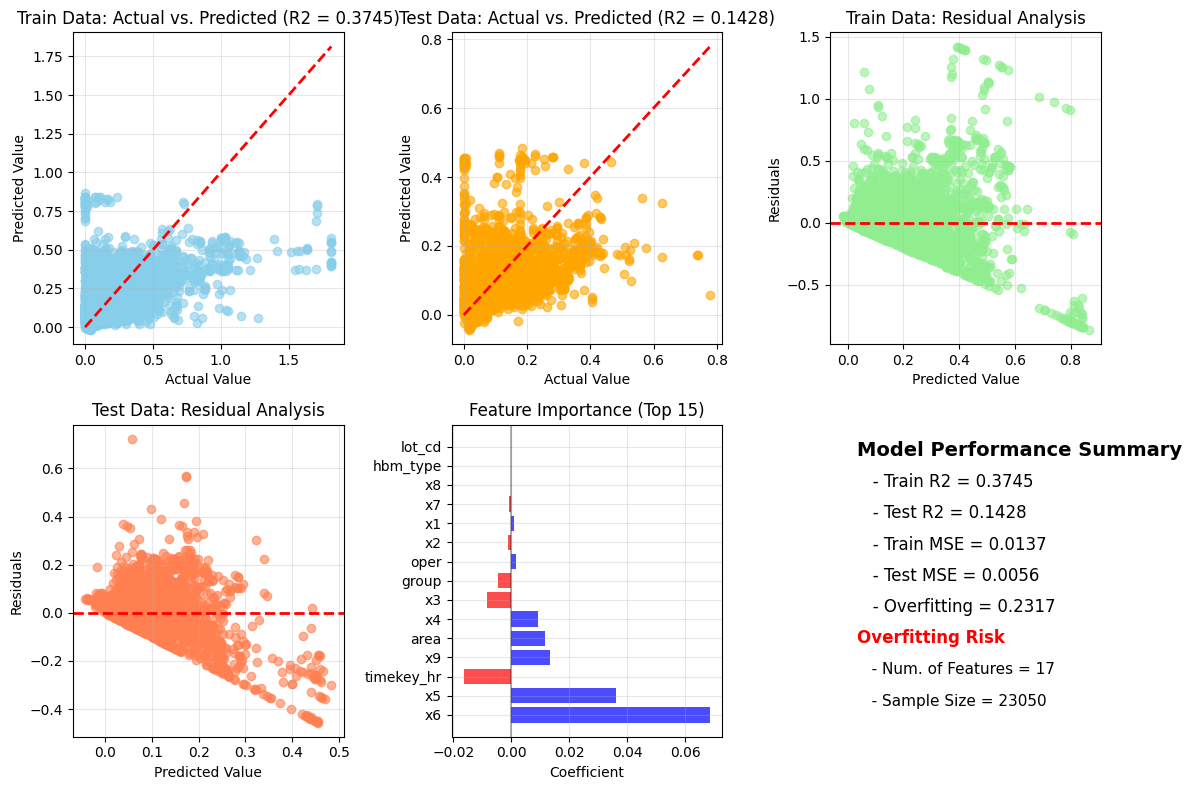


 📊 시각화 결과 요약:
   - 실제값 vs 예측값: 대각선에 가까울수록 좋은 예측
   - 잔차 분석: 0 주변에 무작위로 분포되어야 함
   - 변수 중요도: 파란색(양의 영향), 빨간색(음의 영향)
   ⚠️  모델 개선 필요: 과적합 위험

📈 주요 결과:
   - 모델 설명력(R²): 훈련 0.3745 / 테스트 0.1428
   - 가장 중요한 변수: x6
   - 변수 중요도 상위 3개:
      1. x6: 0.0685
      2. x5: 0.0361
      3. timekey_hr: -0.0164


In [36]:
# =============================================================================
# 3. 시각화 실행
# =============================================================================

# 시각화 실행
visualize_regression_results(results)

print(f"\n{'='*60}")
print(f"📈 주요 결과:")
print(f"   - 모델 설명력(R²): 훈련 {results['train_r2']:.4f} / 테스트 {results['test_r2']:.4f}")
print(f"   - 가장 중요한 변수: {results['feature_importance'].iloc[0]['feature']}")
print(f"   - 변수 중요도 상위 3개:")

# 상위 3개 변수 출력
for i in range(min(3, len(results['feature_importance']))):
    feature_name = results['feature_importance'].iloc[i]['feature']
    coefficient = results['feature_importance'].iloc[i]['coefficient']
    print(f"      {i+1}. {feature_name}: {coefficient:.4f}")

print(f"{'='*60}")


## 🔍 5. 변수 선택 기법

### 5.0 변수 선택 기법 세팅

In [37]:
# ================================
# 5.0 변수 선택 기법 세팅
# ================================

# 범주형 변수 처리 함수
def encode_categorical_variables(df, target_col, encoding_method='onehot'):
    df_processed = df.copy()
    feature_cols = [c for c in df.columns if c != target_col]

    # 범주형 변수 식별
    categorical_features = []
    numerical_features = []

    for col in feature_cols:
        if df[col].dtype.name in ['object', 'category']:
            categorical_features.append(col)
        else:
            numerical_features.append(col)

    print(f"범주형 변수: {categorical_features}")
    print(f"수치형 변수: {numerical_features}\n")

    # 범주형 변수 인코딩
    if categorical_features:
        if encoding_method == 'onehot':
            # One-Hot Encoding
            print("One-Hot Encoding 적용...")
            encoder = OneHotEncoder(sparse_output=False, drop='first')

            # 범주형 변수 변환
            encoded_features = encoder.fit_transform(df[categorical_features])

            # 새로운 컬럼명 생성
            feature_names = []
            for i, col in enumerate(categorical_features):
                categories = encoder.categories_[i][1:]  # drop='first'이므로 첫 번째 제외
                for cat in categories:
                    feature_names.append(f"{col}_{cat}")

            # 인코딩된 데이터프레임 생성
            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)

            # 수치형 변수와 결합
            df_processed = pd.concat([df[numerical_features], encoded_df, df[target_col]], axis=1)

        elif encoding_method == 'label':
            # Label Encoding
            print("Label Encoding 적용...")
            label_encoders = {}

            for col in categorical_features:
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df[col])
                label_encoders[col] = le
                print(f"  {col}: {list(le.classes_)}")

    return df_processed

# train, val, test 분리
def train_val_test_split(X, y=None, *, train_size=0.6, val_size=0.2, test_size=0.2,
                         stratify=None, shuffle=True, random_state=None):

    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train + val + test = 1 이어야 합니다.")

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(val_size + test_size), stratify=stratify,
        shuffle=shuffle, random_state=random_state
    )
    rel_test_size = test_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=rel_test_size, stratify=stratify if stratify is None else y_tmp,
        shuffle=shuffle, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# 성능 평가 함수
def evaluate_model(X_train, y_train, X_val, y_val, X_test, y_test, selected_features=None):
    """모델 성능 평가 (validation 기반)"""
    if selected_features is not None:
        X_train_selected = X_train[:, selected_features]
        X_val_selected = X_val[:, selected_features]
        X_test_selected = X_test[:, selected_features]
    else:
        X_train_selected = X_train
        X_val_selected = X_val
        X_test_selected = X_test

    model = LinearRegression()
    model.fit(X_train_selected, y_train)

    # Validation 성능 (특징 선택 기준)
    y_val_pred = model.predict(X_val_selected)
    val_r2 = r2_score(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    # Test 성능 (최종 평가용)
    y_test_pred = model.predict(X_test_selected)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    return val_r2, val_mse, test_r2, test_mse, model


# 범주형 변수 처리
df_processed = encode_categorical_variables(df, target_col, 'label')

# 결측치 처리(앞의 행 값으로 대치
df_processed = df_processed.fillna(method='ffill')

# x, y 설정
target_col = df_processed.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]

X = df_processed[feature_cols].copy()
y = df_processed[target_col].copy()

# 범주형 타깃이면 stratify 사용
strat_option = y if y.dtype.name in ['object', 'category'] else None

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y, train_size=0.6, val_size=0.2, test_size=0.2,
    stratify=strat_option, random_state=42, shuffle=False
)

# ================================
# 수치형 변수만 스케일링 적용
# ================================

# 원본 데이터에서 범주형/수치형 변수 구분 (Label Encoding 전)
original_categorical = []
original_numerical = []

for col in feature_cols:
    if df[col].dtype.name in ['object', 'category']:
        original_categorical.append(col)
    else:
        original_numerical.append(col)

# 처리된 데이터에서 해당 변수들의 인덱스 찾기
numerical_indices = [X.columns.get_loc(col) for col in original_numerical if col in X.columns]
categorical_indices = [X.columns.get_loc(col) for col in original_categorical if col in X.columns]

# 수치형 변수만 스케일링
if numerical_indices:
    # 수치형 변수 추출
    X_train_numerical = X_train.iloc[:, numerical_indices]
    X_val_numerical = X_val.iloc[:, numerical_indices]
    X_test_numerical = X_test.iloc[:, numerical_indices]

    # 스케일링 적용
    scaler = StandardScaler()
    X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
    X_val_numerical_scaled = scaler.transform(X_val_numerical)
    X_test_numerical_scaled = scaler.transform(X_test_numerical)

# 범주형 변수 추출 (스케일링 없이)
if categorical_indices:
    X_train_categorical = X_train.iloc[:, categorical_indices].values
    X_val_categorical = X_val.iloc[:, categorical_indices].values
    X_test_categorical = X_test.iloc[:, categorical_indices].values

# 최종 데이터 결합
if numerical_indices and categorical_indices:
    # 둘 다 있는 경우
    X_train_scaled = np.hstack([X_train_numerical_scaled, X_train_categorical])
    X_val_scaled = np.hstack([X_val_numerical_scaled, X_val_categorical])
    X_test_scaled = np.hstack([X_test_numerical_scaled, X_test_categorical])
elif numerical_indices:
    # 수치형만 있는 경우
    X_train_scaled = X_train_numerical_scaled
    X_val_scaled = X_val_numerical_scaled
    X_test_scaled = X_test_numerical_scaled
elif categorical_indices:
    # 범주형만 있는 경우
    X_train_scaled = X_train_categorical
    X_val_scaled = X_val_categorical
    X_test_scaled = X_test_categorical

print(f"\n✅ 최종 데이터 형태: train:{X_train_scaled.shape}, val:{X_val_scaled.shape}, test:{X_test_scaled.shape}")

# 특징 이름 업데이트
final_feature_names = list(X.columns)
print(f"✅ 최종 특징 이름: {final_feature_names}")

# 전체 결과 저장용
all_results = {}

범주형 변수: ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']
수치형 변수: ['timekey_hr', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

Label Encoding 적용...
  lot_cd: ['lot_cd_1']
  hbm_type: ['type_1']
  stack_type: ['stack_1']
  oper: ['oper_1', 'oper_10', 'oper_100', 'oper_101', 'oper_102', 'oper_103', 'oper_104', 'oper_105', 'oper_106', 'oper_107', 'oper_108', 'oper_109', 'oper_11', 'oper_110', 'oper_111', 'oper_112', 'oper_113', 'oper_114', 'oper_115', 'oper_116', 'oper_117', 'oper_118', 'oper_119', 'oper_12', 'oper_120', 'oper_121', 'oper_122', 'oper_123', 'oper_124', 'oper_125', 'oper_126', 'oper_127', 'oper_128', 'oper_129', 'oper_13', 'oper_130', 'oper_131', 'oper_132', 'oper_133', 'oper_134', 'oper_135', 'oper_136', 'oper_137', 'oper_138', 'oper_139', 'oper_14', 'oper_140', 'oper_141', 'oper_142', 'oper_143', 'oper_144', 'oper_145', 'oper_146', 'oper_147', 'oper_148', 'oper_149', 'oper_15', 'oper_150', 'oper_151', 'oper_152', 'oper_153', 'oper_154', 'oper_1

In [38]:
# 변환 이후
X_train.head()

,timekey_hr,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,2025062507,0,0,0,136,0,33,4800.0,199,5100,0,0,75,0,2881.0,0.018,0
1,2025062508,0,0,0,136,0,33,4800.0,275,4282,0,0,25,0,2881.0,0.002,0
2,2025062509,0,0,0,136,0,33,4800.0,325,4080,0,0,75,0,2881.0,0.011,0
3,2025062510,0,0,0,136,0,33,4800.0,325,5100,0,25,100,50,2881.0,0.011,0
4,2025062511,0,0,0,136,0,33,4800.0,176,5100,0,25,0,0,2881.0,0.002,0


### 5.1 전역 탐색(Exhaustive Search)

In [39]:
# ================================
# 5.1 전역 탐색(Exhaustive Search)
# ================================

print("\n" + "="*80)
print("5.1 전역 탐색(Exhaustive Search)")
print("="*80)

# From Scratch 구현
def exhaustive_search_scratch(X_train, y_train, X_val, y_val, max_features=100):
    """전역 탐색 from scratch"""
    n_features = X_train.shape[1]
    max_features = min(max_features, n_features)

    best_score = -np.inf
    best_features = None
    all_combinations = []

    print(f"From Scratch - 최대 {max_features}개 특징까지 전역 탐색 수행...")

    for k in range(1, max_features + 1):
        print(f"  {k}개 특징 조합 탐색 중...")
        for features in combinations(range(n_features), k):
            val_r2, val_mse, test_r2, test_mse, model = evaluate_model(
                X_train, y_train, X_val, y_val, X_test_scaled, y_test, features
            )

            all_combinations.append({
                'features': features,
                'n_features': k,
                'val_r2': val_r2,
                'test_r2': test_r2,
                'feature_names': [final_feature_names[i] for i in features]
            })

            if val_r2 > best_score:
                best_score = val_r2
                best_features = features

    return best_features, best_score, all_combinations

# Library 구현
def exhaustive_search_library(X_train, y_train, X_val, y_val, max_features=6):
    print(f"Library - mlxtend를 사용한 전역 탐색...")

    model = LinearRegression()

    # Train + Validation 데이터 합치기
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.hstack([y_train, y_val])

    # Custom CV: Train으로 학습, Validation으로 평가
    train_indices = list(range(len(X_train)))
    val_indices = list(range(len(X_train), len(X_combined)))
    custom_cv = [(train_indices, val_indices)]

    efs = EFS(model,
              min_features=1,
              max_features=max_features,
              scoring='r2',
              cv=custom_cv)

    efs.fit(X_combined, y_combined)

    # 최적 특징 조합 찾기
    best_score = -np.inf
    best_features = None

    for features in efs.subsets_:
        selected_features = list(efs.subsets_[features]['feature_idx'])
        val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                           X_test_scaled, y_test, selected_features)
        if val_r2 > best_score:
            best_score = val_r2
            best_features = selected_features

    return best_features, best_score

# 실행
print("From Scratch 실행:")
best_features_scratch, best_score_scratch, _ = exhaustive_search_scratch(
    X_train_scaled, y_train, X_val_scaled, y_val, max_features=5
)

print("\nLibrary 실행:")
best_features_library, best_score_library = exhaustive_search_library(
    X_train_scaled, y_train, X_val_scaled, y_val, max_features=5
)

# 결과 저장
all_results['Exhaustive Search'] = {
    'scratch': {
        'features': best_features_scratch,
        'val_r2': best_score_scratch,
        'feature_names': [final_feature_names[i] for i in best_features_scratch]
    },
    'library': {
        'features': best_features_library,
        'val_r2': best_score_library,
        'feature_names': [final_feature_names[i] for i in best_features_library] if best_features_library else None
    }
}

print("\n")
print(f"[전역 탐색 결과 비교]")
print(f"From Scratch: {[final_feature_names[i] for i in best_features_scratch]}, Val R2 = {best_score_scratch:.4f}")
if best_features_library:
    print(f"Library:      {[final_feature_names[i] for i in best_features_library]}, Val R2 = {best_score_library:.4f}")



5.1 전역 탐색(Exhaustive Search)
From Scratch 실행:
From Scratch - 최대 5개 특징까지 전역 탐색 수행...
  1개 특징 조합 탐색 중...
  2개 특징 조합 탐색 중...
  3개 특징 조합 탐색 중...
  4개 특징 조합 탐색 중...
  5개 특징 조합 탐색 중...

Library 실행:
Library - mlxtend를 사용한 전역 탐색...


Features: 9401/9401



[전역 탐색 결과 비교]
From Scratch: ['timekey_hr', 'lot_cd', 'area', 'x3', 'x8'], Val R2 = 0.1263
Library:      ['timekey_hr', 'lot_cd', 'area', 'x3', 'x8'], Val R2 = 0.1263


### 5.2 전진 선택법(Forward Selection)

In [40]:
# ================================
# 5.2 전진 선택법(Forward Selection)
# ================================

print("\n" + "="*80)
print("5.2 전진 선택법(Forward Selection)")
print("="*80)

# From Scratch 구현
def forward_selection_scratch(X_train, y_train, X_val, y_val, max_features=8):
    """전진 선택법 from scratch"""
    n_features = X_train.shape[1]
    max_features = min(max_features, n_features)

    selected_features = []
    remaining_features = list(range(n_features))

    print("From Scratch - 전진 선택법 실행...")

    for step in range(max_features):
        best_score = -np.inf
        best_feature = None

        for feature in remaining_features:
            candidate_features = selected_features + [feature]
            val_r2, _, _, _, _ = evaluate_model(
                X_train, y_train, X_val, y_val, X_test_scaled, y_test, candidate_features
            )

            if val_r2 > best_score:
                best_score = val_r2
                best_feature = feature

        if best_feature is not None:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            print(f"  Step {step + 1}: 추가 {final_feature_names[best_feature]}, Val R2 = {best_score:.4f}")
        else:
            break

    return selected_features, best_score

# Library 구현
def forward_selection_library(X_train, y_train, X_val, y_val, max_features=8):
    """sklearn을 사용한 전진 선택법"""
    print("Library - sklearn을 사용한 전진 선택법...")

    model = LinearRegression()

    # Train + Validation 데이터 합치기
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.hstack([y_train, y_val])

    # Custom CV: Train으로 학습, Validation으로 평가
    train_indices = list(range(len(X_train)))
    val_indices = list(range(len(X_train), len(X_combined)))
    custom_cv = [(train_indices, val_indices)]

    sfs = SequentialFeatureSelector(
        model,
        n_features_to_select=max_features,
        direction='forward',
        scoring='r2',
        cv=custom_cv  # From Scratch와 동일한 평가 방식
    )

    sfs.fit(X_combined, y_combined)

    selected_features = list(sfs.get_support(indices=True))
    val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                       X_test_scaled, y_test, selected_features)

    return selected_features, val_r2

# 실행
print("From Scratch 실행:")
selected_features_scratch, val_r2_scratch = forward_selection_scratch(
    X_train_scaled, y_train, X_val_scaled, y_val, max_features=10
)

print("\nLibrary 실행:")
selected_features_library, val_r2_library = forward_selection_library(
    X_train_scaled, y_train, X_val_scaled, y_val, max_features=10
)

# 결과 저장
all_results['Forward Selection'] = {
    'scratch': {
        'features': selected_features_scratch,
        'val_r2': val_r2_scratch,
        'feature_names': [final_feature_names[i] for i in selected_features_scratch]
    },
    'library': {
        'features': selected_features_library,
        'val_r2': val_r2_library,
        'feature_names': [final_feature_names[i] for i in selected_features_library]
    }
}

print(f"\n[전진 선택법 결과 비교]")
print(f"From Scratch: {[final_feature_names[i] for i in selected_features_scratch]}, Val R2 = {val_r2_scratch:.4f}")
print(f"Library:      {[final_feature_names[i] for i in selected_features_library]}, Val R2 = {val_r2_library:.4f}")



5.2 전진 선택법(Forward Selection)
From Scratch 실행:
From Scratch - 전진 선택법 실행...
  Step 1: 추가 timekey_hr, Val R2 = 0.0072
  Step 2: 추가 x8, Val R2 = 0.0570
  Step 3: 추가 x3, Val R2 = 0.1083
  Step 4: 추가 area, Val R2 = 0.1191
  Step 5: 추가 lot_cd, Val R2 = 0.1263
  Step 6: 추가 stack_type, Val R2 = 0.1328
  Step 7: 추가 hbm_type, Val R2 = 0.1328
  Step 8: 추가 x4, Val R2 = 0.1328
  Step 9: 추가 x5, Val R2 = 0.1328
  Step 10: 추가 x6, Val R2 = 0.1328

Library 실행:
Library - sklearn을 사용한 전진 선택법...

[전진 선택법 결과 비교]
From Scratch: ['timekey_hr', 'x8', 'x3', 'area', 'lot_cd', 'stack_type', 'hbm_type', 'x4', 'x5', 'x6'], Val R2 = 0.1328
Library:      ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'area', 'x3', 'x4', 'x5', 'x8', 'x10'], Val R2 = 0.1328


### 5.3 후진 소거법(Backward Elimination)

In [41]:
# ================================
# 5.3 후진 소거법(Backward Elimination)
# ================================

print("\n" + "="*80)
print("5.3 후진 소거법(Backward Elimination)")
print("="*80)

# From Scratch 구현
def backward_elimination_scratch(X_train, y_train, X_val, y_val, min_features=1, min_r2_drop=0.01):
    """후진 소거법 from scratch"""
    n_features = X_train.shape[1]
    min_features = max(min_features, 1)

    selected_features = list(range(n_features))  # 모든 특성으로 시작

    print("From Scratch - 후진 소거법 실행...")

    # 초기 성능 계산
    initial_r2, _, _, _, _ = evaluate_model(
        X_train, y_train, X_val, y_val, X_test_scaled, y_test, selected_features
    )
    print(f"  초기 상태: 전체 {len(selected_features)}개 특성, R2 = {initial_r2:.4f}")

    # 최적 조합 추적
    best_r2 = initial_r2
    best_features = selected_features.copy()

    step = 0
    while len(selected_features) > min_features:
        step += 1

        # 현재 성능
        current_r2, _, _, _, _ = evaluate_model(
            X_train, y_train, X_val, y_val, X_test_scaled, y_test, selected_features
        )

        best_r2_after_removal = -np.inf
        best_feature_to_remove = None

        # 각 특성을 제거해보고 성능 확인
        for feature in selected_features:
            candidate_features = [f for f in selected_features if f != feature]

            if len(candidate_features) < min_features:
                continue

            val_r2, _, _, _, _ = evaluate_model(
                X_train, y_train, X_val, y_val, X_test_scaled, y_test, candidate_features
            )

            # 제거 후 R2가 가장 높은 특성 선택 (즉, 가장 영향이 적은 특성)
            if val_r2 > best_r2_after_removal:
                best_r2_after_removal = val_r2
                best_feature_to_remove = feature

        # R2 감소량 계산
        r2_drop = current_r2 - best_r2_after_removal

        # 허용 가능한 R2 감소량 이내인지 확인
        if r2_drop <= min_r2_drop and best_feature_to_remove is not None:
            selected_features.remove(best_feature_to_remove)
            print(f"  Step {step}: 제거 {final_feature_names[best_feature_to_remove]}, "
                  f"R2 감소: {r2_drop:.4f}, 제거 후 R2: {best_r2_after_removal:.4f}")

            # 최적 조합 업데이트
            if best_r2_after_removal > best_r2:
                best_r2 = best_r2_after_removal
                best_features = selected_features.copy()
                print(f"    → 새로운 최적 조합 발견! R2 = {best_r2:.4f}")
        else:
            print(f"  Step {step}: 중단 (R2 감소가 {min_r2_drop:.3f}를 초과하거나 더 이상 제거할 특성이 없음)")
            break

    print(f"  최종 선택: {len(best_features)}개 특성으로 최적 성능 달성")
    return best_features, best_r2

# Library 구현 수정
def backward_elimination_library(X_train, y_train, X_val, y_val, min_features=1, min_r2_drop=0.01):
    """sklearn을 사용한 후진 소거법"""
    print("Library - sklearn SequentialFeatureSelector를 사용한 후진 소거법...")

    model = LinearRegression()

    # Train + Validation 데이터 합치기
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.hstack([y_train, y_val])

    # Custom CV: Train으로 학습, Validation으로 평가
    train_indices = list(range(len(X_train)))
    val_indices = list(range(len(X_train), len(X_combined)))
    custom_cv = [(train_indices, val_indices)]

    # 최적 특성 개수를 찾기 위해 여러 개수를 시도
    best_r2 = -np.inf
    best_features = None
    best_n_features = None

    max_features = X_train.shape[1]

    # 전체 특성으로 시작 (SequentialFeatureSelector 제약 때문에 별도 처리)
    all_features = list(range(max_features))
    val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                       X_test_scaled, y_test, all_features)
    print(f"  {max_features}개 특성: Val R2 = {val_r2:.4f}")

    best_r2 = val_r2
    best_features = all_features
    best_n_features = max_features

    # max_features-1부터 시작 (sklearn 제약 때문)
    for n_features in range(max_features - 1, min_features - 1, -1):
        sfs = SequentialFeatureSelector(
            model,
            n_features_to_select=n_features,
            direction='backward',  # 후진 소거법
            scoring='r2',
            cv=custom_cv  # From Scratch와 동일한 평가 방식
        )

        sfs.fit(X_combined, y_combined)

        selected_features = list(sfs.get_support(indices=True))
        val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                           X_test_scaled, y_test, selected_features)

        print(f"  {n_features}개 특성: Val R2 = {val_r2:.4f}")

        if val_r2 > best_r2:
            best_r2 = val_r2
            best_features = selected_features
            best_n_features = n_features
        elif val_r2 < best_r2 - min_r2_drop:
            break

    print(f"  최적 특성 개수: {best_n_features}개")

    return best_features, best_r2

# 실행
print("From Scratch 실행:")
selected_features_scratch, val_r2_scratch = backward_elimination_scratch(
    X_train_scaled, y_train, X_val_scaled, y_val, min_features=5
)

print("\nLibrary 실행:")
selected_features_library, val_r2_library = backward_elimination_library(
    X_train_scaled, y_train, X_val_scaled, y_val, min_features=5
)

# 결과 저장
all_results['Backward Elimination'] = {
    'scratch': {
        'features': selected_features_scratch,
        'val_r2': val_r2_scratch,
        'feature_names': [final_feature_names[i] for i in selected_features_scratch]
    },
    'library': {
        'features': selected_features_library,
        'val_r2': val_r2_library,
        'feature_names': [final_feature_names[i] for i in selected_features_library]
    }
}

print(f"\n[후진 소거법 결과 비교]")
print(f"From Scratch: {[final_feature_names[i] for i in selected_features_scratch]}, Val R2 = {val_r2_scratch:.4f}")
print(f"Library:      {[final_feature_names[i] for i in selected_features_library]}, Val R2 = {val_r2_library:.4f}")



5.3 후진 소거법(Backward Elimination)
From Scratch 실행:
From Scratch - 후진 소거법 실행...
  초기 상태: 전체 17개 특성, R2 = -0.0394
  Step 1: 제거 group, R2 감소: -0.1272, 제거 후 R2: 0.0877
    → 새로운 최적 조합 발견! R2 = 0.0877
  Step 2: 제거 x1, R2 감소: -0.0251, 제거 후 R2: 0.1128
    → 새로운 최적 조합 발견! R2 = 0.1128
  Step 3: 제거 x9, R2 감소: -0.0136, 제거 후 R2: 0.1264
    → 새로운 최적 조합 발견! R2 = 0.1264
  Step 4: 제거 x2, R2 감소: -0.0051, 제거 후 R2: 0.1315
    → 새로운 최적 조합 발견! R2 = 0.1315
  Step 5: 제거 x7, R2 감소: -0.0009, 제거 후 R2: 0.1324
    → 새로운 최적 조합 발견! R2 = 0.1324
  Step 6: 제거 oper, R2 감소: -0.0004, 제거 후 R2: 0.1328
    → 새로운 최적 조합 발견! R2 = 0.1328
  Step 7: 제거 x4, R2 감소: 0.0000, 제거 후 R2: 0.1328
  Step 8: 제거 x5, R2 감소: -0.0000, 제거 후 R2: 0.1328
    → 새로운 최적 조합 발견! R2 = 0.1328
  Step 9: 제거 x6, R2 감소: -0.0000, 제거 후 R2: 0.1328
    → 새로운 최적 조합 발견! R2 = 0.1328
  Step 10: 제거 x10, R2 감소: 0.0000, 제거 후 R2: 0.1328
  Step 11: 제거 hbm_type, R2 감소: 0.0000, 제거 후 R2: 0.1328
  Step 12: 제거 stack_type, R2 감소: 0.0065, 제거 후 R2: 0.1263
  최종 선택: 8개 특성으로 최적 성능 달성

### 5.4 단계적 선택법(Stepwise Selection)

In [42]:
# ================================
# 5.4 단계적 선택법(Stepwise Selection)
# ================================

print("\n" + "="*80)
print("5.4 단계적 선택법(Stepwise Selection)")
print("="*80)

# From Scratch 구현
def stepwise_selection_scratch(X_train, y_train, X_val, y_val, max_features=8, min_r2_improvement=0.001):
    """단계적 선택법 from scratch - 성능 기반"""
    n_features = X_train.shape[1]
    max_features = min(max_features, n_features)

    selected_features = []
    remaining_features = list(range(n_features))

    print("From Scratch - 단계적 선택법 실행...")

    for step in range(max_features):
        changed = False

        # Forward step: 가장 성능을 개선하는 특성 추가
        if remaining_features:
            current_r2 = 0 if not selected_features else evaluate_model(
                X_train, y_train, X_val, y_val, X_test_scaled, y_test, selected_features
            )[0]

            best_improvement = min_r2_improvement
            best_feature_to_add = None

            for feature in remaining_features:
                candidate_features = selected_features + [feature]
                val_r2, _, _, _, _ = evaluate_model(
                    X_train, y_train, X_val, y_val, X_test_scaled, y_test, candidate_features
                )

                improvement = val_r2 - current_r2
                if improvement > best_improvement:
                    best_improvement = improvement
                    best_feature_to_add = feature

            if best_feature_to_add is not None:
                selected_features.append(best_feature_to_add)
                remaining_features.remove(best_feature_to_add)
                changed = True
                print(f"  Step {step + 1}: 추가 {final_feature_names[best_feature_to_add]}, "
                      f"R2 개선: {best_improvement:.4f}")

        # Backward step: 제거해도 성능이 크게 떨어지지 않는 특성 제거
        if len(selected_features) > 1:
            current_r2 = evaluate_model(
                X_train, y_train, X_val, y_val, X_test_scaled, y_test, selected_features
            )[0]

            best_r2_after_removal = -np.inf
            best_feature_to_remove = None

            for feature in selected_features:
                candidate_features = [f for f in selected_features if f != feature]
                val_r2, _, _, _, _ = evaluate_model(
                    X_train, y_train, X_val, y_val, X_test_scaled, y_test, candidate_features
                )

                # 제거 후 성능 감소가 가장 적은 특성 찾기
                if val_r2 > best_r2_after_removal:
                    best_r2_after_removal = val_r2
                    best_feature_to_remove = feature

            # 성능 감소가 미미하면 제거
            r2_drop = current_r2 - best_r2_after_removal
            if r2_drop <= min_r2_improvement and best_feature_to_remove is not None:
                selected_features.remove(best_feature_to_remove)
                remaining_features.append(best_feature_to_remove)
                changed = True
                print(f"  Step {step + 1}: 제거 {final_feature_names[best_feature_to_remove]}, "
                      f"R2 감소: {r2_drop:.4f}")

        if not changed:
            print(f"  Step {step + 1}: 중단 (더 이상 개선되지 않음)")
            break

    final_r2 = evaluate_model(X_train, y_train, X_val, y_val,
                             X_test_scaled, y_test, selected_features)[0]
    return selected_features, final_r2

# Library 구현 수정 - From Scratch와 동일한 중단 조건
def stepwise_selection_library(X_train, y_train, X_val, y_val, max_features=8, min_r2_improvement=0.001):
    """mlxtend를 사용한 단계적 선택법"""
    print("Library - mlxtend를 사용한 단계적 선택법...")

    model = LinearRegression()

    # Train + Validation 데이터 합치기
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.hstack([y_train, y_val])

    # Custom CV: Train으로 학습, Validation으로 평가
    train_indices = list(range(len(X_train)))
    val_indices = list(range(len(X_train), len(X_combined)))
    custom_cv = [(train_indices, val_indices)]

    print("\n  단계별 특성 선택 과정:")

    best_features = []
    best_r2 = 0.0
    previous_r2 = 0.0

    # 각 단계별로 SFS 실행하고 성능 개선 체크
    for k in range(1, max_features + 1):
        sfs = SFS(model,
                  k_features=k,
                  forward=True,
                  floating=True,  # stepwise selection (전진 + 후진)
                  scoring='r2',
                  cv=custom_cv)

        sfs.fit(X_combined, y_combined)

        current_features = list(sfs.k_feature_idx_)
        current_r2 = sfs.k_score_

        # 성능 개선량 계산
        r2_improvement = current_r2 - previous_r2

        # 단계별 변화 출력
        if k == 1:
            print(f"  Step {k}: 추가 {[final_feature_names[i] for i in current_features]} "
                  f"(R2 = {current_r2:.4f}, 개선: {r2_improvement:.4f})")
        else:
            # 이전 단계와 비교하여 추가/제거된 특성 계산
            previous_features = set(best_features)
            current_features_set = set(current_features)

            added_features = current_features_set - previous_features
            removed_features = previous_features - current_features_set

            step_info = f"  Step {k}: "

            if added_features:
                added_names = [final_feature_names[i] for i in added_features]
                step_info += f"추가 {added_names} "

            if removed_features:
                removed_names = [final_feature_names[i] for i in removed_features]
                step_info += f"제거 {removed_names} "

            step_info += f"(R2 = {current_r2:.4f}, 개선: {r2_improvement:.4f})"
            print(step_info)

        # 성능 개선이 기준 이하이면 중단
        if r2_improvement <= min_r2_improvement:
            print(f"  Step {k}: 중단 (R2 개선량 {r2_improvement:.4f}이 기준 {min_r2_improvement:.3f} 이하)")
            break

        # 최적 결과 업데이트
        best_features = current_features
        best_r2 = current_r2
        previous_r2 = current_r2

    # 최종 validation 성능 계산
    val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                       X_test_scaled, y_test, best_features)

    print(f"\n  최종 선택된 특성: {[final_feature_names[i] for i in best_features]}")
    print(f"  최종 Validation R2: {val_r2:.4f}")

    return best_features, val_r2

# 실행
print("From Scratch 실행:")
selected_features_scratch, val_r2_scratch = stepwise_selection_scratch(
    X_train_scaled, y_train, X_val_scaled, y_val
)

print("\nLibrary 실행:")
selected_features_library, val_r2_library = stepwise_selection_library(
    X_train_scaled, y_train, X_val_scaled, y_val
)

# 결과 저장
all_results['Stepwise Selection'] = {
    'scratch': {
        'features': selected_features_scratch,
        'val_r2': val_r2_scratch,
        'feature_names': [final_feature_names[i] for i in selected_features_scratch]
    },
    'library': {
        'features': selected_features_library,
        'val_r2': val_r2_library,
        'feature_names': [final_feature_names[i] for i in selected_features_library] if selected_features_library else None
    }
}

print(f"\n[단계적 선택법 결과 비교]")
print(f"From Scratch: {[final_feature_names[i] for i in selected_features_scratch]}, Val R2 = {val_r2_scratch:.4f}")
if selected_features_library:
    print(f"Library:      {[final_feature_names[i] for i in selected_features_library]}, Val R2 = {val_r2_library:.4f}")



5.4 단계적 선택법(Stepwise Selection)
From Scratch 실행:
From Scratch - 단계적 선택법 실행...
  Step 1: 추가 timekey_hr, R2 개선: 0.0072
  Step 2: 추가 x8, R2 개선: 0.0499
  Step 3: 추가 x3, R2 개선: 0.0513
  Step 4: 추가 area, R2 개선: 0.0108
  Step 5: 추가 lot_cd, R2 개선: 0.0072
  Step 6: 추가 stack_type, R2 개선: 0.0065
  Step 7: 중단 (더 이상 개선되지 않음)

Library 실행:
Library - mlxtend를 사용한 단계적 선택법...

  단계별 특성 선택 과정:
  Step 1: 추가 ['timekey_hr'] (R2 = 0.0072, 개선: 0.0072)
  Step 2: 추가 ['x8'] (R2 = 0.0570, 개선: 0.0499)
  Step 3: 추가 ['x3'] (R2 = 0.1083, 개선: 0.0513)
  Step 4: 추가 ['area'] (R2 = 0.1191, 개선: 0.0108)
  Step 5: 추가 ['lot_cd'] (R2 = 0.1263, 개선: 0.0072)
  Step 6: 추가 ['stack_type'] (R2 = 0.1328, 개선: 0.0065)
  Step 7: 추가 ['hbm_type'] (R2 = 0.1328, 개선: 0.0000)
  Step 7: 중단 (R2 개선량 0.0000이 기준 0.001 이하)

  최종 선택된 특성: ['timekey_hr', 'lot_cd', 'stack_type', 'area', 'x3', 'x8']
  최종 Validation R2: 0.1328

[단계적 선택법 결과 비교]
From Scratch: ['timekey_hr', 'x8', 'x3', 'area', 'lot_cd', 'stack_type'], Val R2 = 0.1328
Library:      ['timeke

### 5.5 유전 알고리즘(Genetic Algorithm)

**참고: hyperparameter 설명**

| 파라미터           | 기본값 | 역할               | 일반적 범위 | 높으면                       | 낮으면                         |
|--------------------|--------|--------------------|-------------|------------------------------|--------------------------------|
| population_size    | 50     | 각 세대의 개체 수  | 20–200      | 다양성 ↑, 계산비용 ↑          | 빠른 수렴, 지역적 최적 위험     |
| generations        | 30     | 최대 진화 횟수     | 20–1000     | 더 나은 해, 시간 ↑           | 불충분한 진화                  |
| mutation_rate      | 0.1    | 돌연변이 확률      | 0.01–0.2    | 다양성 ↑, 수렴 방해          | 다양성 부족, 조기 수렴         |
| crossover_rate     | 0.8    | 교배 확률          | 0.6–0.95    | 빠른 특성 전파               | 느린 진화                      |
| tournament_size    | 3      | 선택 경쟁 개체 수  | 2–10        | 선택압력 ↑, 빠른 수렴         | 선택압력 ↓, 다양성 유지        |
| elite_size         | 2      | 보존할 최우수 개체 수 | 1–5 %    | 안정적 수렴                  | 좋은 해 손실 위험             |

In [43]:
# ================================
# 1. From Scratch 유전 알고리즘
# ================================



def genetic_algorithm_step_by_step(X_train, y_train, X_val, y_val, X_test, y_test,
                                  feature_names,
                                  population_size=50, generations=30,
                                  mutation_rate=0.1, crossover_rate=0.8,
                                  tournament_size=3, elite_size=2):
    """유전 알고리즘을 단계별로 실행하는 함수"""

    n_features = X_train.shape[1]

    def create_individual():
        """개체(염색체) 생성"""
        individual = np.zeros(n_features)
        n_selected = np.random.randint(1, max(2, n_features // 2))
        selected_indices = np.random.choice(n_features, n_selected, replace=False)
        individual[selected_indices] = 1
        return individual.astype(int)

    # 초기 개체군 생성
    population = [create_individual() for _ in range(population_size)]

    # 진화 과정 기록
    evolution_history = {
        'generations': [],
        'best_fitness': [],
        'avg_fitness': [],
        'diversity': [],
        'selected_features_count': [],
        'best_individual': []
    }

    # 진화 과정
    for generation in range(generations):
        if (generation + 1) % 5 == 0:
            print(f"Generation {generation + 1}/{generations} 진행 중...")

        # Step 2: 모델 학습
        trained_models = []
        for individual in population:
            selected_features = np.where(individual == 1)[0]
            if len(selected_features) == 0:
                trained_models.append(None)
                continue

            try:
                X_train_selected = X_train[:, selected_features]
                model = LinearRegression()
                model.fit(X_train_selected, y_train)
                trained_models.append(model)
            except:
                trained_models.append(None)

        # Step 3: 적합도 평가
        fitness_scores = []
        for individual, model in zip(population, trained_models):
            selected_features = np.where(individual == 1)[0]

            if len(selected_features) == 0 or model is None:
                fitness = 0.0
            else:
                try:
                    val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                                       X_test, y_test, selected_features)
                    complexity_penalty = 0.001 * len(selected_features) / n_features
                    fitness = max(0, val_r2 - complexity_penalty)
                except:
                    fitness = 0.0

            fitness_scores.append(fitness)

        # 통계 계산
        best_fitness = max(fitness_scores)
        avg_fitness = np.mean(fitness_scores)
        best_idx = np.argmax(fitness_scores)
        best_individual = population[best_idx].copy()

        # 다양성 계산
        diversity = 0
        for i in range(len(population)):
            for j in range(i + 1, len(population)):
                diversity += np.sum(population[i] != population[j])
        diversity = diversity / (len(population) * (len(population) - 1) / 2) / n_features

        avg_features = np.mean([individual.sum() for individual in population])

        # 기록
        evolution_history['generations'].append(generation + 1)
        evolution_history['best_fitness'].append(best_fitness)
        evolution_history['avg_fitness'].append(avg_fitness)
        evolution_history['diversity'].append(diversity)
        evolution_history['selected_features_count'].append(avg_features)
        evolution_history['best_individual'].append(best_individual)

        # 수렴 조건
        if generation > 5:
            recent_best = evolution_history['best_fitness'][-5:]
            if max(recent_best) - min(recent_best) < 0.001:
                break

        # 다음 세대 생성
        if generation < generations - 1:
            def tournament_selection(population, fitness_scores, k=tournament_size):
                tournament_indices = np.random.choice(len(population), k, replace=False)
                tournament_fitness = [fitness_scores[i] for i in tournament_indices]
                winner_idx = tournament_indices[np.argmax(tournament_fitness)]
                return population[winner_idx].copy()

            def single_point_crossover(parent1, parent2):
                if np.random.random() > crossover_rate:
                    return parent1.copy(), parent2.copy()

                crossover_point = np.random.randint(1, n_features)
                child1 = np.concatenate([parent1[:crossover_point], parent2[crossover_point:]])
                child2 = np.concatenate([parent2[:crossover_point], parent1[crossover_point:]])
                return child1, child2

            def bit_flip_mutation(individual):
                mutated = individual.copy()
                for i in range(n_features):
                    if np.random.random() < mutation_rate:
                        mutated[i] = 1 - mutated[i]

                if mutated.sum() == 0:
                    mutated[np.random.randint(n_features)] = 1

                return mutated

            # 다음 세대 생성
            new_population = []

            # 엘리트 보존
            if elite_size > 0:
                elite_indices = np.argsort(fitness_scores)[-elite_size:]
                for idx in elite_indices:
                    new_population.append(population[idx].copy())

            # 교배 및 돌연변이
            while len(new_population) < population_size:
                parent1 = tournament_selection(population, fitness_scores)
                parent2 = tournament_selection(population, fitness_scores)

                child1, child2 = single_point_crossover(parent1, parent2)
                child1 = bit_flip_mutation(child1)
                child2 = bit_flip_mutation(child2)

                new_population.extend([child1, child2])

            population = new_population[:population_size]

    # 최종 결과
    final_fitness_scores = []
    for individual in population:
        selected_features = np.where(individual == 1)[0]
        if len(selected_features) == 0:
            final_fitness_scores.append(0)
        else:
            try:
                val_r2, _, _, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                                   X_test, y_test, selected_features)
                complexity_penalty = 0.001 * len(selected_features) / n_features
                final_fitness_scores.append(max(0, val_r2 - complexity_penalty))
            except:
                final_fitness_scores.append(0)

    best_idx = np.argmax(final_fitness_scores)
    best_individual = population[best_idx]
    best_features = np.where(best_individual == 1)[0]

    final_val_r2, _, final_test_r2, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                                          X_test, y_test, best_features)

    print(f"\nFrom Scratch 최종 결과:")
    print(f"- 선택된 특징 수: {len(best_features)}")
    print(f"- 선택된 특징: {[feature_names[i] for i in best_features]}")
    print(f"- Validation R2: {final_val_r2:.4f}")
    print(f"- Test R2: {final_test_r2:.4f}\n")

    return best_features, final_val_r2, final_test_r2, evolution_history


In [44]:
# ================================
# 2. sklearn-genetic-opt 사용
# ================================

def genetic_algorithm_with_sklearn_genetic(X_train, y_train, X_val, y_val, X_test, y_test,
                                         feature_names):

    # 모델 정의
    estimator = LinearRegression()

    # Train + Validation 데이터 합치기
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.hstack([y_train, y_val])

    # Custom CV: Train으로 학습, Validation으로 평가
    train_indices = list(range(len(X_train)))
    val_indices = list(range(len(X_train), len(X_combined)))
    custom_cv = [(train_indices, val_indices)]

    # 유전 알고리즘 특징 선택
    selector = GAFeatureSelectionCV(
        estimator=estimator,
        cv=custom_cv,
        scoring='r2',
        population_size=50,
        generations=30,
        crossover_probability=0.8,
        mutation_probability=0.1,
        tournament_size=3,
        elitism=True,
        max_features=None,
        verbose=False,
        n_jobs=1,
    )

    # 랜덤 시드 설정 (재현성)
    np.random.seed(42)

    # 특징 선택 실행
    selector.fit(X_combined, y_combined)

    # 선택된 특징
    selected_features = selector.support_
    selected_indices = np.where(selected_features)[0]

    # 성능 평가
    val_r2, _, test_r2, _, _ = evaluate_model(X_train, y_train, X_val, y_val,
                                             X_test, y_test, selected_indices)

    print(f"\nsklearn-genetic-opt 최종 결과:")
    print(f"- 선택된 특징 수: {len(selected_indices)}")
    print(f"- 선택된 특징: {[feature_names[i] for i in selected_indices]}")
    print(f"- Validation R2: {val_r2:.4f}")
    print(f"- Test R2: {test_r2:.4f}\n")

    return selected_indices, val_r2, test_r2, selector

In [45]:
# ================================
# 3. 종합 비교 실행
# ================================

def run_comparison(X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
    """두 방법론 종합 비교"""

    print("\n" + "="*80)
    print("두 방법론 비교 실행")
    print("="*80)

    results = {}

    # From Scratch 실행
    print("\n🔬 From Scratch 유전 알고리즘 실행...")
    start_time = time.time()

    try:
        scratch_features, scratch_val_r2, scratch_test_r2, scratch_history = genetic_algorithm_step_by_step(
            X_train, y_train, X_val, y_val, X_test, y_test, feature_names,
            population_size=50, generations=30, mutation_rate=0.1, crossover_rate=0.8,
            tournament_size=3, elite_size=2
        )

        scratch_time = time.time() - start_time

        results['From Scratch'] = {
            'features': scratch_features,
            'val_r2': scratch_val_r2,
            'test_r2': scratch_test_r2,
            'n_features': len(scratch_features),
            'feature_names': [feature_names[i] for i in scratch_features],
            'execution_time': scratch_time,
            'history': scratch_history
        }

        print(f"✅ From Scratch 실행 완료 (소요 시간: {scratch_time:.2f}초)")

    except Exception as e:
        print(f"❌ From Scratch 실행 실패: {e}")
        results['From Scratch'] = None

    # sklearn-genetic-opt 실행
    print("\n📚 sklearn-genetic-opt 실행...")
    start_time = time.time()

    try:
        sklearn_features, sklearn_val_r2, sklearn_test_r2, sklearn_selector = genetic_algorithm_with_sklearn_genetic(
            X_train, y_train, X_val, y_val, X_test, y_test, feature_names
        )

        sklearn_time = time.time() - start_time

        if sklearn_features is not None:
            results['sklearn-genetic-opt'] = {
                'features': sklearn_features,
                'val_r2': sklearn_val_r2,
                'test_r2': sklearn_test_r2,
                'n_features': len(sklearn_features),
                'feature_names': [feature_names[i] for i in sklearn_features],
                'execution_time': sklearn_time,
                'selector': sklearn_selector
            }

            print(f"✅ sklearn-genetic-opt 실행 완료 (소요 시간: {sklearn_time:.2f}초)")
        else:
            results['sklearn-genetic-opt'] = None
            print("❌ sklearn-genetic-opt 실행 실패")

    except Exception as e:
        print(f"❌ sklearn-genetic-opt 실행 실패: {e}")
        results['sklearn-genetic-opt'] = None

    return results


In [46]:
# ================================
# 4. 결과 비교 및 시각화
# ================================

def visualize_comparison(results, feature_names):
    """결과 비교 시각화 - 작은 크기 + 박스 안 숫자 표기"""

    print("\n" + "="*80)
    print("결과 비교 분석")
    print("="*80)

    # 결과 테이블
    print("\n📊 성능 비교 테이블:")
    print("-" * 90)
    print(f"{'방법론':<20} {'Val R2':<10} {'Test R2':<10} {'특징 수':<8} {'실행 시간':<10} {'선택된 특징'}")
    print("-" * 90, '\n')

    for method_name, result in results.items():
        if result is not None:
            features_str = ', '.join(result['feature_names'])
            if len(features_str) > 25:
                features_str = features_str[:22] + '...'

            print(f"{method_name:<20} {result['val_r2']:<10.4f} {result['test_r2']:<10.4f} "
                  f"{result['n_features']:<8} {result['execution_time']:<10.2f} {features_str}")
        else:
            print(f"{method_name:<20} {'N/A':<10} {'N/A':<10} {'N/A':<8} {'N/A':<10} {'실행 실패'}")

    # 유효한 결과만 필터링
    valid_results = {k: v for k, v in results.items() if v is not None}

    if len(valid_results) >= 2:
        # 시각화
        fig, axes = plt.subplots(2, 2, figsize=(10, 6))

        methods = list(valid_results.keys())

        # 1. Validation R2 Comparison
        ax1 = axes[0, 0]
        val_scores = [valid_results[method]['val_r2'] for method in methods]
        bars = ax1.bar(methods, val_scores, color=['#AED6F1', '#A9DFBF'], alpha=0.8, edgecolor='white', linewidth=1)
        ax1.set_ylabel('Validation R2', fontsize=10)
        ax1.set_title('Validation R2 Comparison', fontsize=11)
        ax1.tick_params(axis='x', labelsize=9)
        ax1.tick_params(axis='y', labelsize=9)

        # 값을 박스 안에 표시
        for bar, score in zip(bars, val_scores):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'{score:.4f}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')

        # 2. Test R2 Comparison
        ax2 = axes[0, 1]
        test_scores = [valid_results[method]['test_r2'] for method in methods]
        bars = ax2.bar(methods, test_scores, color=['#F1948A', '#F9E79F'], alpha=0.8, edgecolor='white', linewidth=1)
        ax2.set_ylabel('Test R2', fontsize=10)
        ax2.set_title('Test R2 Comparison', fontsize=11)
        ax2.tick_params(axis='x', labelsize=9)
        ax2.tick_params(axis='y', labelsize=9)

        # 값을 박스 안에 표시
        for bar, score in zip(bars, test_scores):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'{score:.4f}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')

        # 3. Number of Selected Features Comparison
        ax3 = axes[1, 0]
        n_features = [valid_results[method]['n_features'] for method in methods]
        bars = ax3.bar(methods, n_features, color=['#D2B4DE', '#F0B27A'], alpha=0.8, edgecolor='white', linewidth=1)
        ax3.set_ylabel('Number of Selected Features', fontsize=10)
        ax3.set_title('Number of Selected Features Comparison', fontsize=11)
        ax3.tick_params(axis='x', labelsize=9)
        ax3.tick_params(axis='y', labelsize=9)

        # 값을 박스 안에 표시
        for bar, n_feat in zip(bars, n_features):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'{n_feat}', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

        # 4. Execution Time Comparison
        ax4 = axes[1, 1]
        exec_times = [valid_results[method]['execution_time'] for method in methods]
        bars = ax4.bar(methods, exec_times, color=['#85C1E9', '#F1948A'], alpha=0.8, edgecolor='white', linewidth=1)
        ax4.set_ylabel('Execution Time (s)', fontsize=10)
        ax4.set_title('Execution Time Comparison', fontsize=11)
        ax4.tick_params(axis='x', labelsize=9)
        ax4.tick_params(axis='y', labelsize=9)

        # 값을 박스 안에 표시
        for bar, exec_time in zip(bars, exec_times):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'{exec_time:.2f}s', ha='center', va='center', fontsize=10, fontweight='bold', color='black')

        plt.tight_layout()
        plt.show()

        # From Scratch 진화 과정 시각화
        if 'From Scratch' in valid_results and 'history' in valid_results['From Scratch']:
            history = valid_results['From Scratch']['history']

            fig, axes = plt.subplots(2, 2, figsize=(10, 6))

            # Fitness Evolution
            ax1 = axes[0, 0]
            ax1.plot(history['generations'], history['best_fitness'],
                     'b-', linewidth=2, label='Best Fitness', marker='o', markersize=4)
            ax1.plot(history['generations'], history['avg_fitness'],
                     'r--', linewidth=2, label='Average Fitness', marker='s', markersize=4)
            ax1.set_xlabel('Generation', fontsize=10)
            ax1.set_ylabel('Fitness', fontsize=10)
            ax1.set_title('From Scratch - Fitness Evolution', fontsize=11)
            ax1.legend(fontsize=9)
            ax1.grid(True, alpha=0.3)
            ax1.tick_params(labelsize=9)

            # Population Diversity
            ax2 = axes[0, 1]
            ax2.plot(history['generations'], history['diversity'],
                     'g-', linewidth=2, label='Population Diversity', marker='^', markersize=4)
            ax2.set_xlabel('Generation', fontsize=10)
            ax2.set_ylabel('Diversity', fontsize=10)
            ax2.set_title('From Scratch - Population Diversity', fontsize=11)
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3)
            ax2.tick_params(labelsize=9)

            # Change in Number of Selected Features
            ax3 = axes[1, 0]
            ax3.plot(history['generations'], history['selected_features_count'],
                     'purple', linewidth=2, label='Average Feature Count', marker='d', markersize=4)
            ax3.set_xlabel('Generation', fontsize=10)
            ax3.set_ylabel('Number of Selected Features', fontsize=10)
            ax3.set_title('From Scratch - Change in # of Features', fontsize=11)
            ax3.legend(fontsize=9)
            ax3.grid(True, alpha=0.3)
            ax3.tick_params(labelsize=9)

            # Feature Selection Pattern Heatmap
            ax4 = axes[1, 1]
            heatmap_data = np.array(history['best_individual'])
            im = ax4.imshow(heatmap_data, cmap='Blues', aspect='auto')
            ax4.set_xlabel('Feature Index', fontsize=10)
            ax4.set_ylabel('Generation', fontsize=10)
            ax4.set_title('From Scratch - Feature Selection Pattern', fontsize=11)
            ax4.tick_params(labelsize=9)

            # 컬러바 크기 조정
            cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
            cbar.ax.tick_params(labelsize=8)

            plt.tight_layout()
            plt.show()

    # 상세 분석
    print("\n🔍 상세 분석:")
    print("-" * 60)

    if len(valid_results) >= 2:
        scratch_result = valid_results.get('From Scratch')
        sklearn_result = valid_results.get('sklearn-genetic-opt')

        if scratch_result and sklearn_result:
            print("성능 차이 분석:")
            val_diff = scratch_result['val_r2'] - sklearn_result['val_r2']
            test_diff = scratch_result['test_r2'] - sklearn_result['test_r2']
            time_diff = scratch_result['execution_time'] - sklearn_result['execution_time']

            print(f"- Validation R2 차이: {val_diff:+.4f} (From Scratch - sklearn-genetic-opt)")
            print(f"- Test R2 차이: {test_diff:+.4f}")
            print(f"- 실행 시간 차이: {time_diff:+.2f}초")

            # 공통 특징 분석
            scratch_features = set(scratch_result['feature_names'])
            sklearn_features = set(sklearn_result['feature_names'])

            common_features = scratch_features & sklearn_features
            scratch_only = scratch_features - sklearn_features
            sklearn_only = sklearn_features - scratch_features

            print(f"\n특징 선택 분석:")
            print(f"- 공통 선택 특징: {list(common_features)}")
            print(f"- From Scratch만 선택: {list(scratch_only)}")
            print(f"- sklearn-genetic-opt만 선택: {list(sklearn_only)}")



두 방법론 비교 실행

🔬 From Scratch 유전 알고리즘 실행...
Generation 5/30 진행 중...

From Scratch 최종 결과:
- 선택된 특징 수: 8
- 선택된 특징: ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'area', 'x3', 'x4', 'x8']
- Validation R2: 0.1328
- Test R2: 0.1585

✅ From Scratch 실행 완료 (소요 시간: 11.23초)

📚 sklearn-genetic-opt 실행...

sklearn-genetic-opt 최종 결과:
- 선택된 특징 수: 9
- 선택된 특징: ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'area', 'x3', 'x4', 'x5', 'x8']
- Validation R2: 0.1328
- Test R2: 0.1585

✅ sklearn-genetic-opt 실행 완료 (소요 시간: 95.22초)

결과 비교 분석

📊 성능 비교 테이블:
------------------------------------------------------------------------------------------
방법론                  Val R2     Test R2    특징 수     실행 시간      선택된 특징
------------------------------------------------------------------------------------------ 

From Scratch         0.1328     0.1585     8        11.23      timekey_hr, lot_cd, hb...
sklearn-genetic-opt  0.1328     0.1585     9        95.22      timekey_hr, lot_cd, hb...


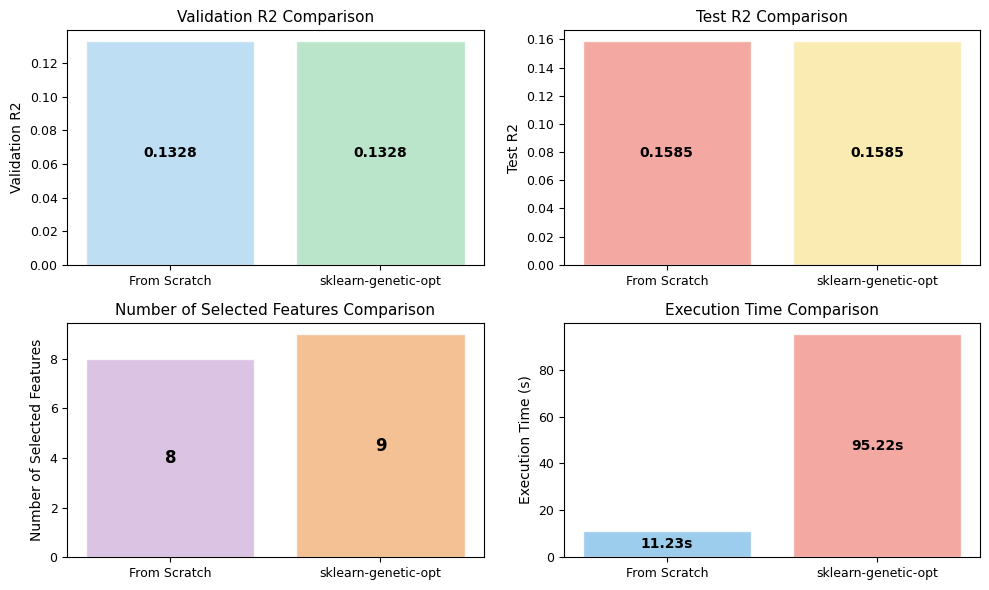

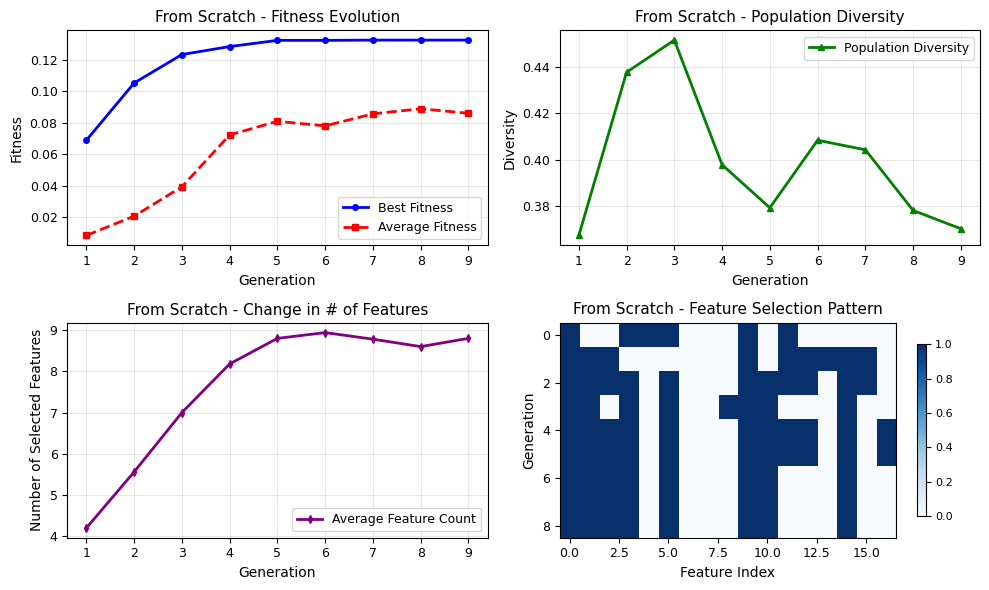


🔍 상세 분석:
------------------------------------------------------------
성능 차이 분석:
- Validation R2 차이: +0.0000 (From Scratch - sklearn-genetic-opt)
- Test R2 차이: +0.0000
- 실행 시간 차이: -83.98초

특징 선택 분석:
- 공통 선택 특징: ['area', 'lot_cd', 'x3', 'stack_type', 'hbm_type', 'timekey_hr', 'x4', 'x8']
- From Scratch만 선택: []
- sklearn-genetic-opt만 선택: ['x5']


In [47]:
# 비교 실행
comparison_results = run_comparison(
        X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test,
        final_feature_names
    )

# 결과 시각화
visualize_comparison(comparison_results, final_feature_names)